# 待解決問題
1. 某個record會預測出對應sample_time的target data，但這個target data並不是因為單一record所導致的，而是因為一段record造成的

# 描述性統計
## 變異性
1. 總體變異程度
2. sample slot內的變異程度

In [83]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [84]:
result = {}

for file in os.listdir("./processed_data"):
    if file.endswith(".csv"):
        df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")
        df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
        df['sample_time'] = pd.to_datetime(df['sample_time'])
        result[f'{file.replace(".csv", "")}'] = df

result_keys = list(result.keys())

sample_times = result[result_keys[0]]['sample_time'].unique()

C:\Users\蔡世玄\AppData\Local\Temp\ipykernel_40636\733658463.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")


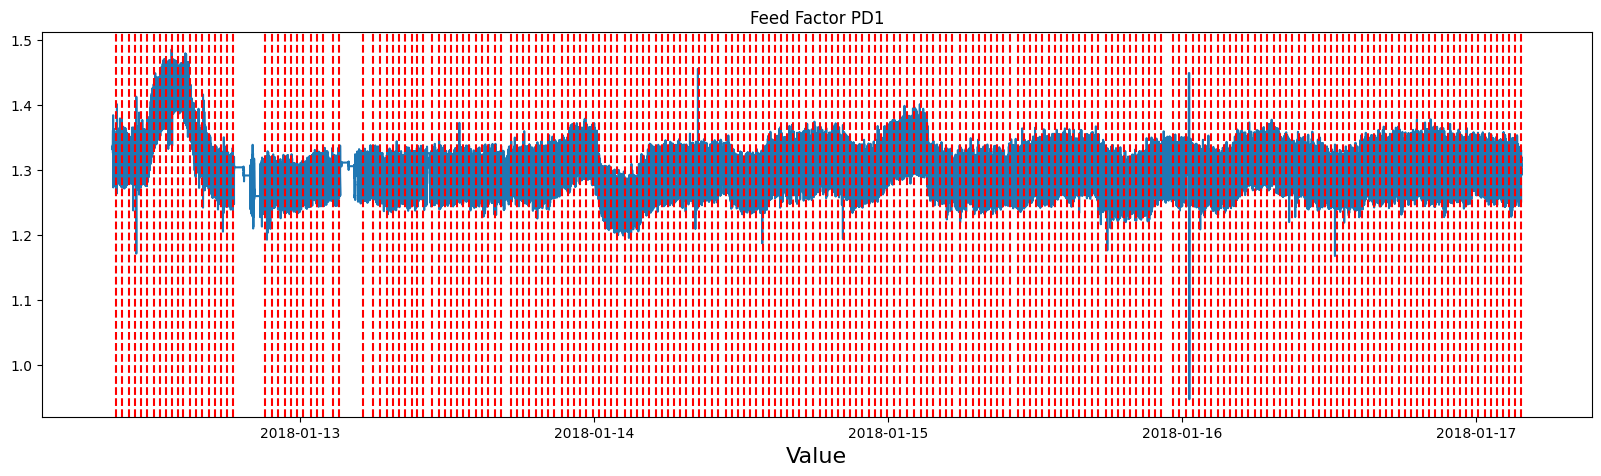

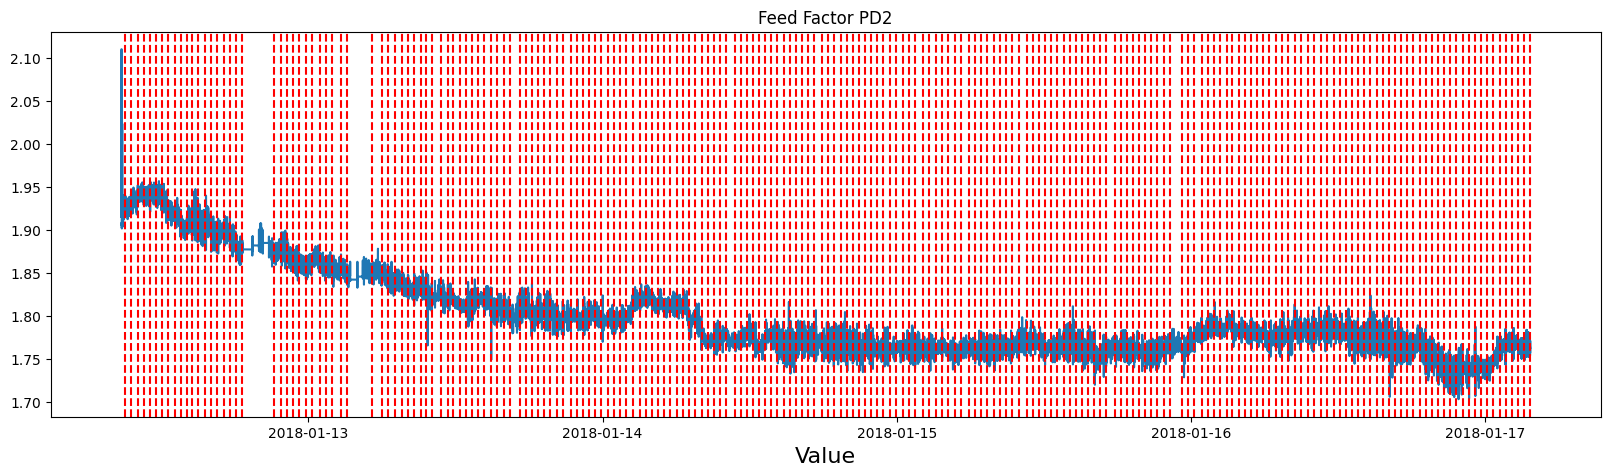

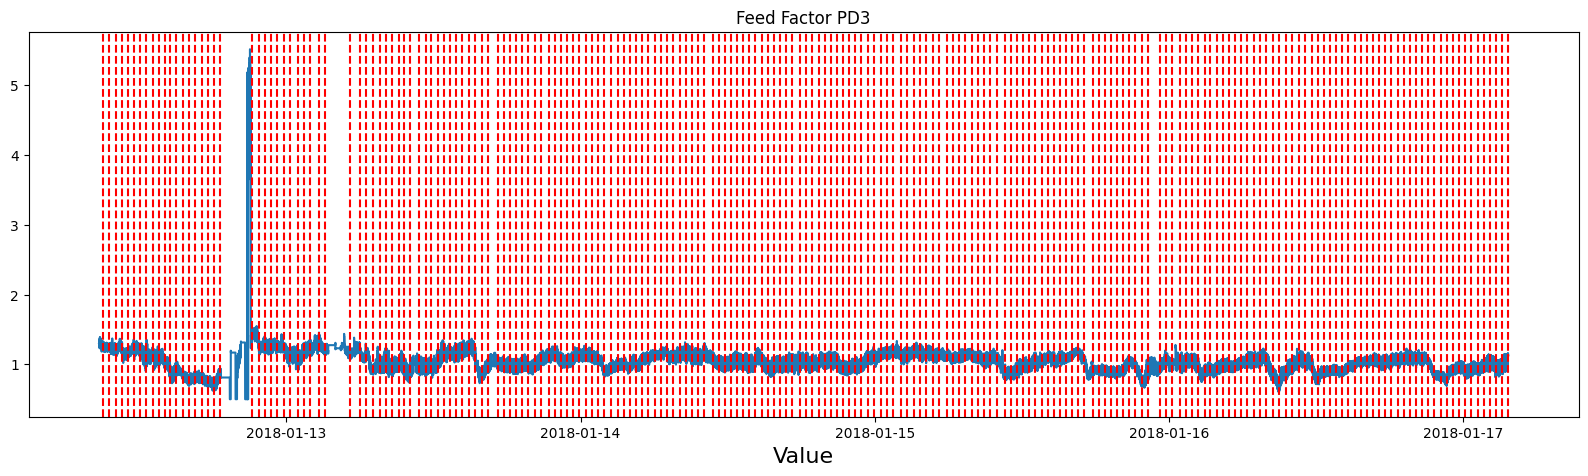

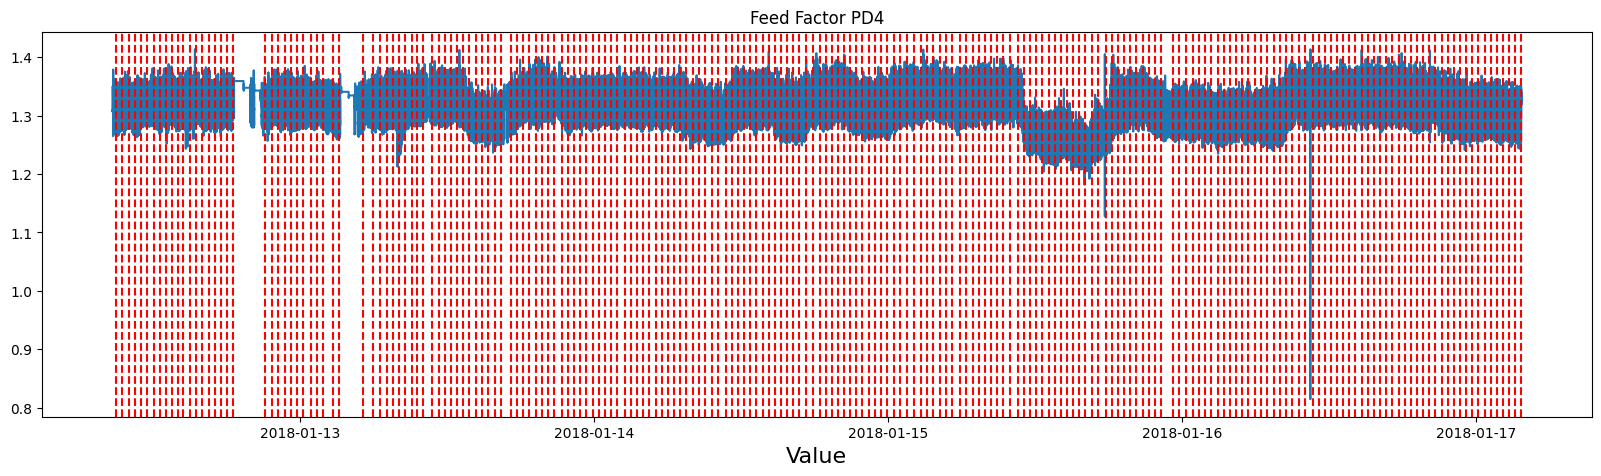

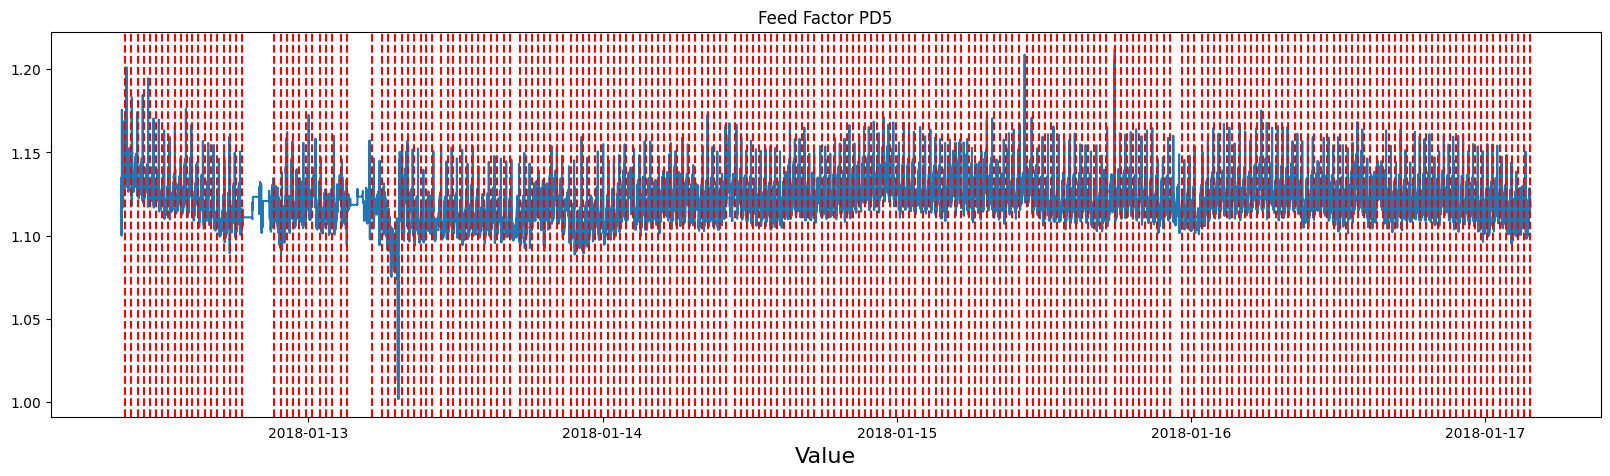

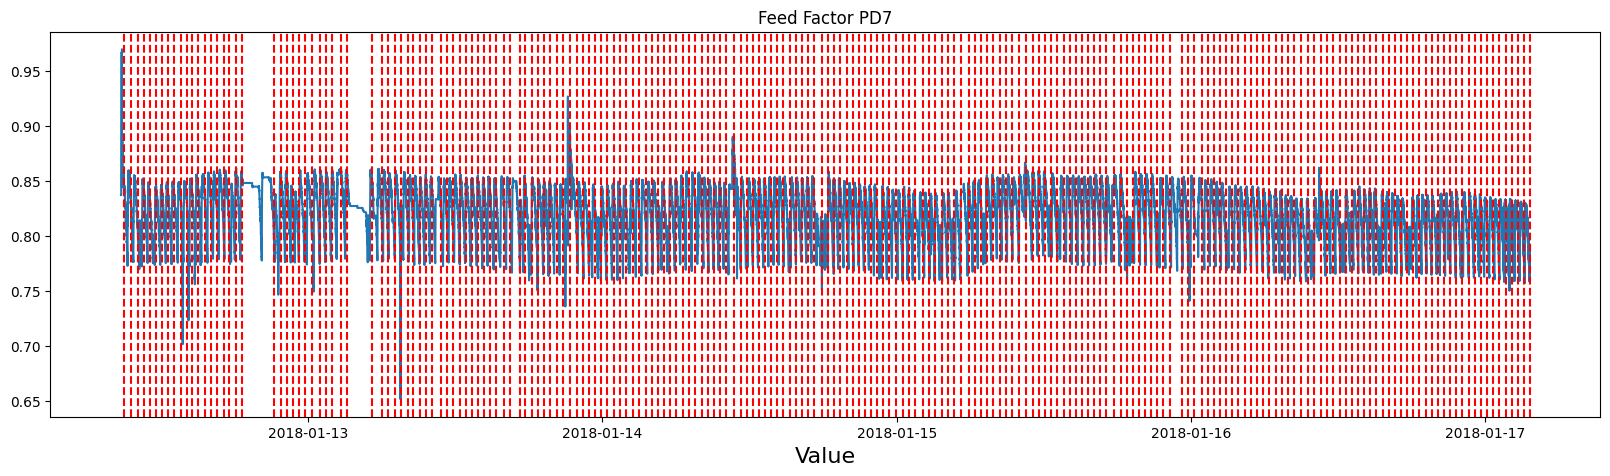

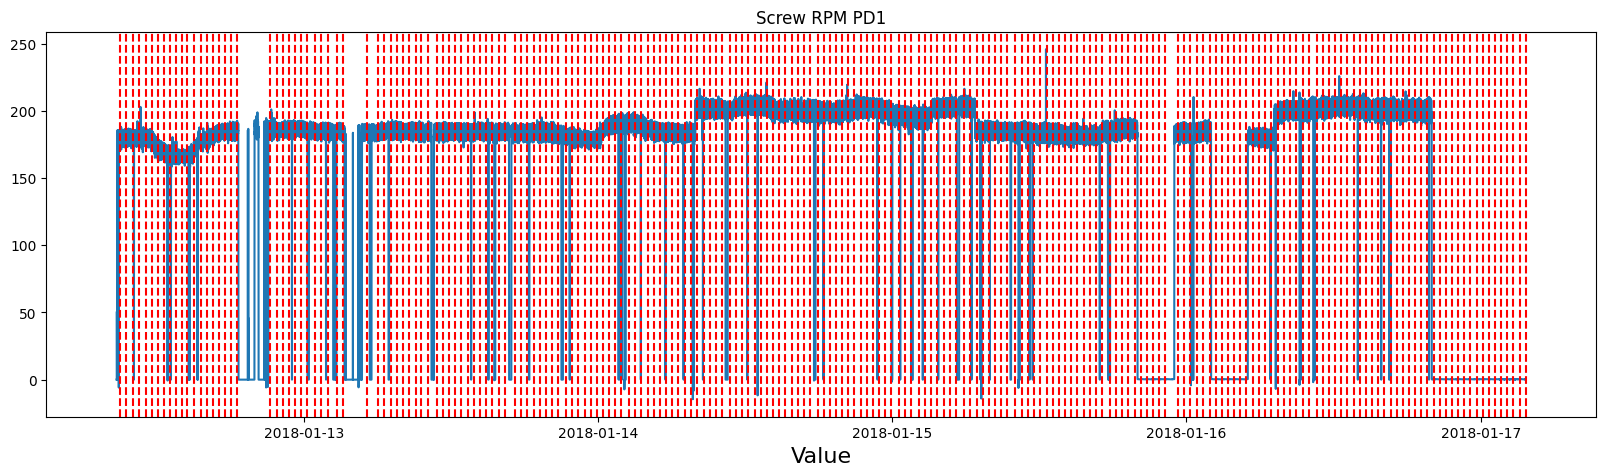

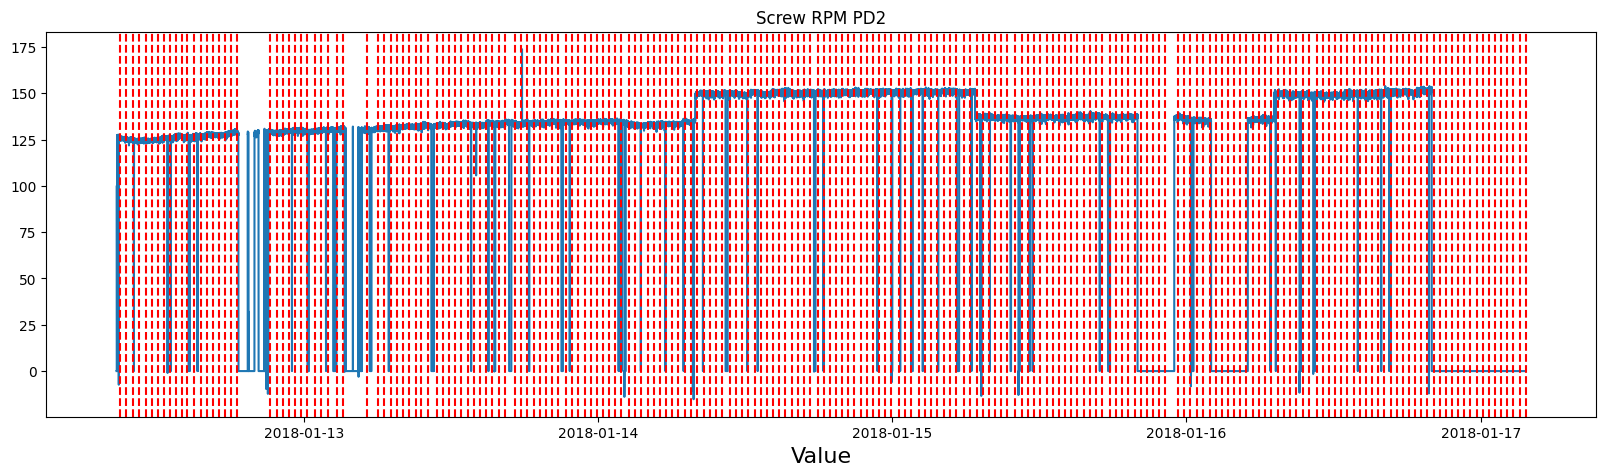

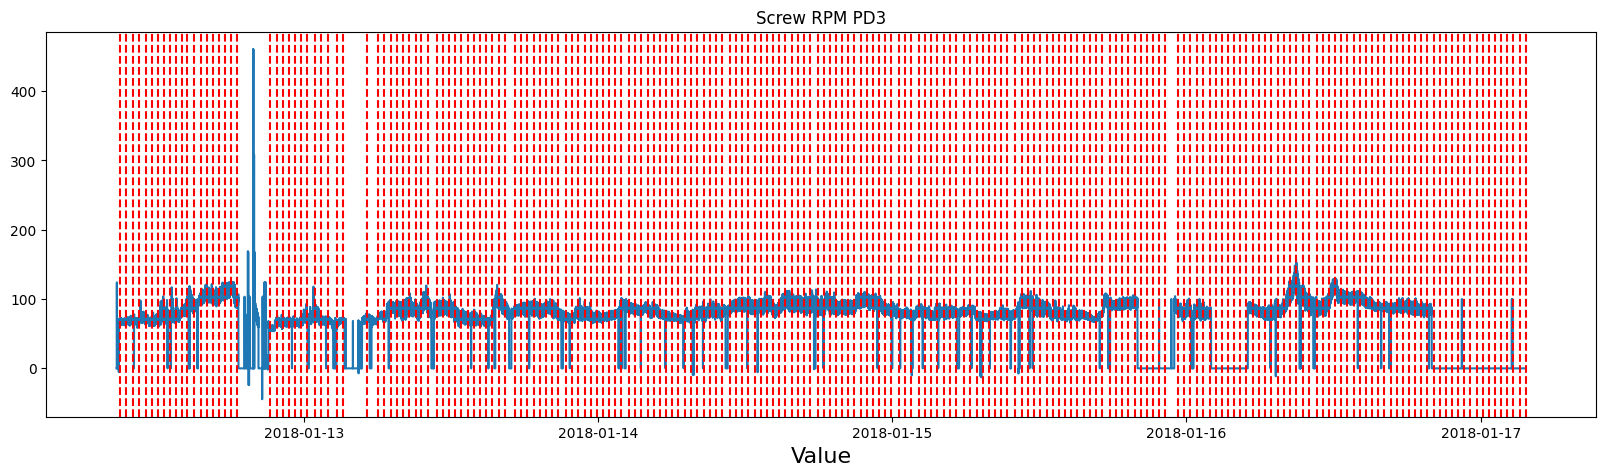

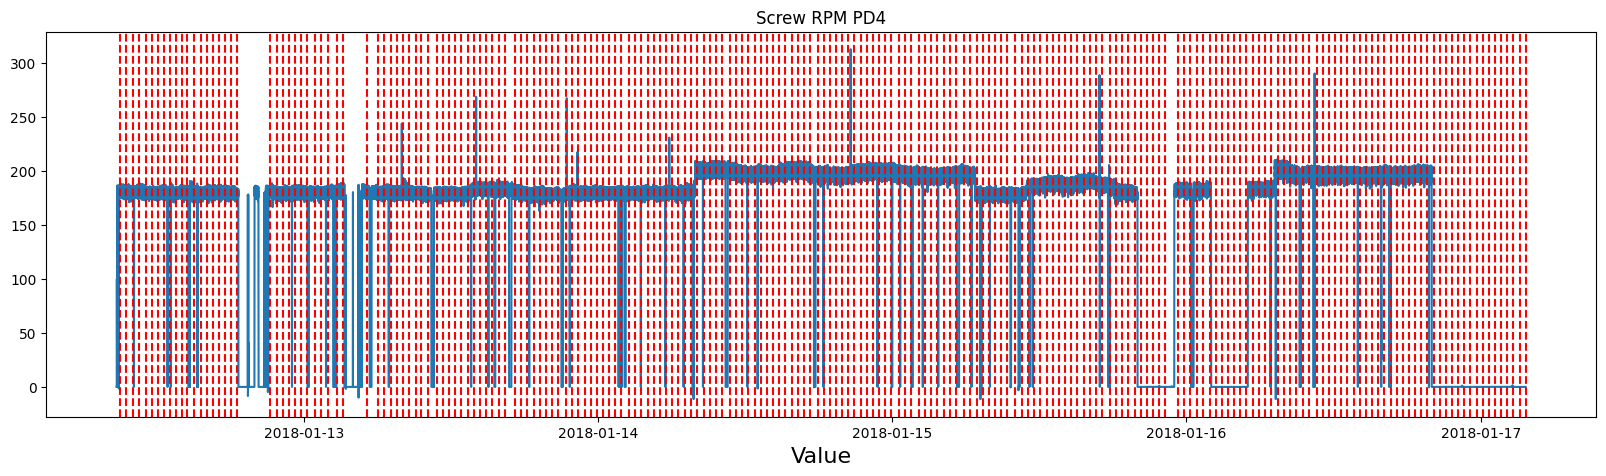

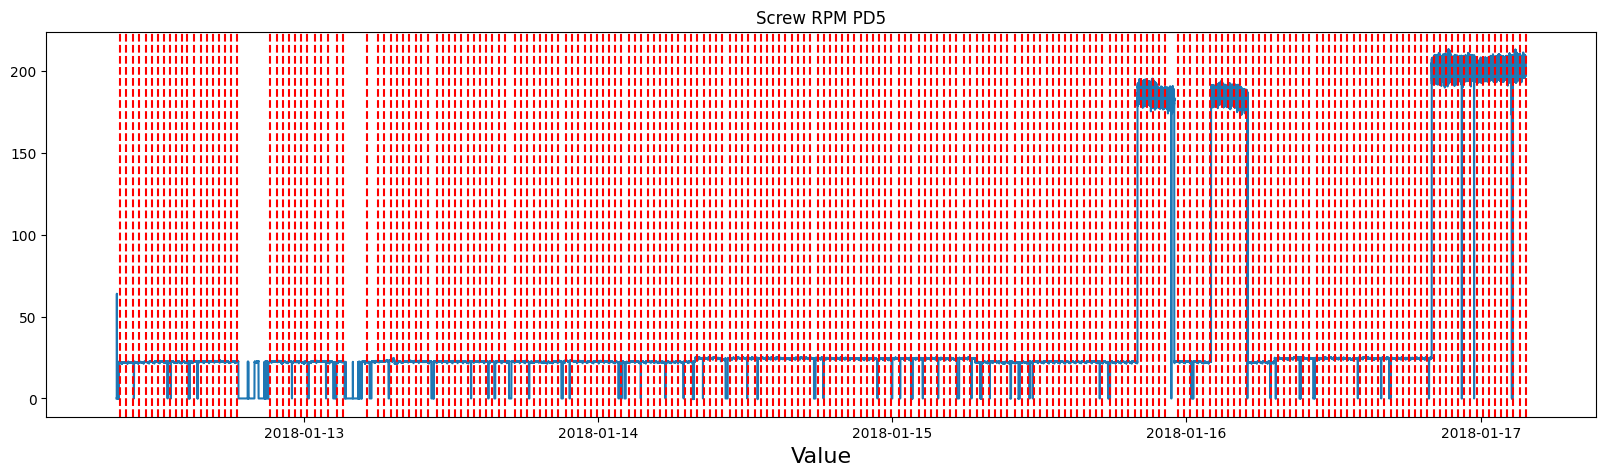

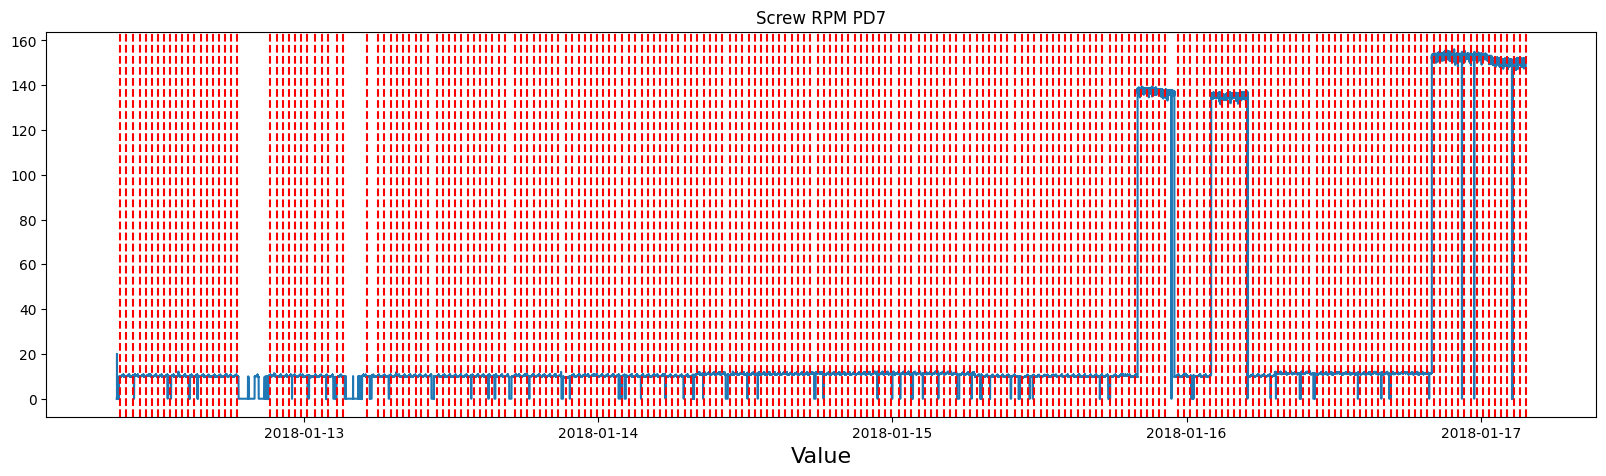

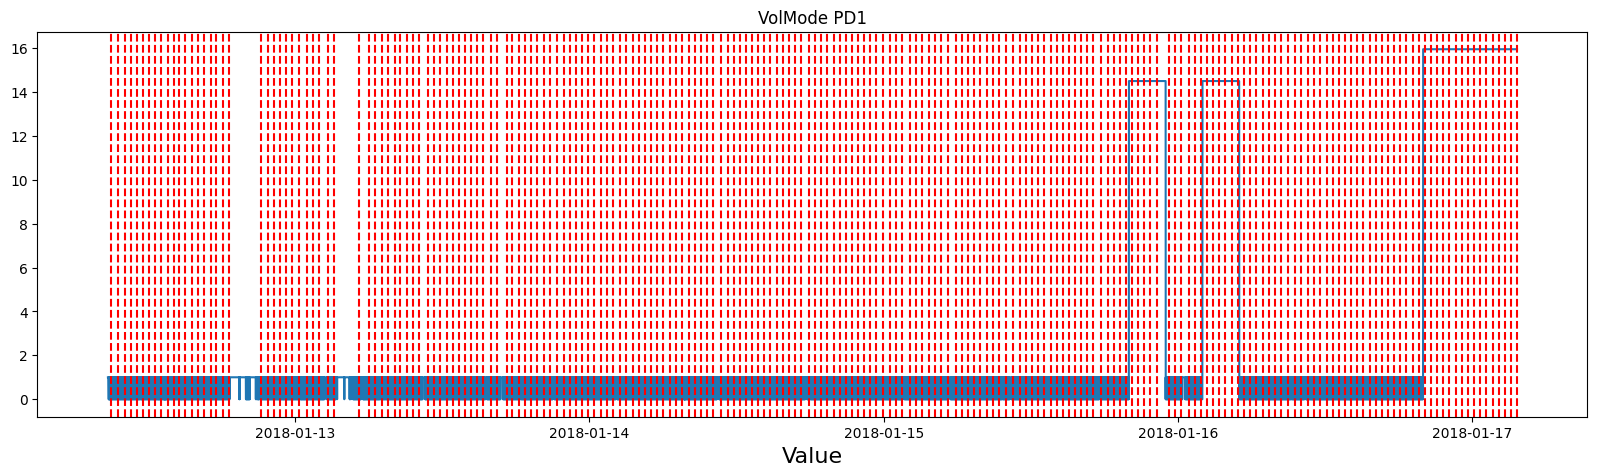

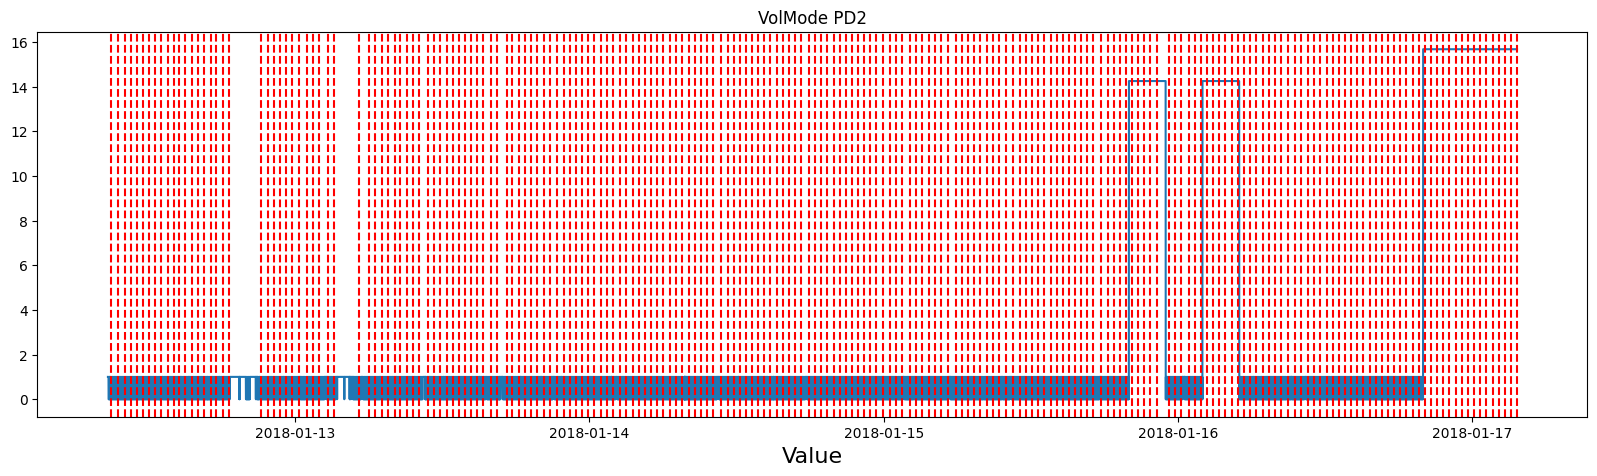

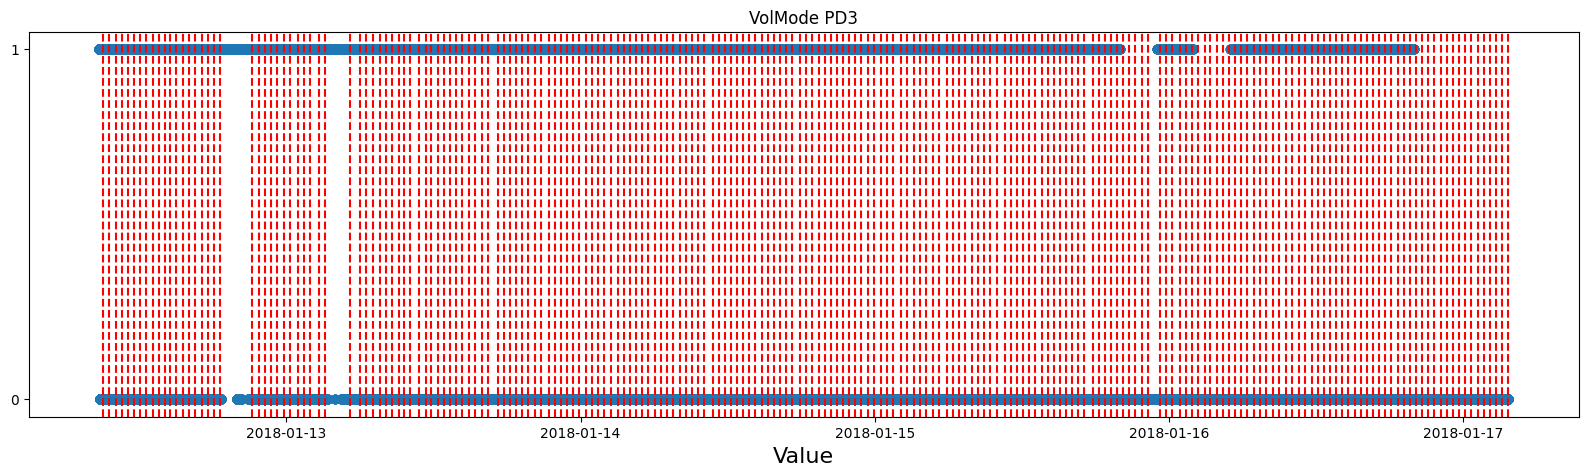

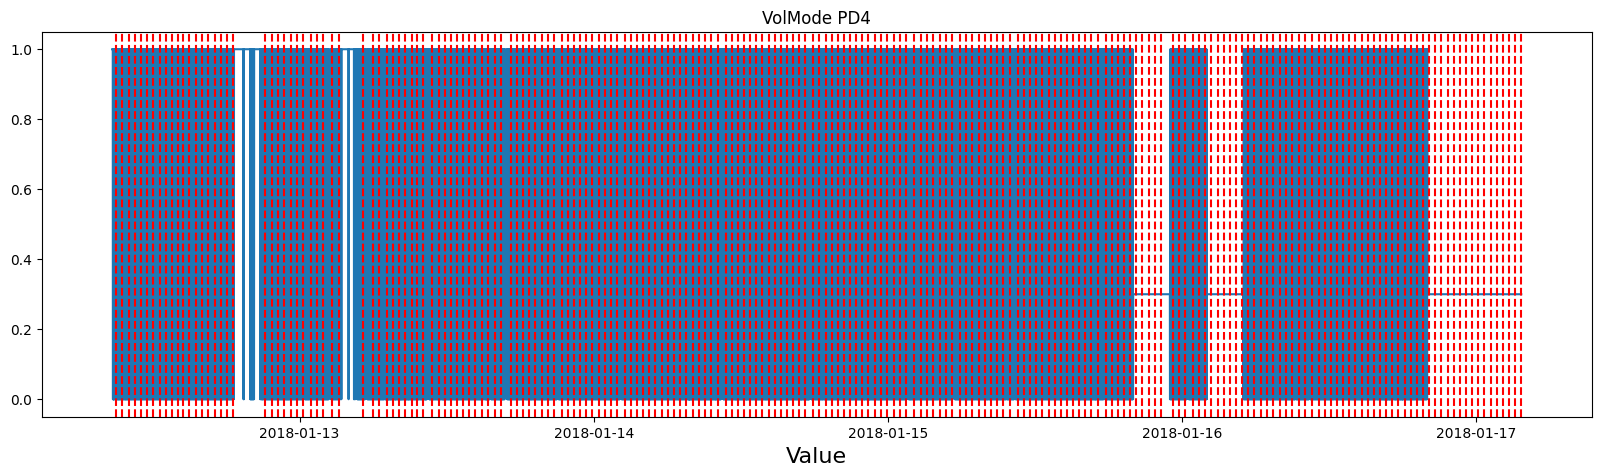

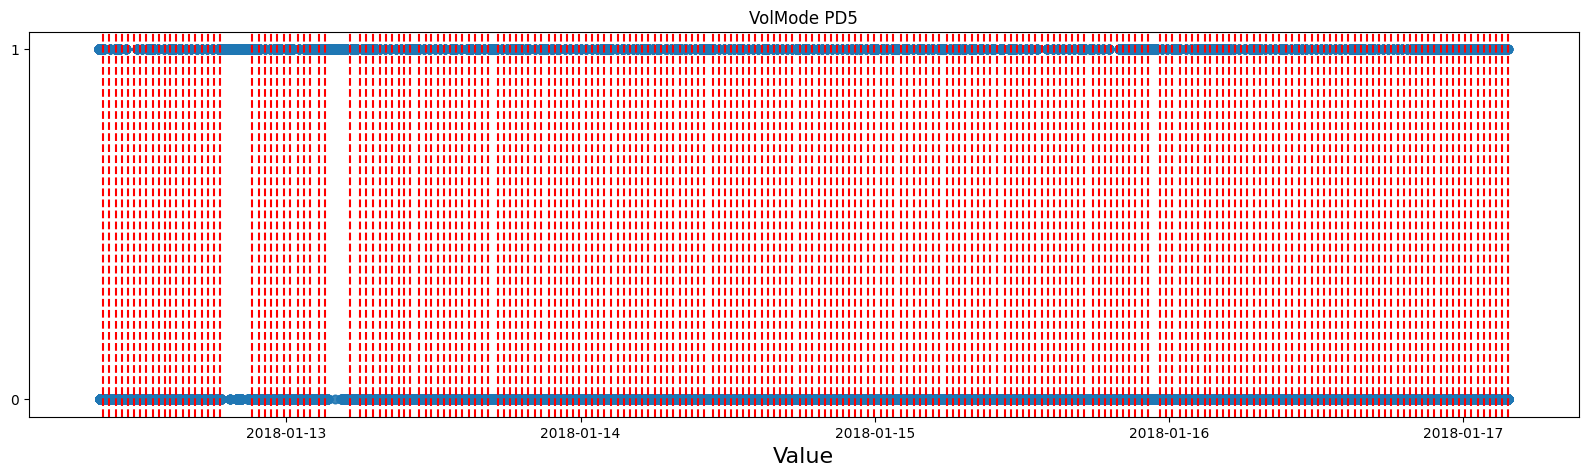

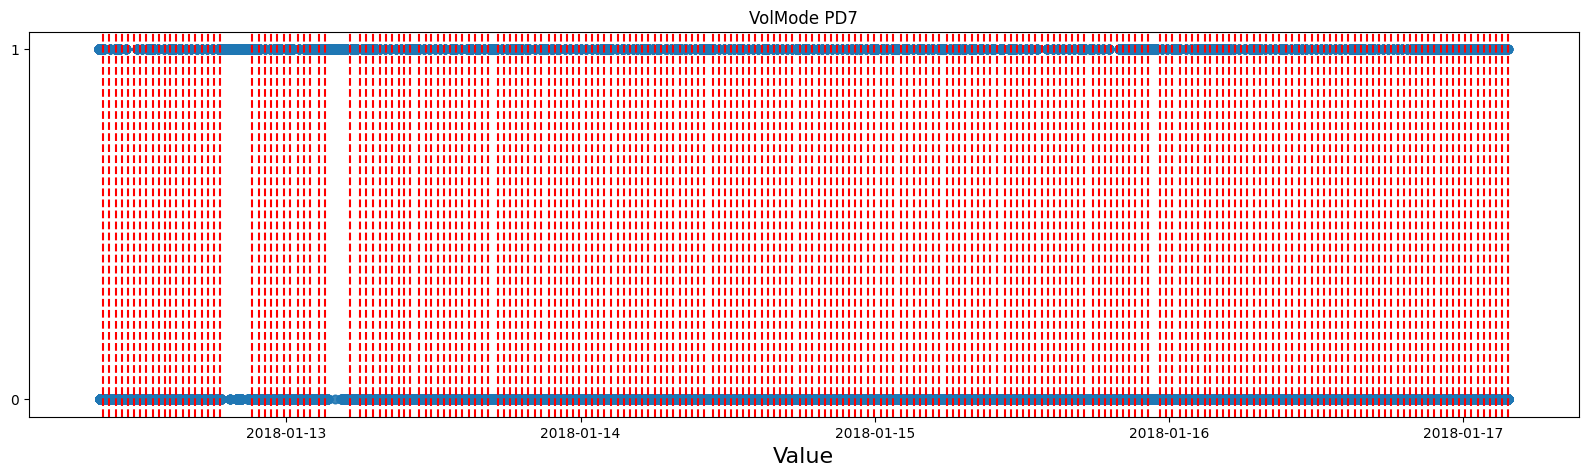

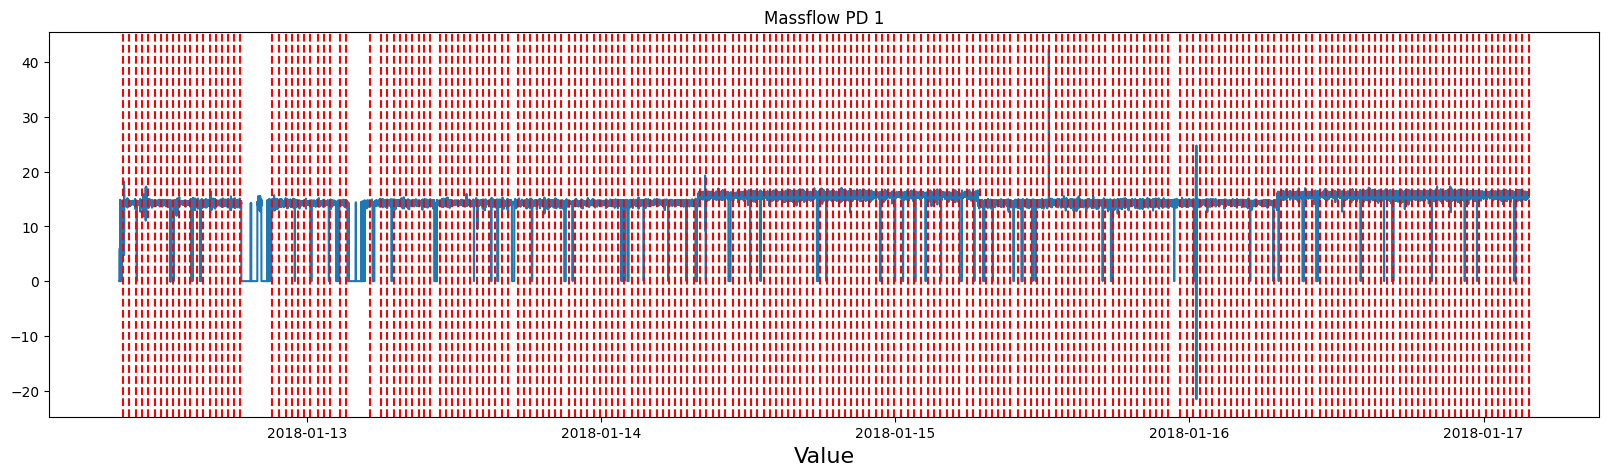

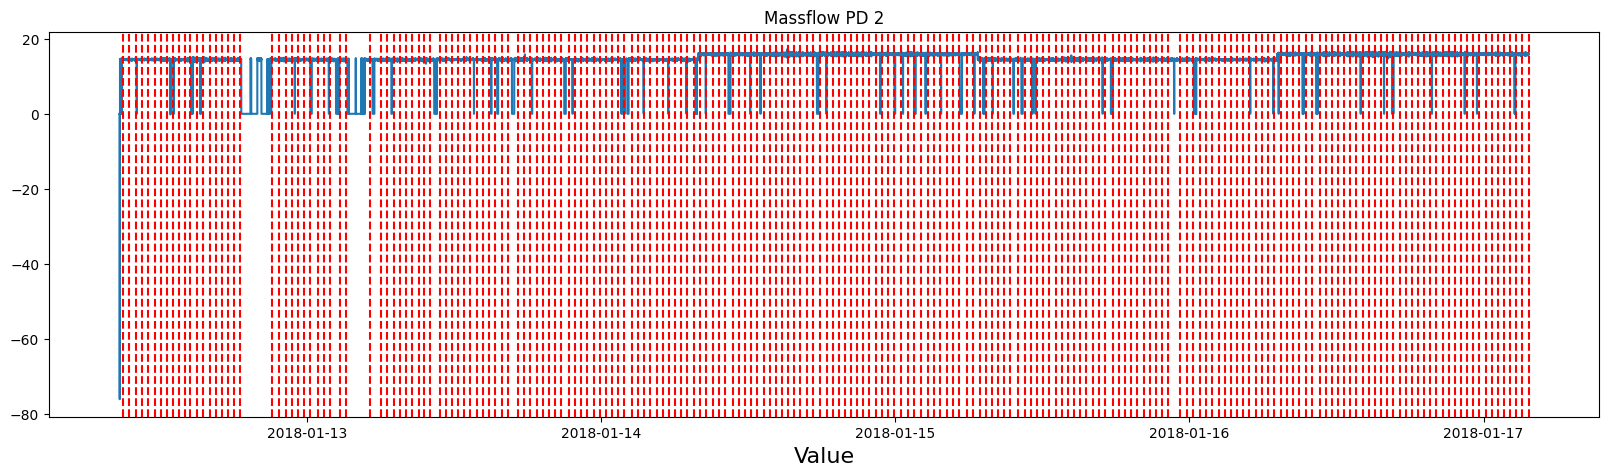

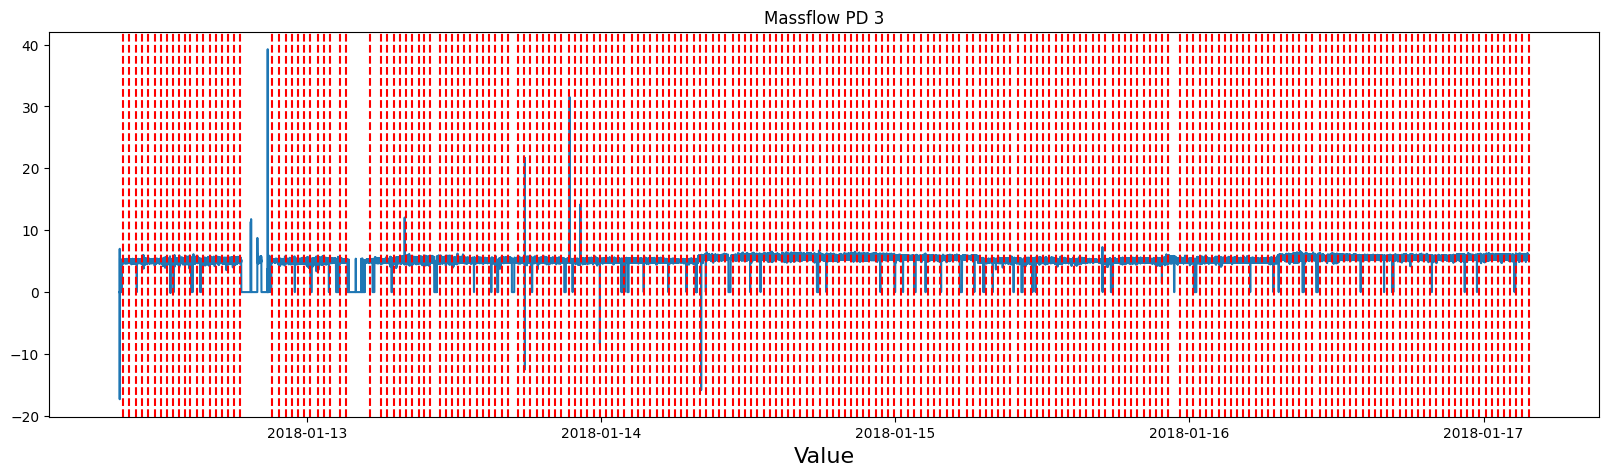

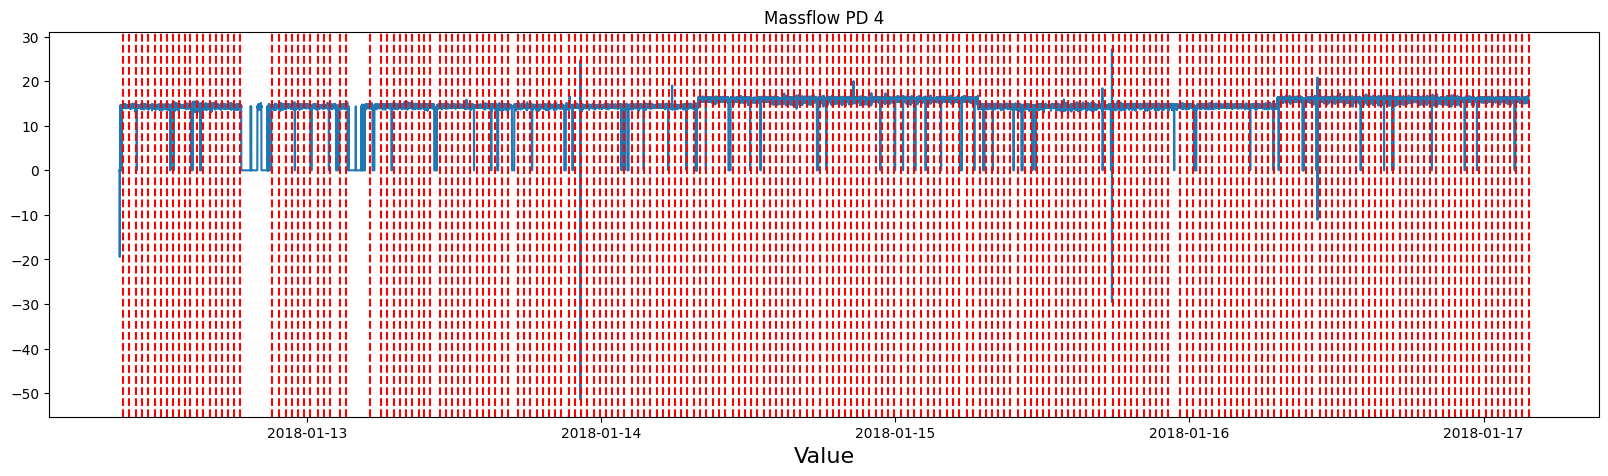

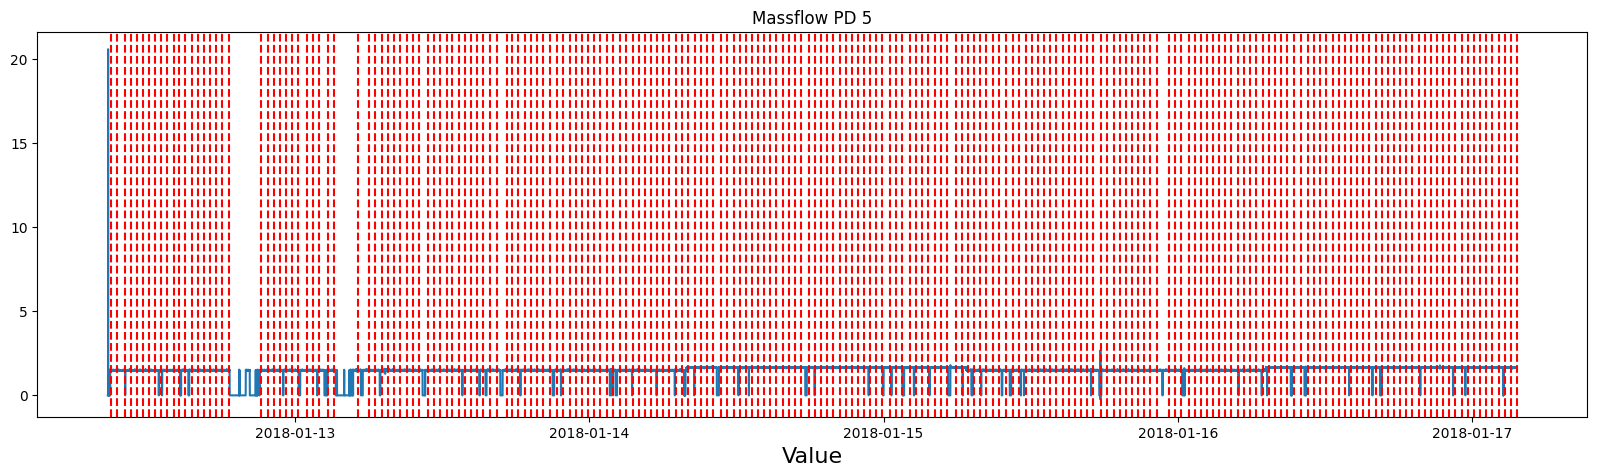

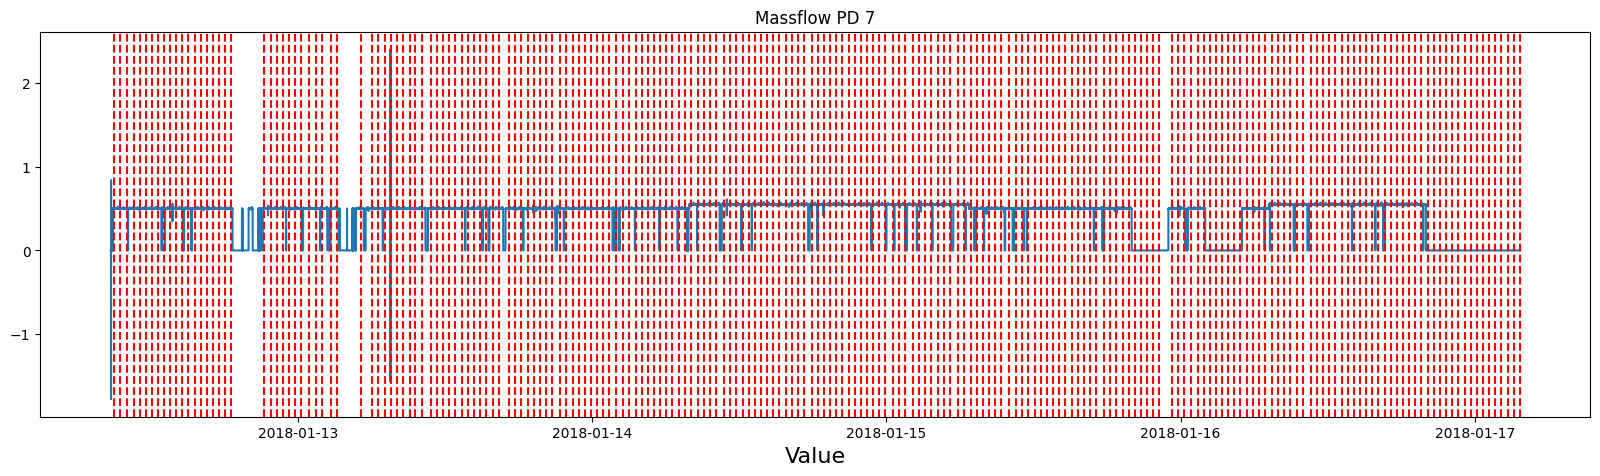

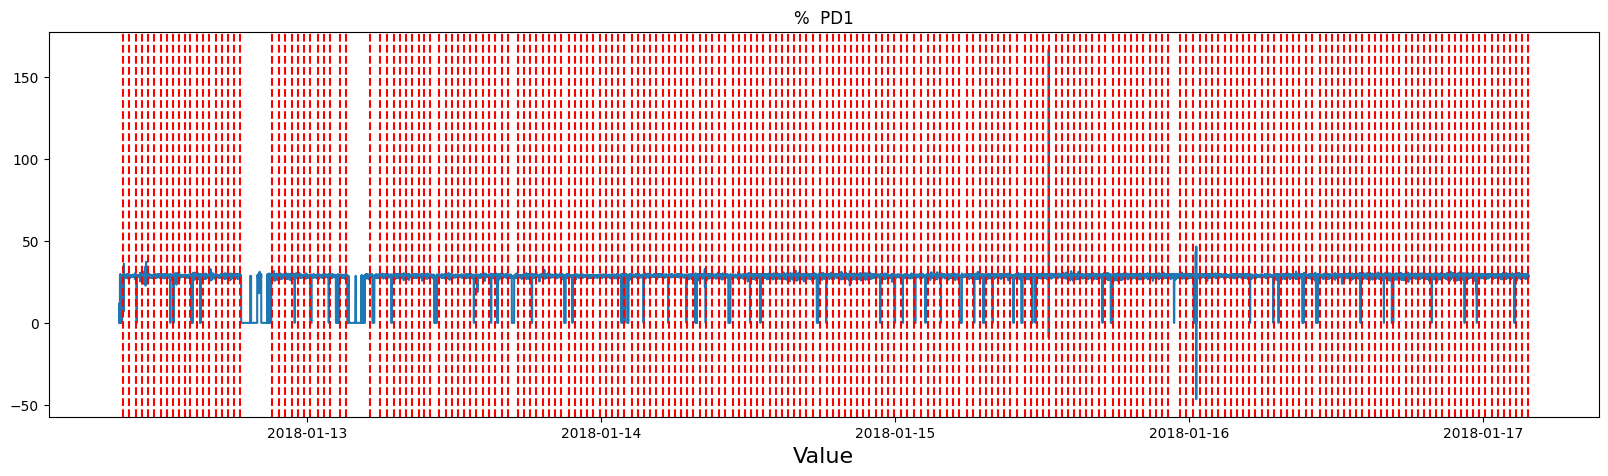

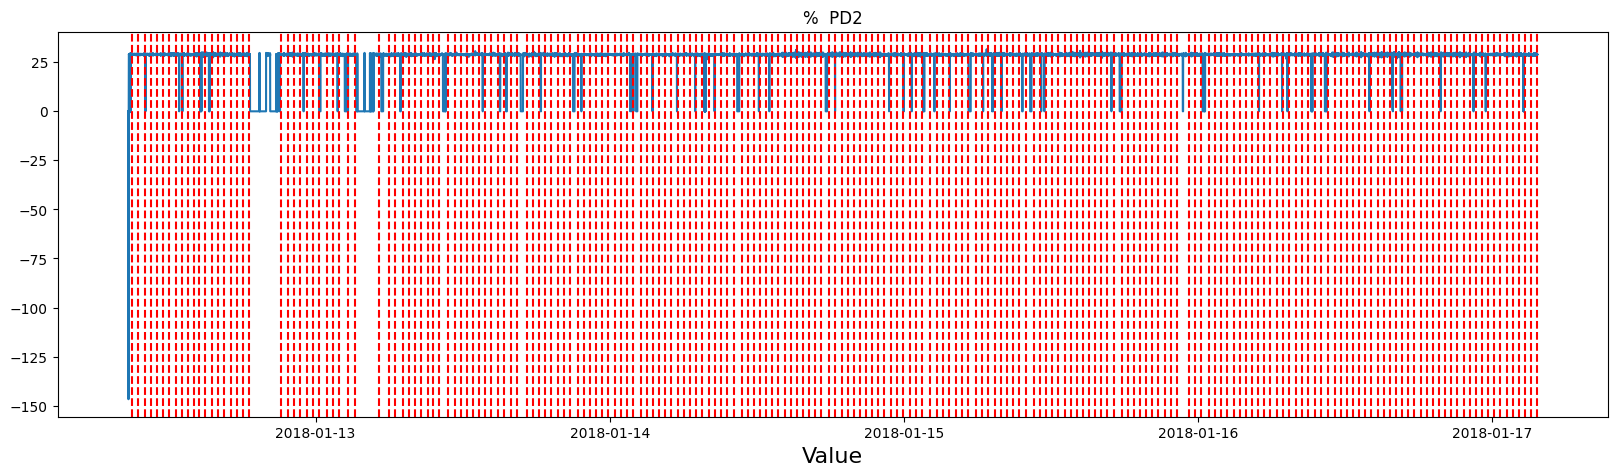

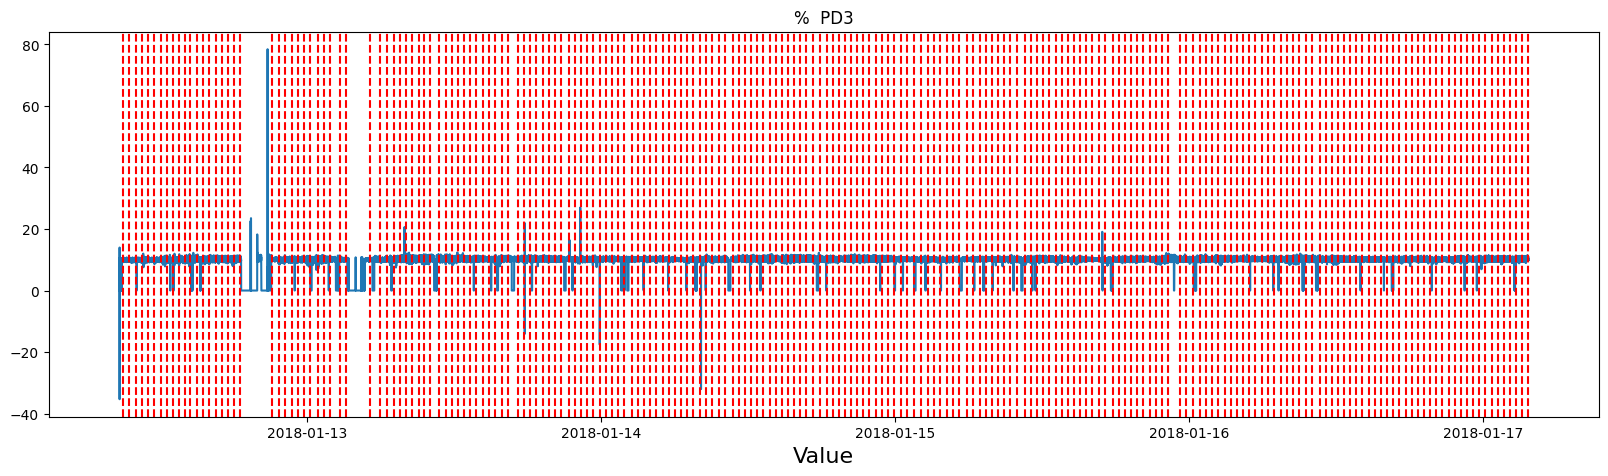

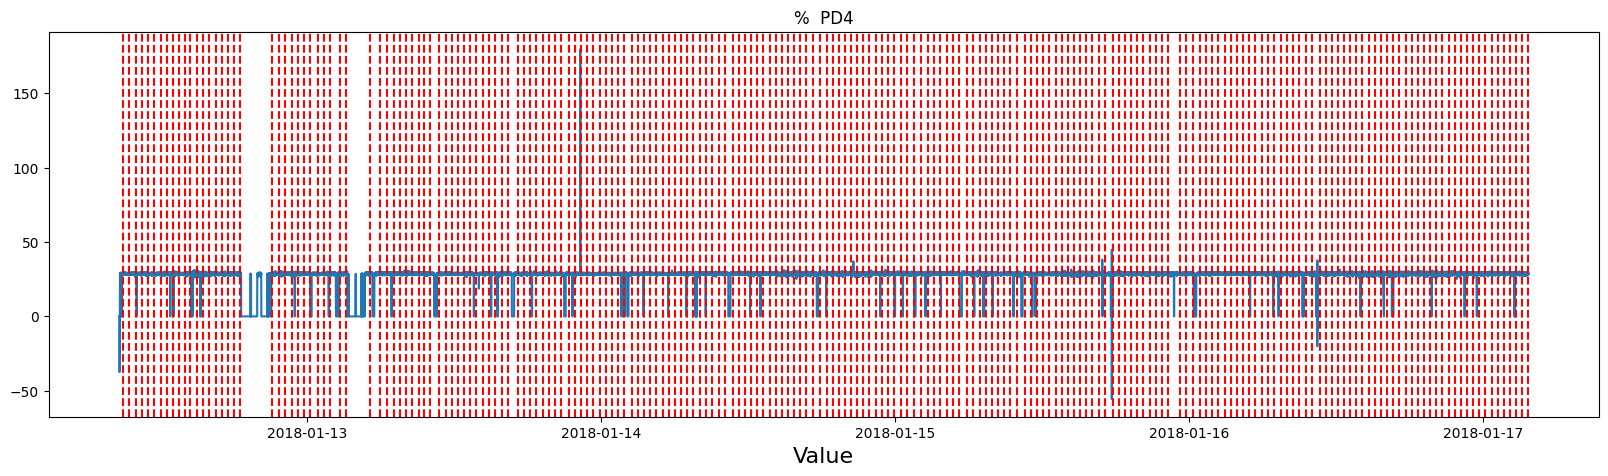

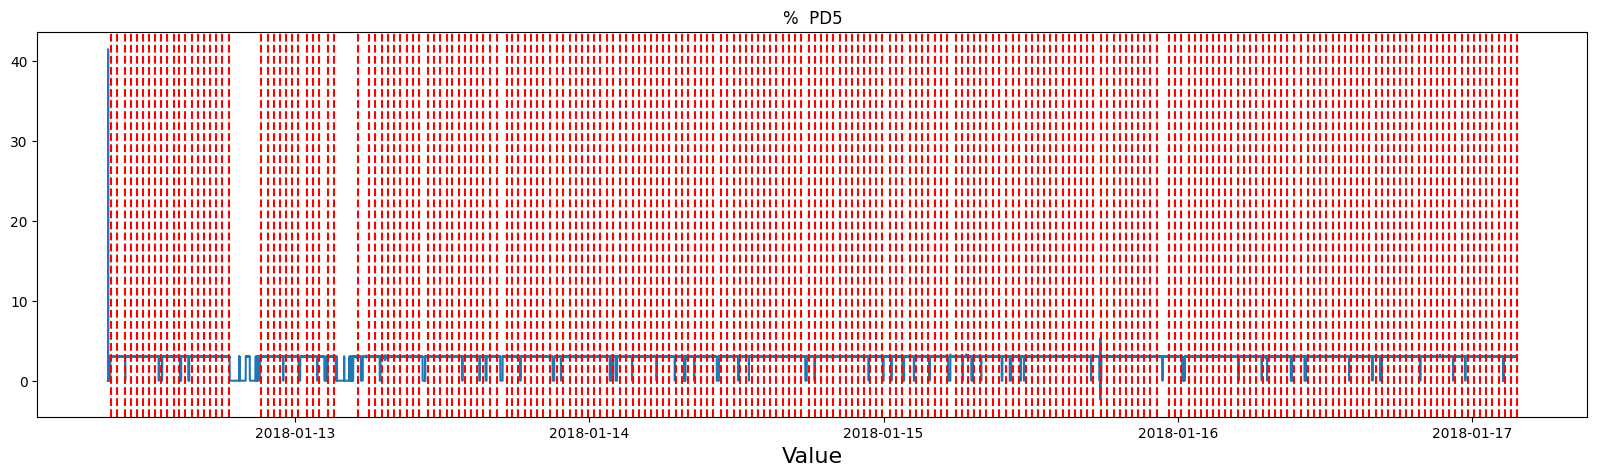

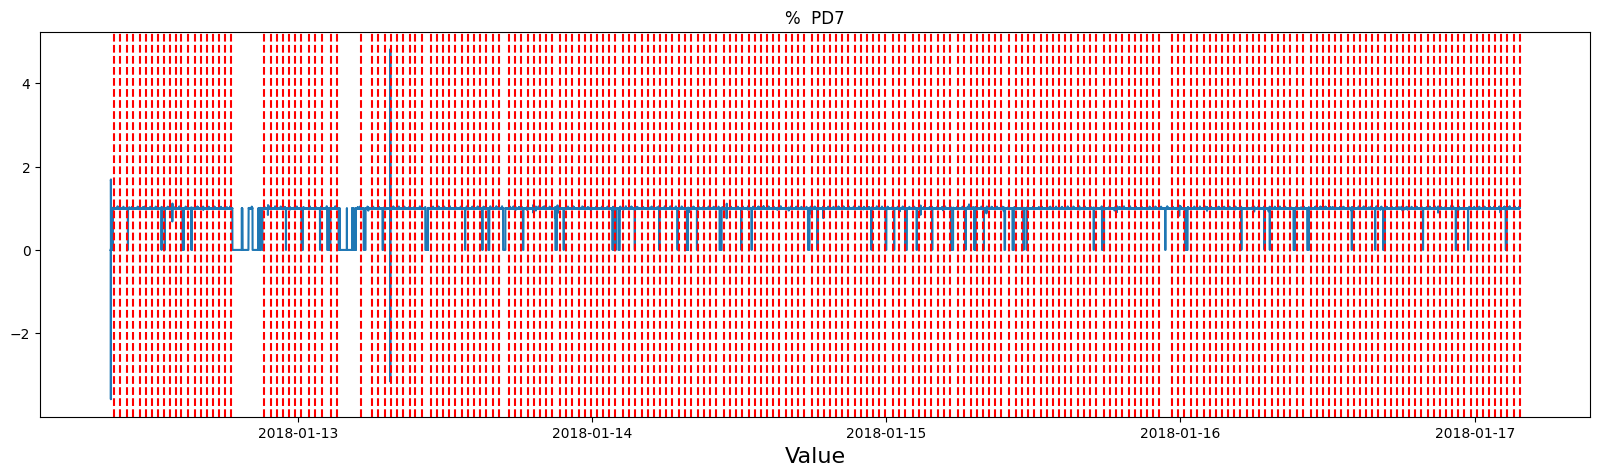

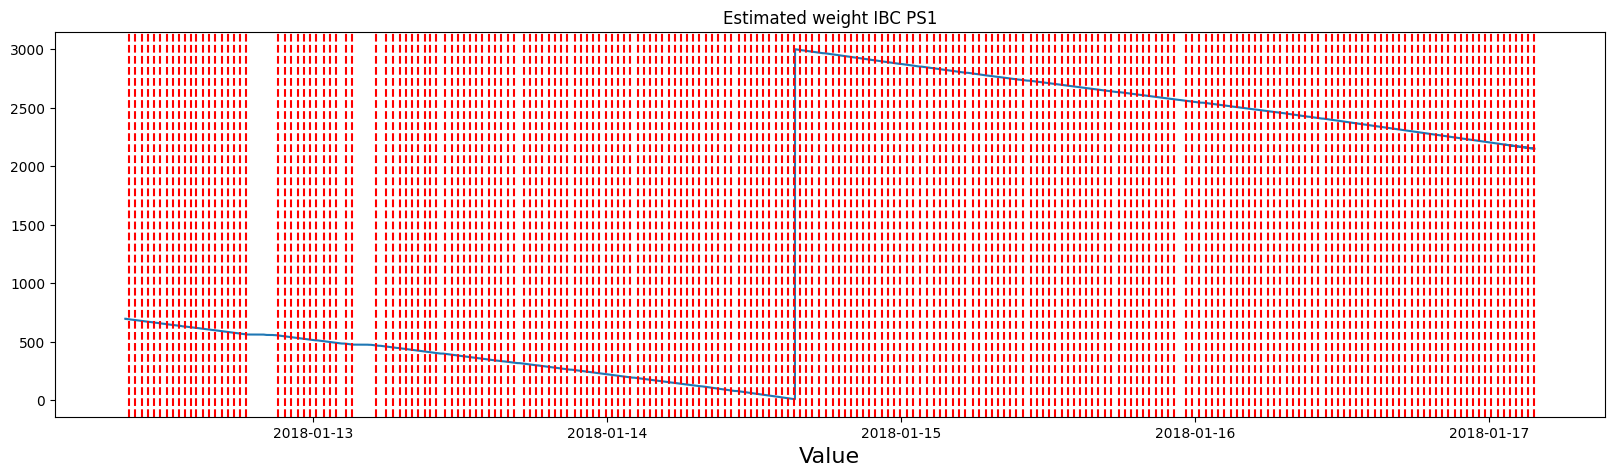

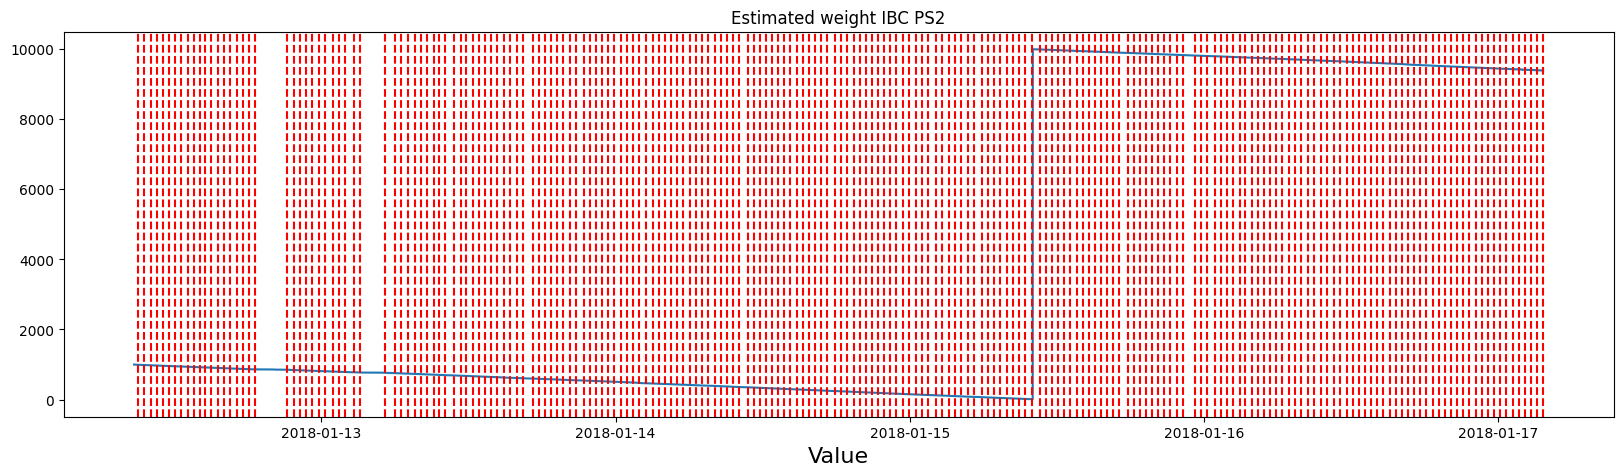

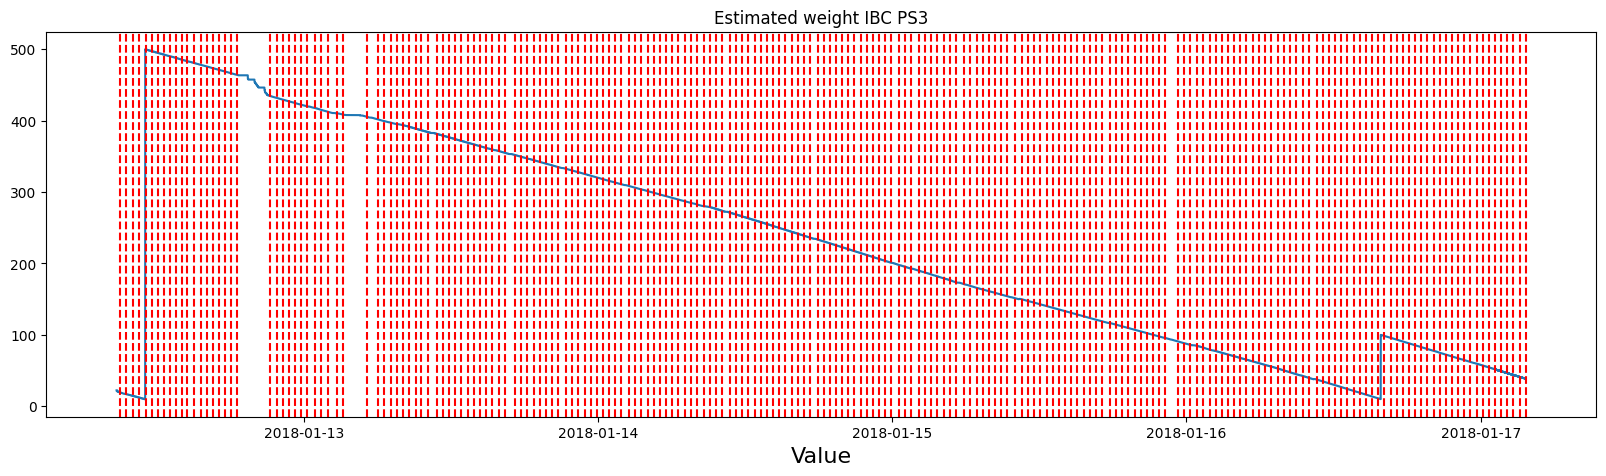

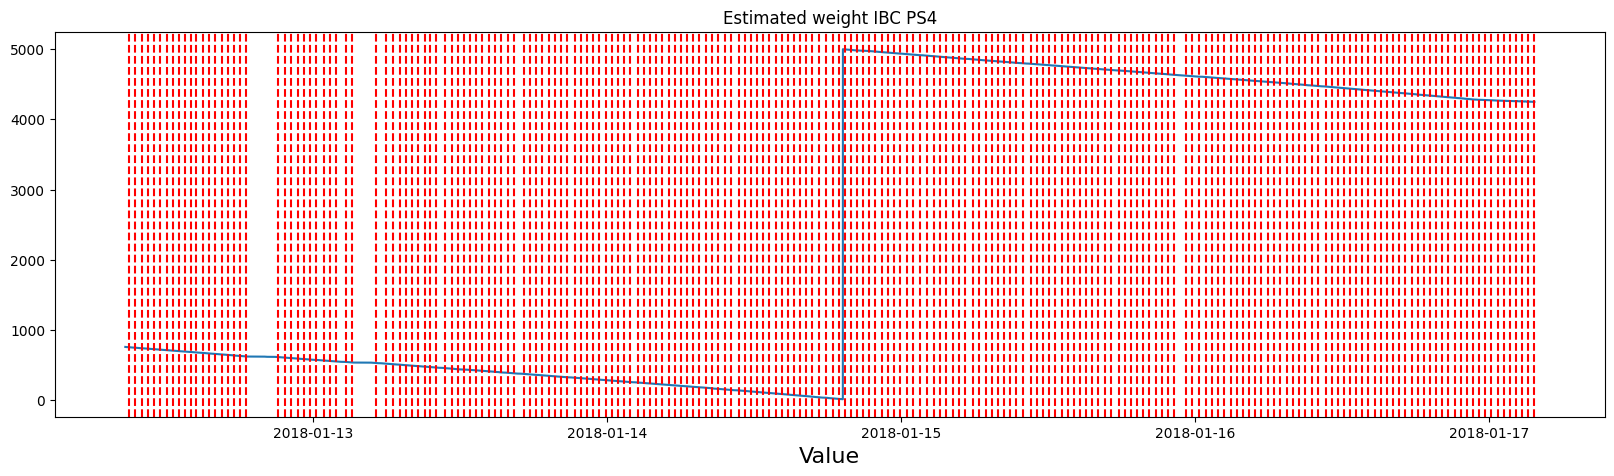

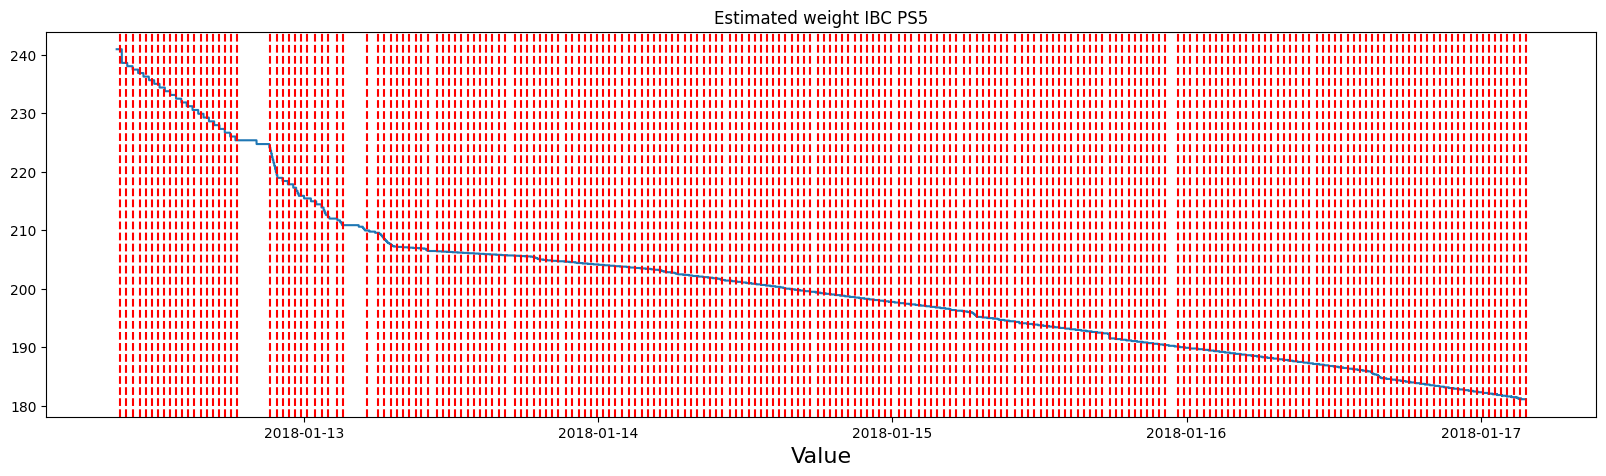

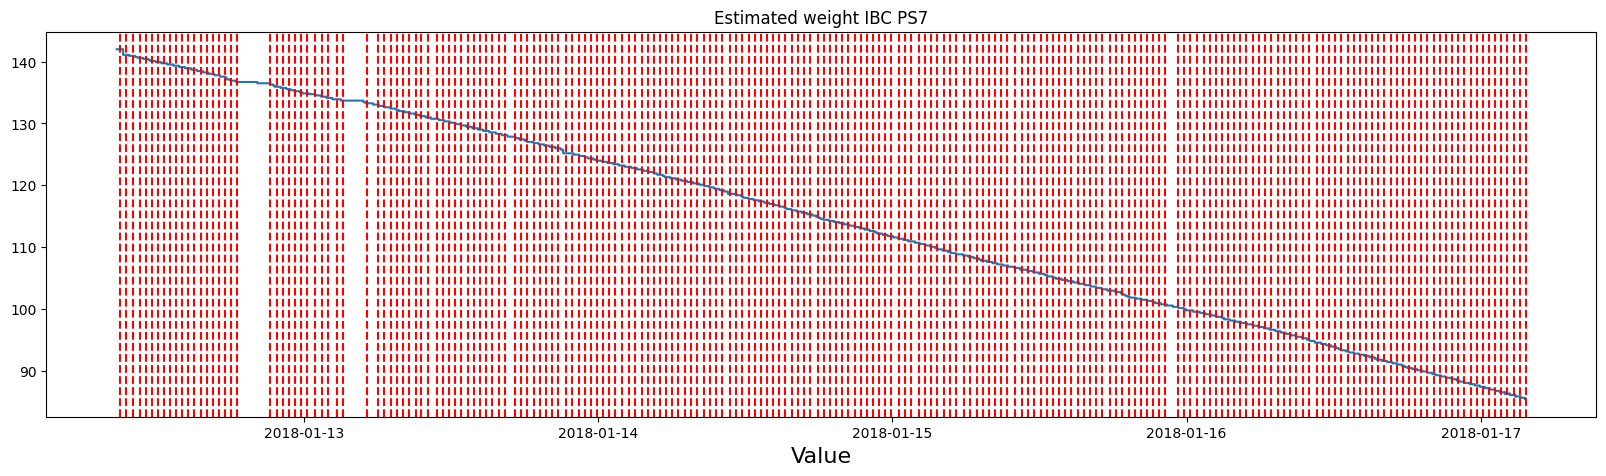

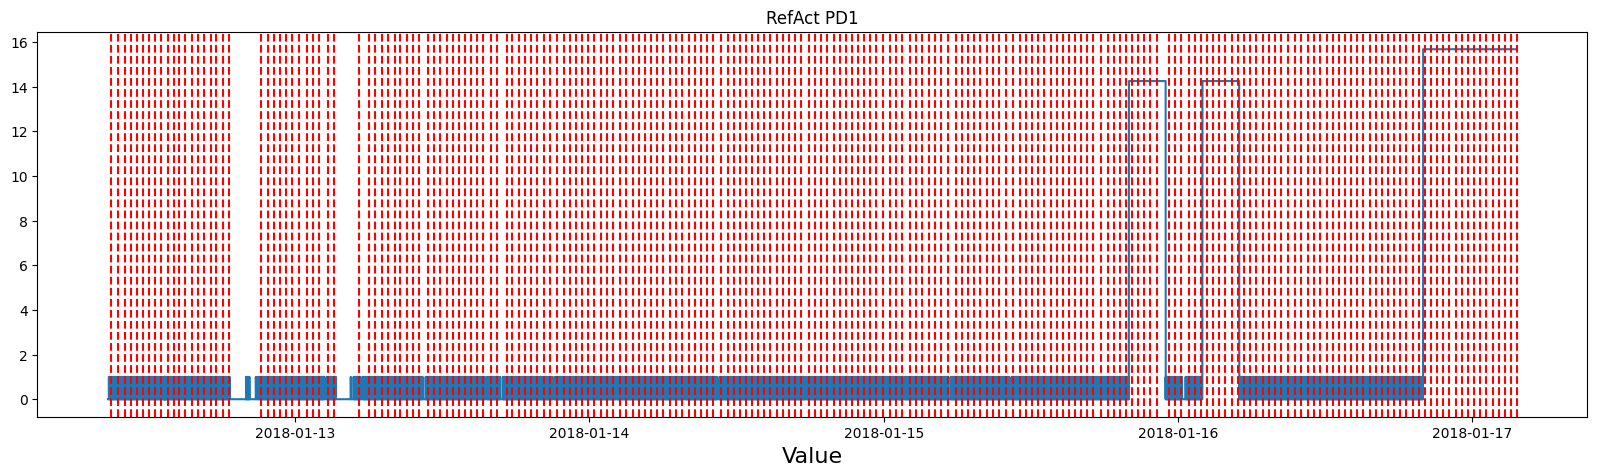

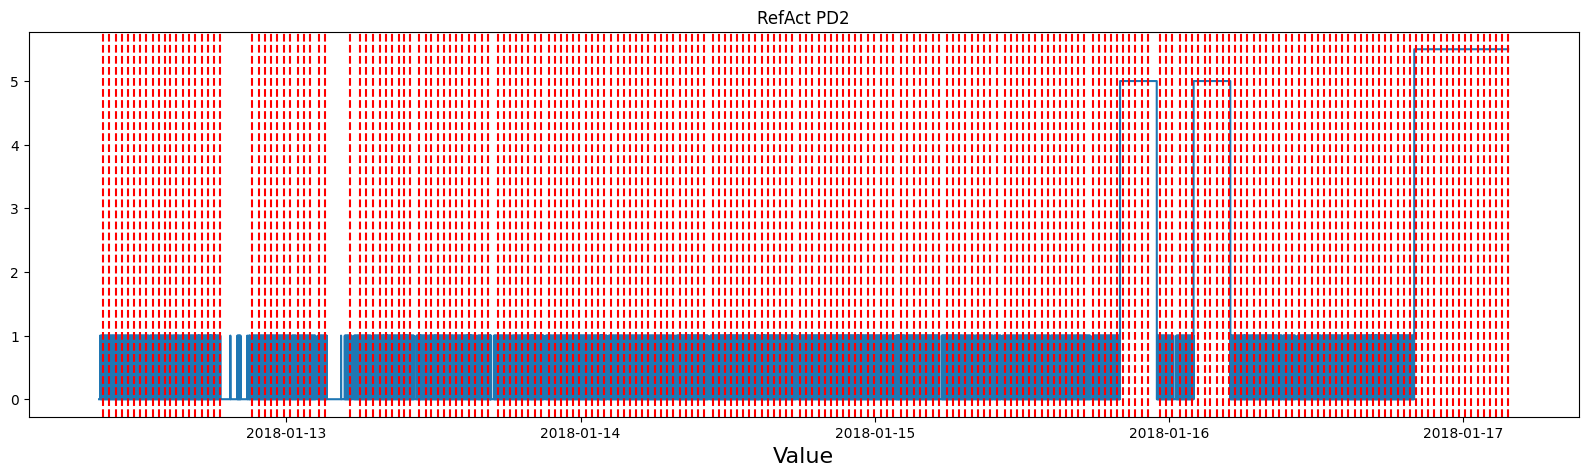

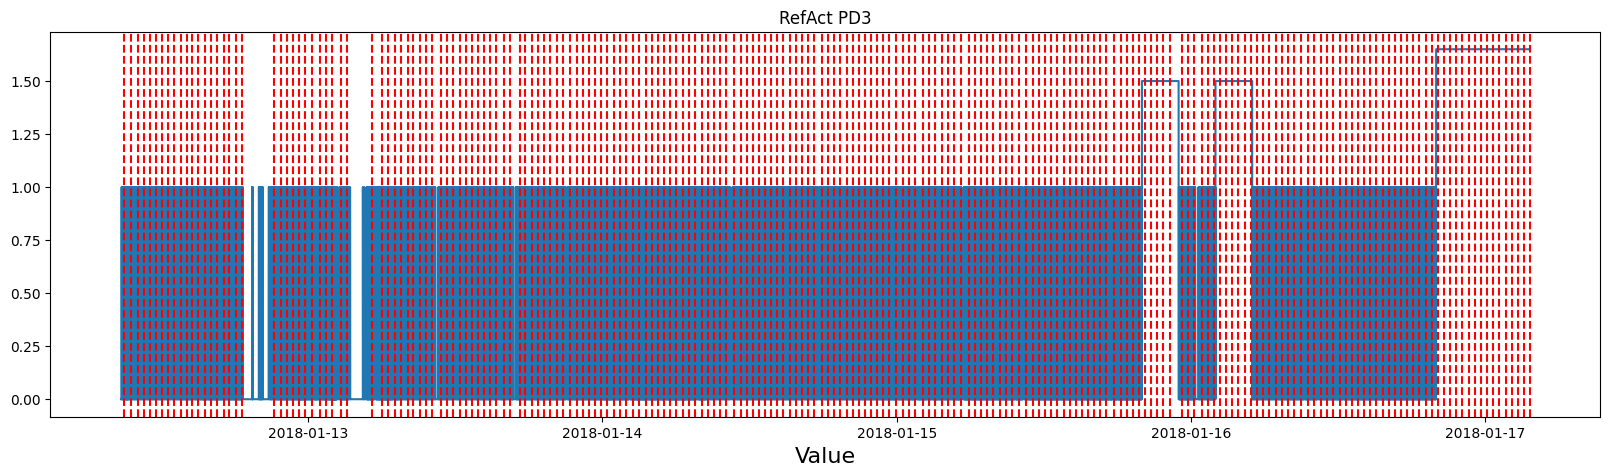

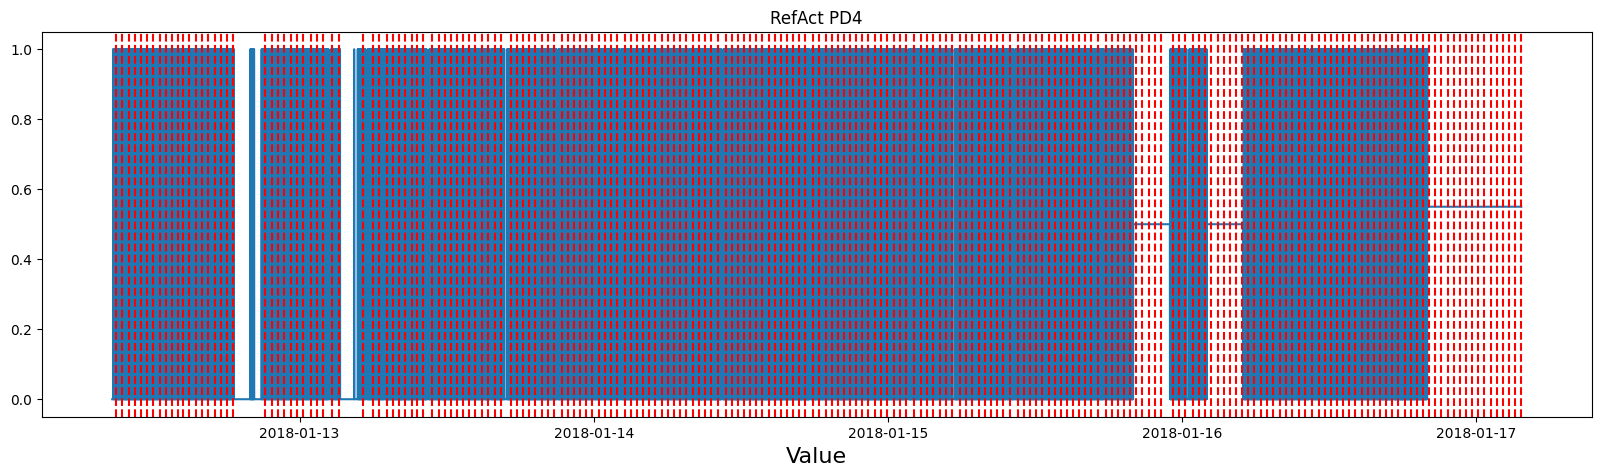

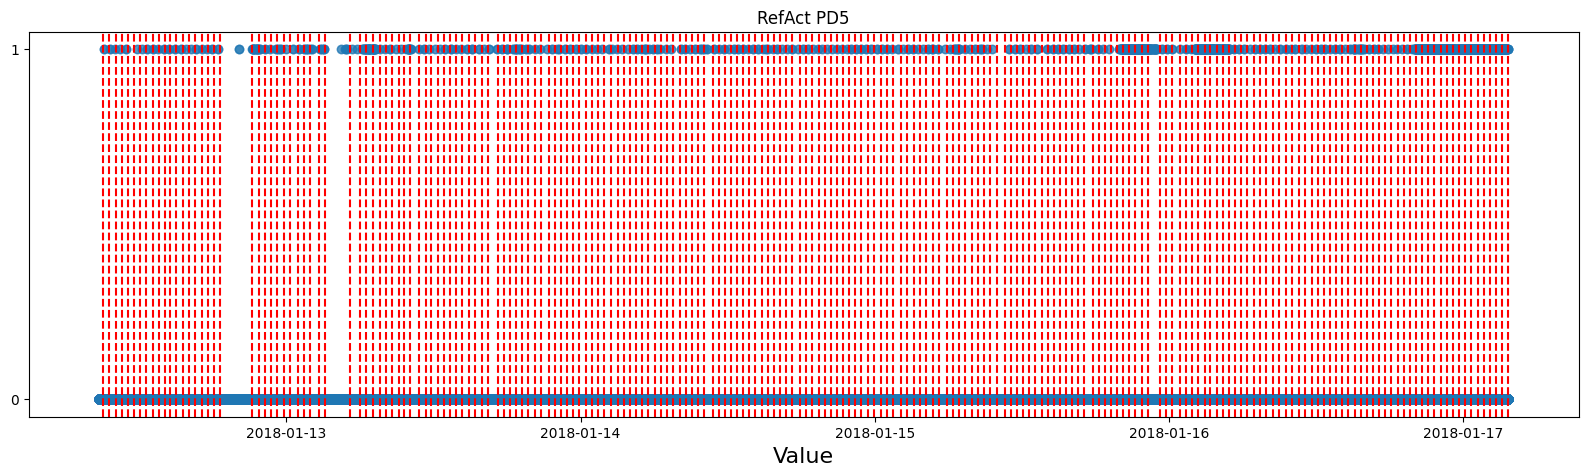

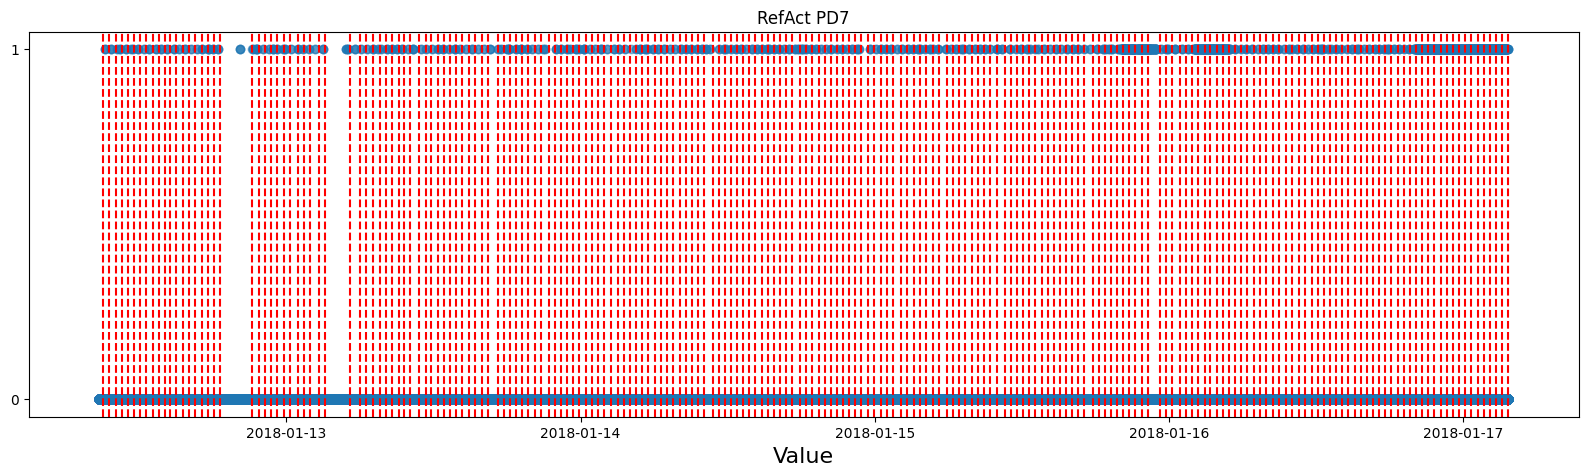

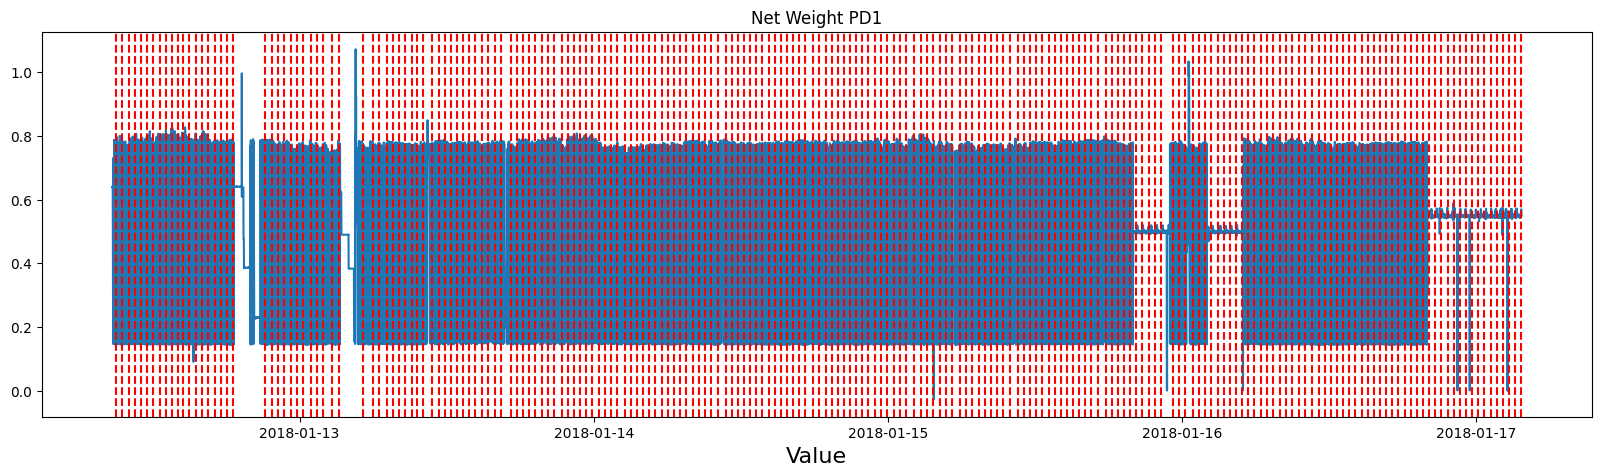

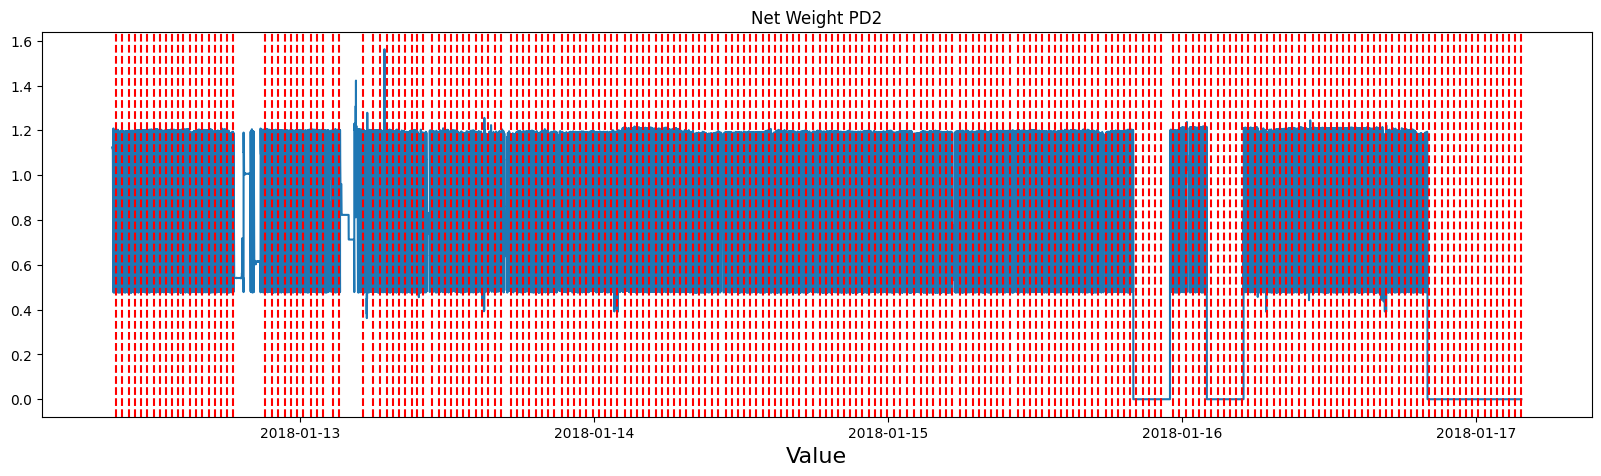

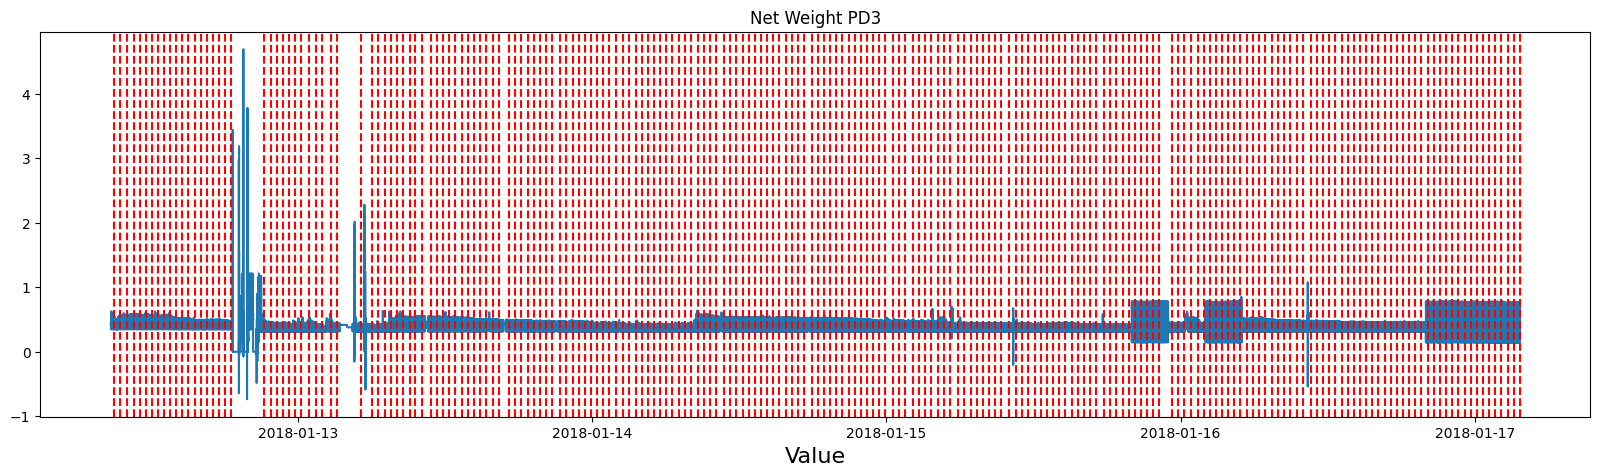

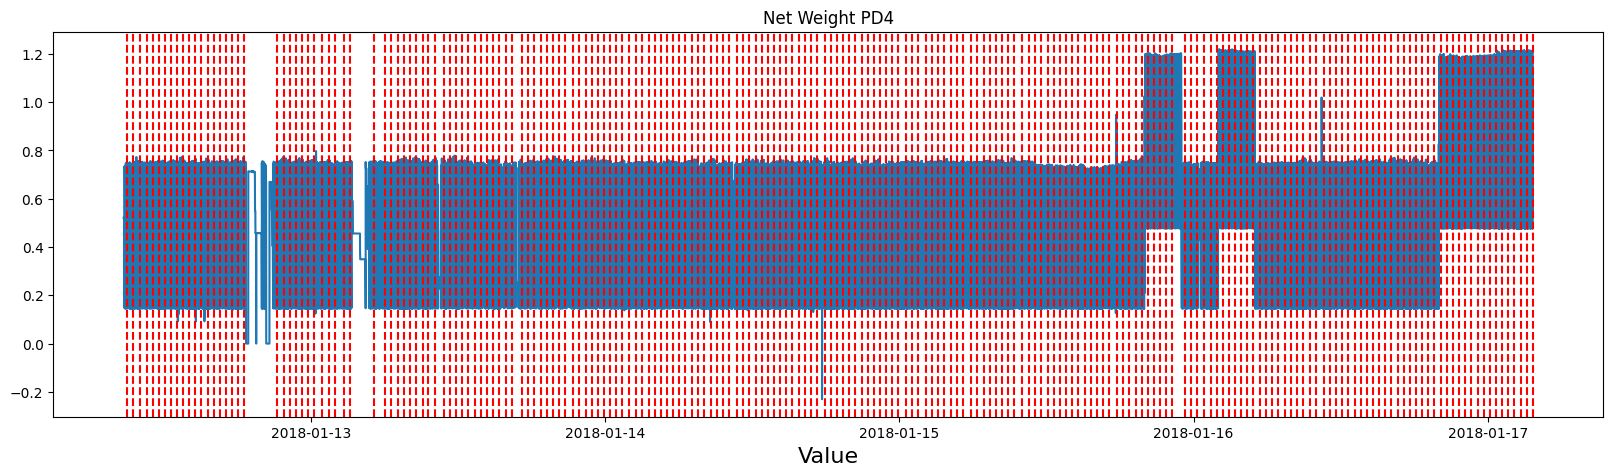

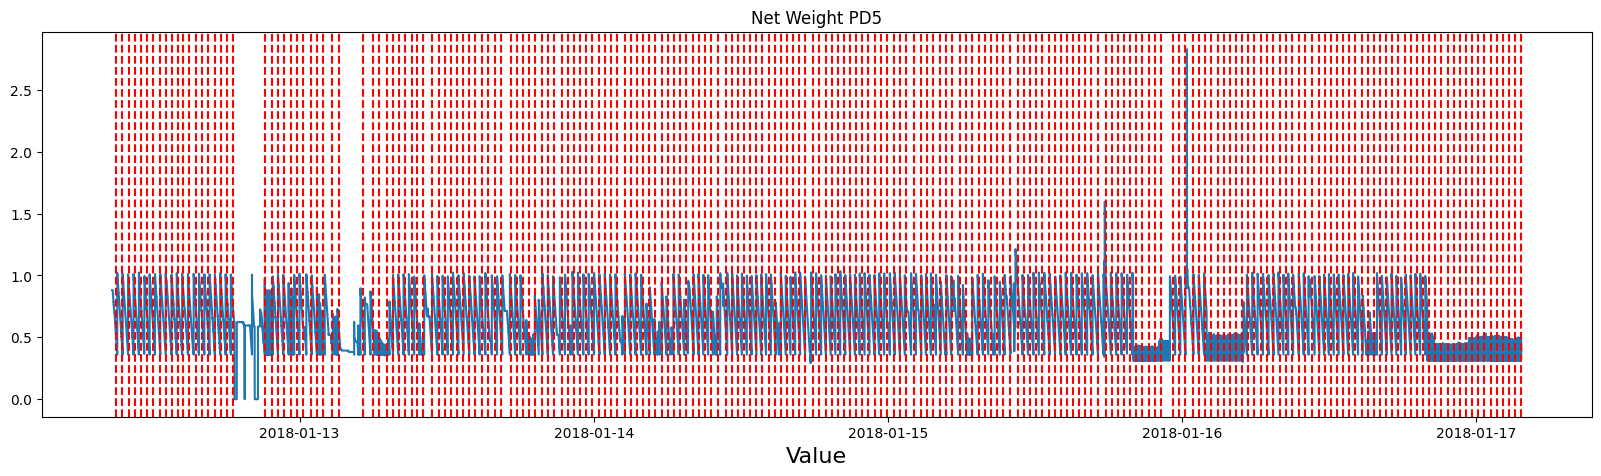

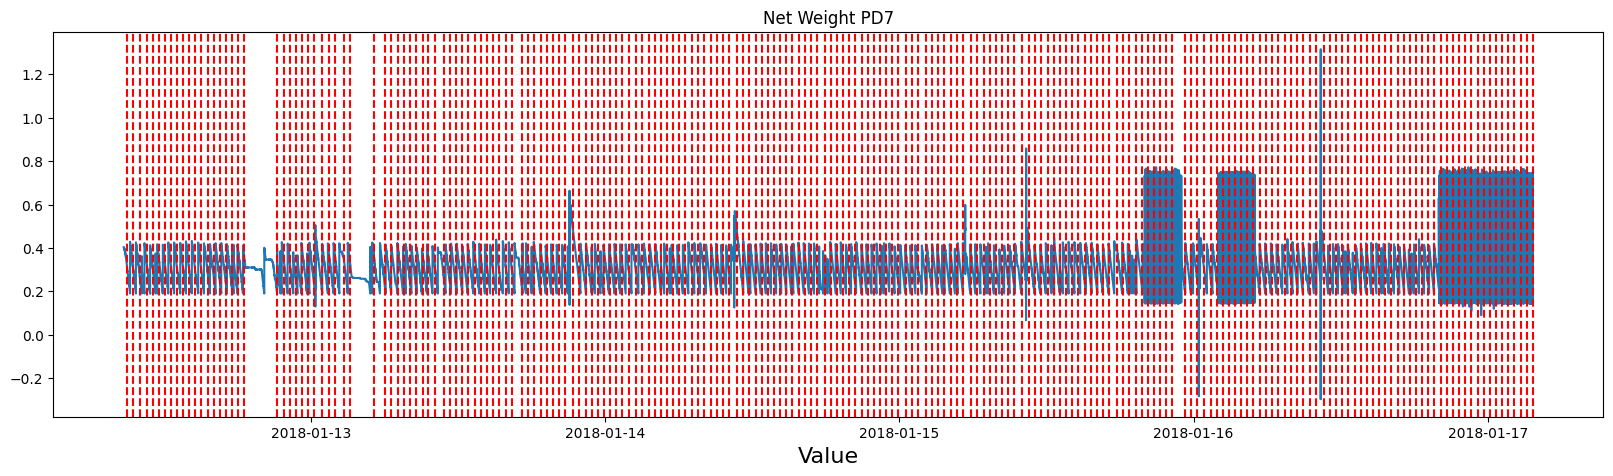

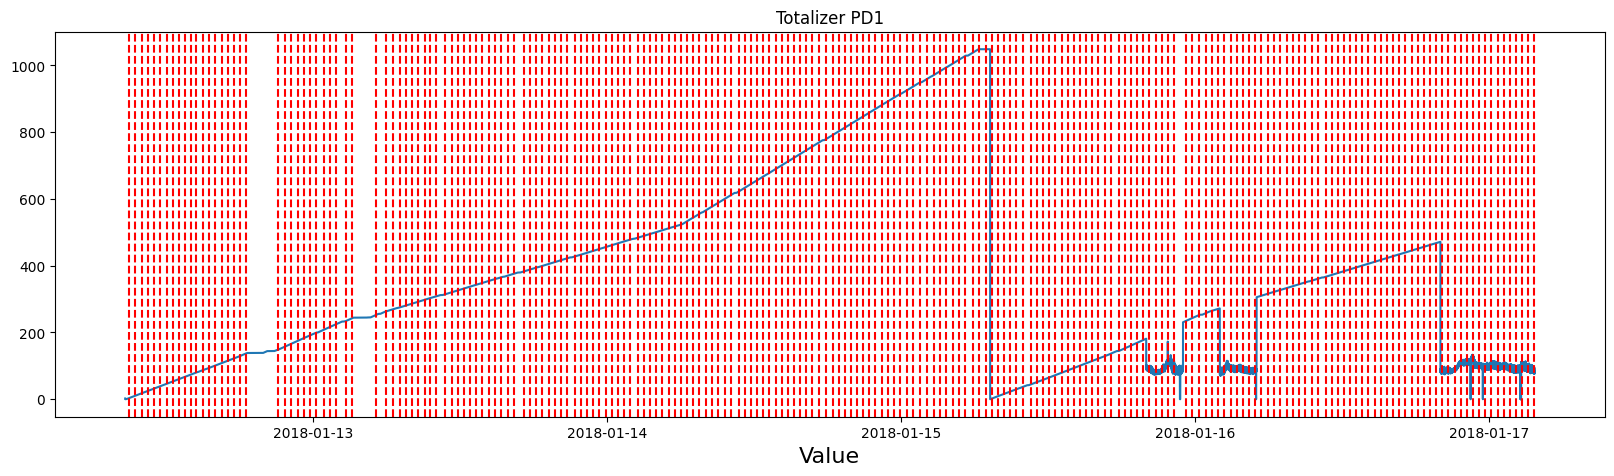

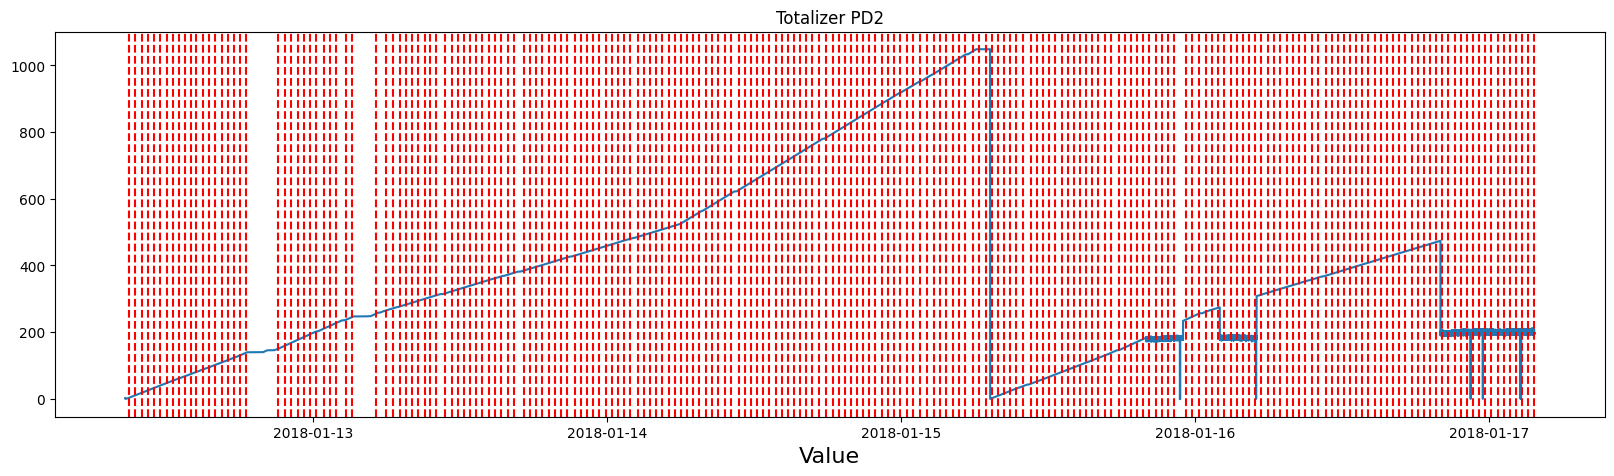

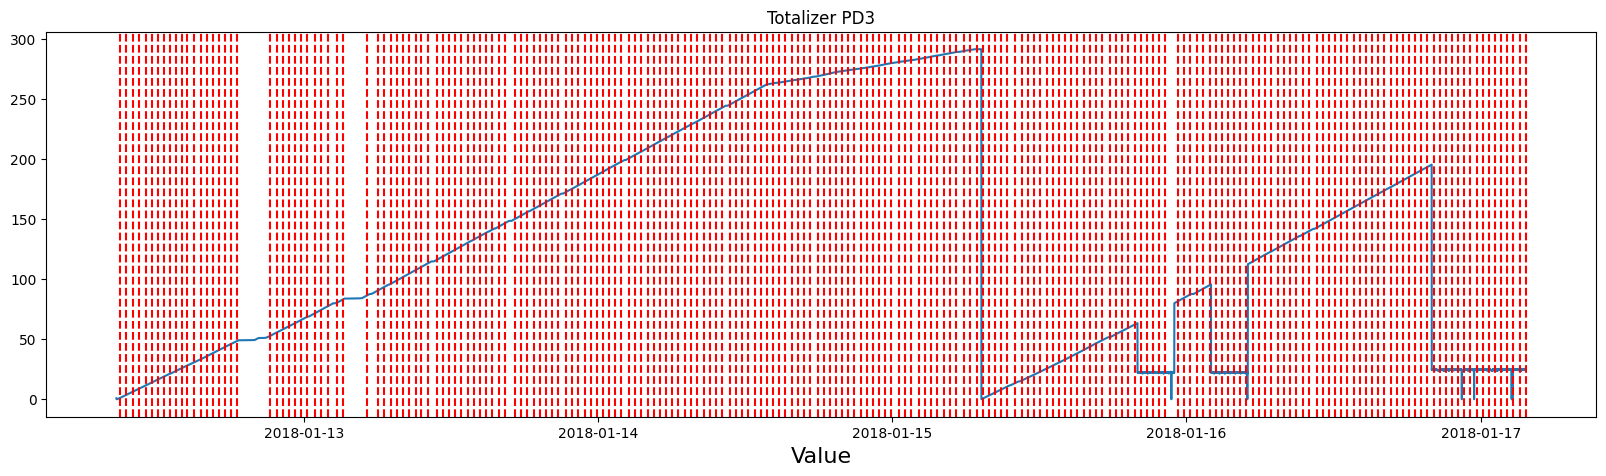

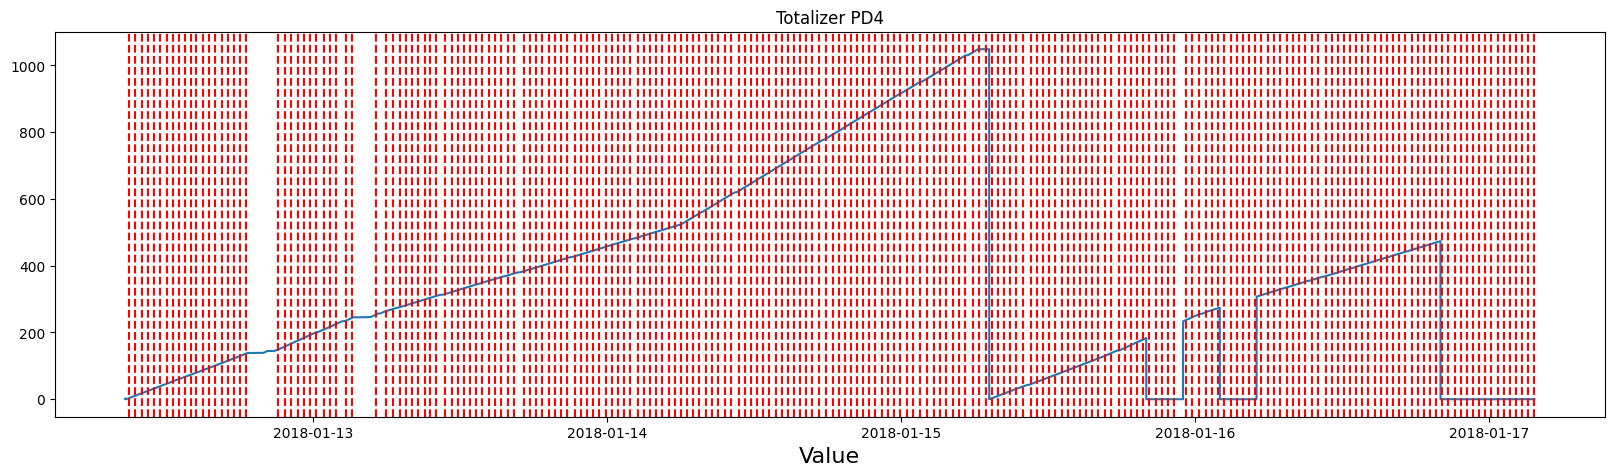

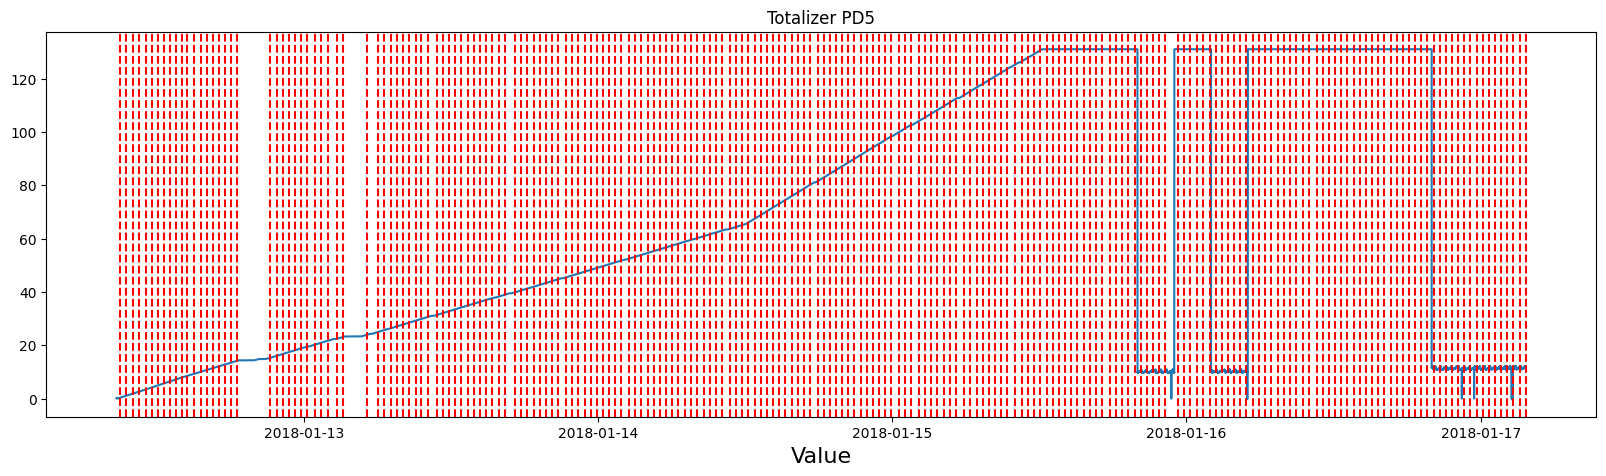

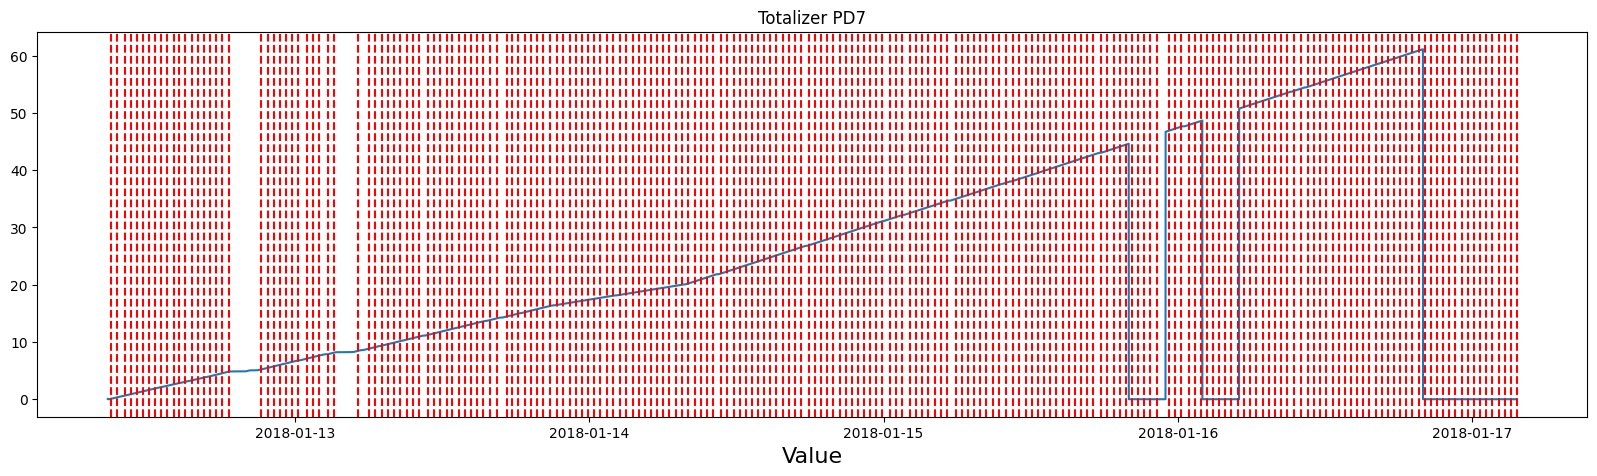

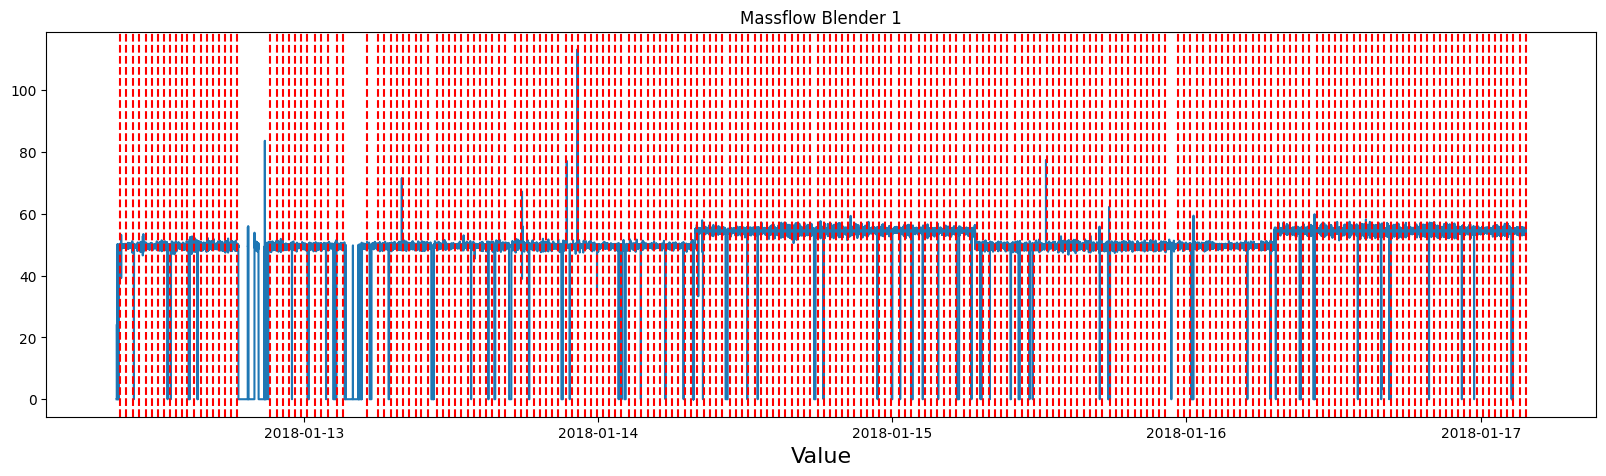

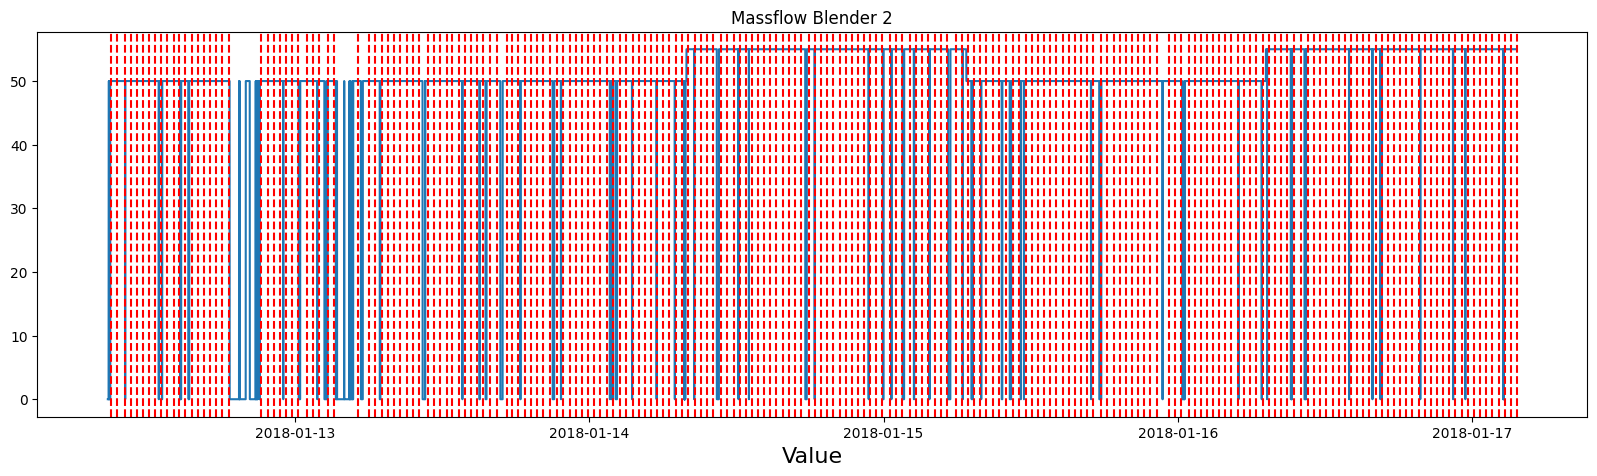

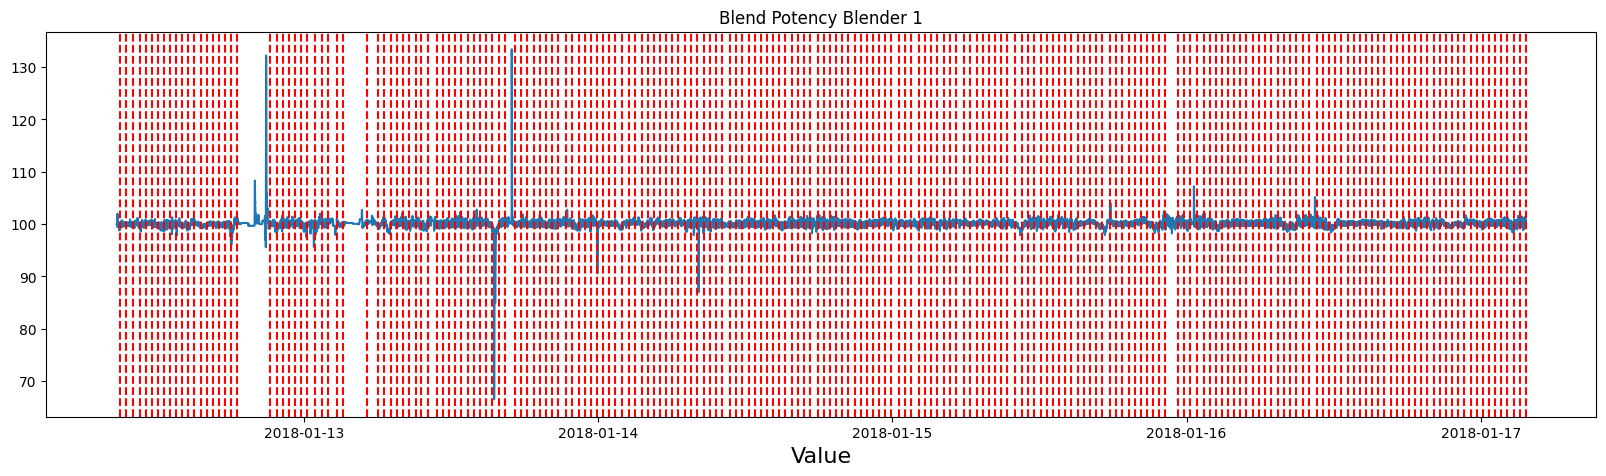

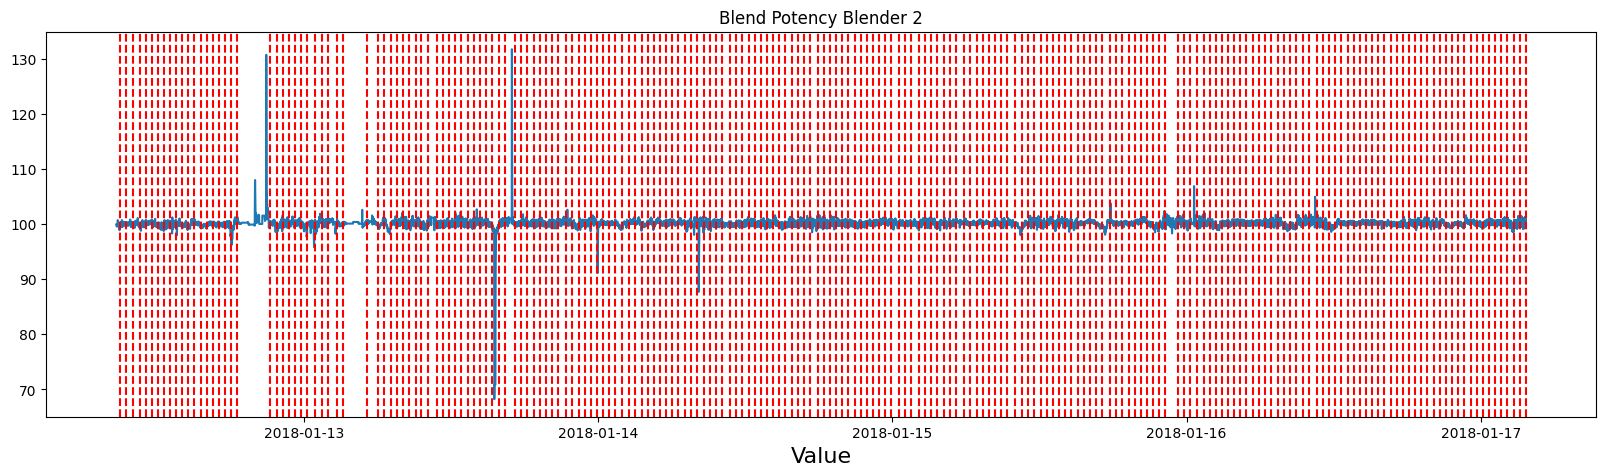

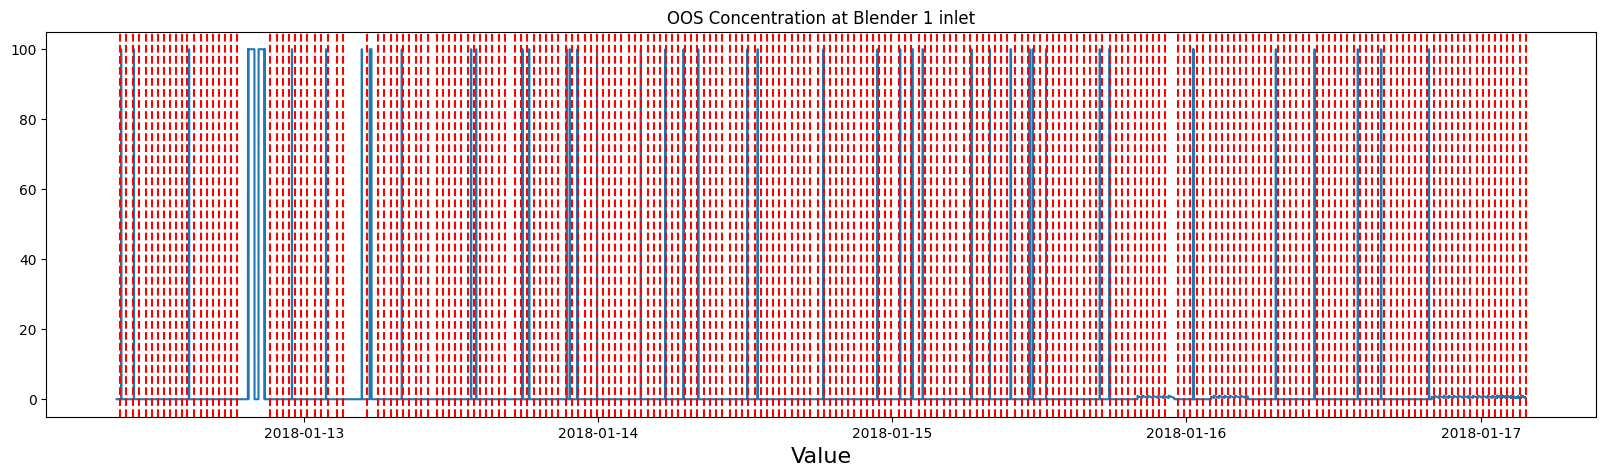

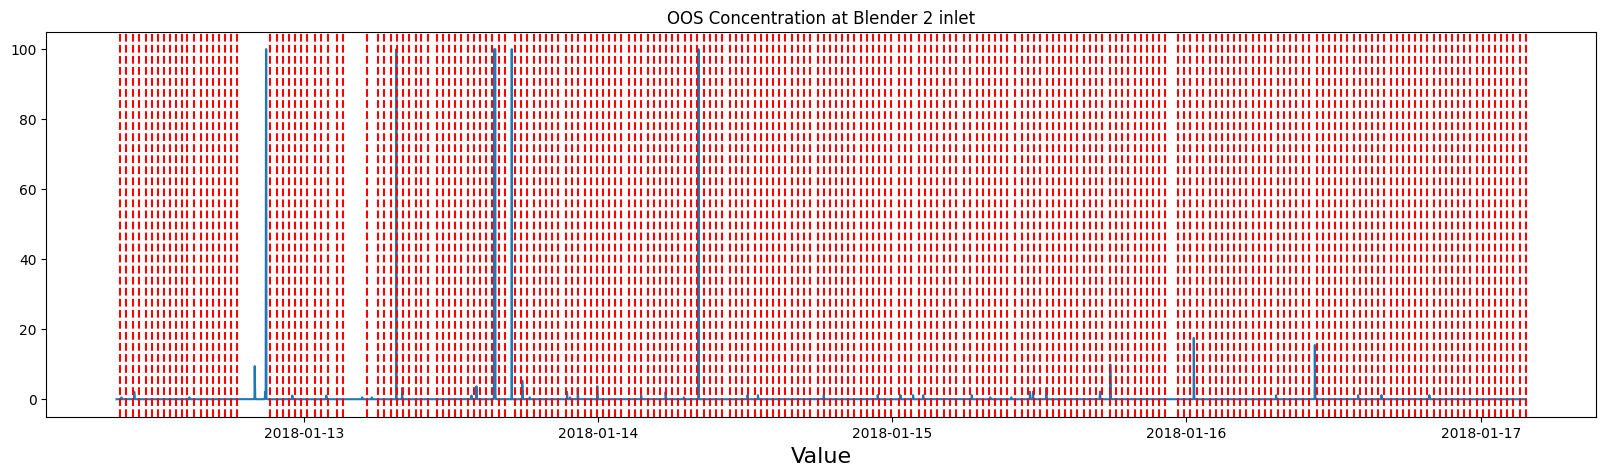

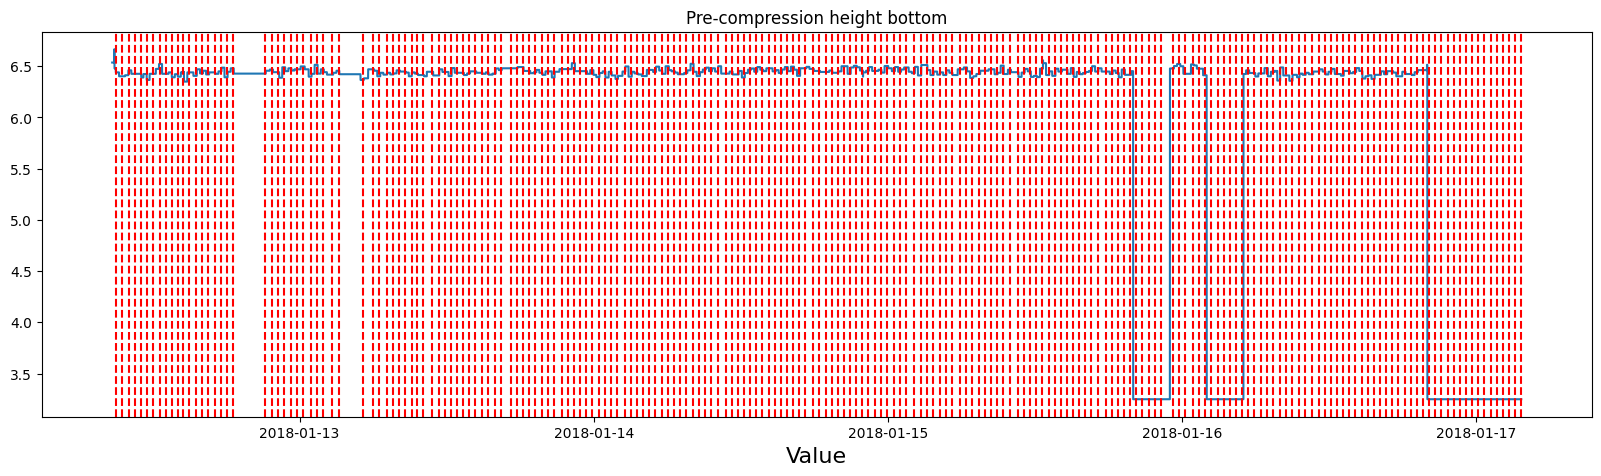

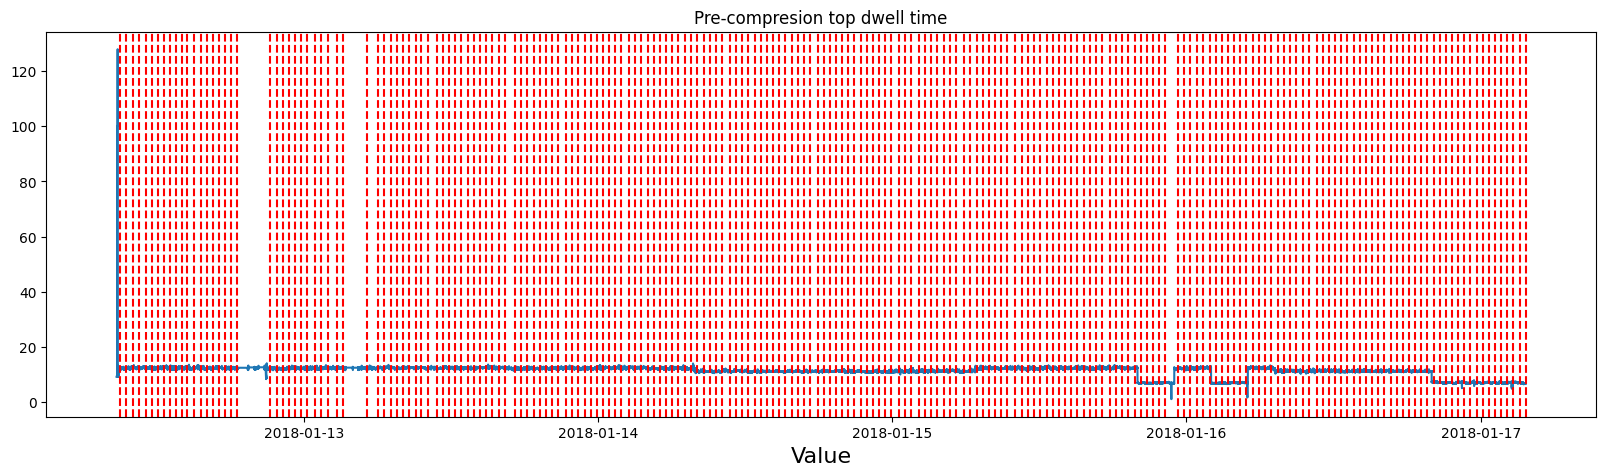

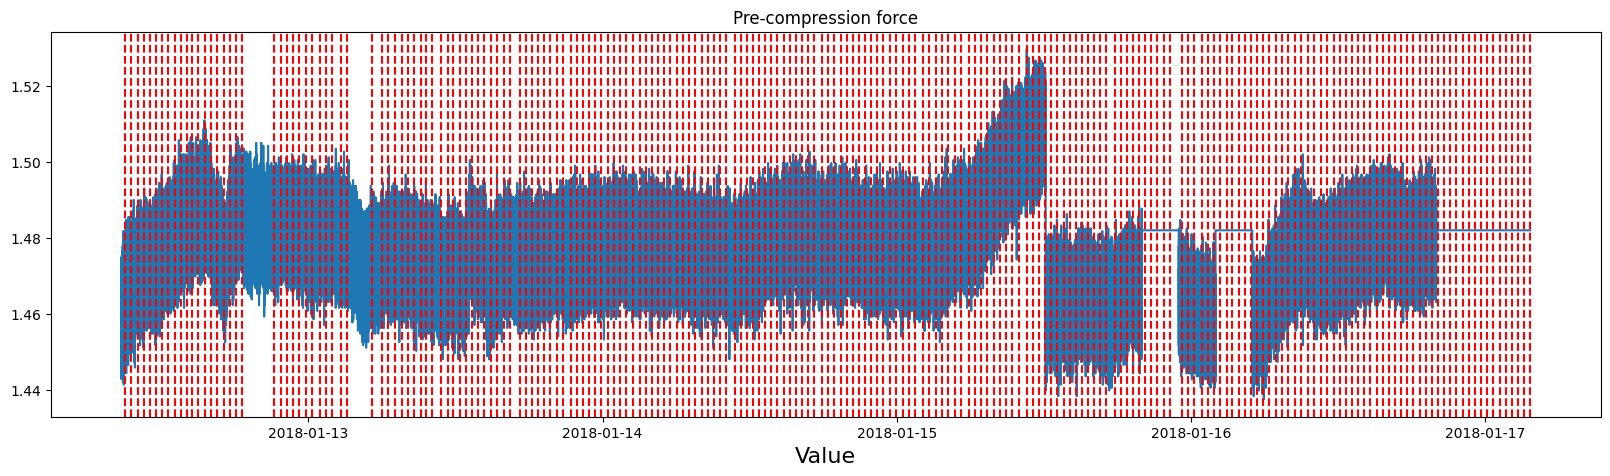

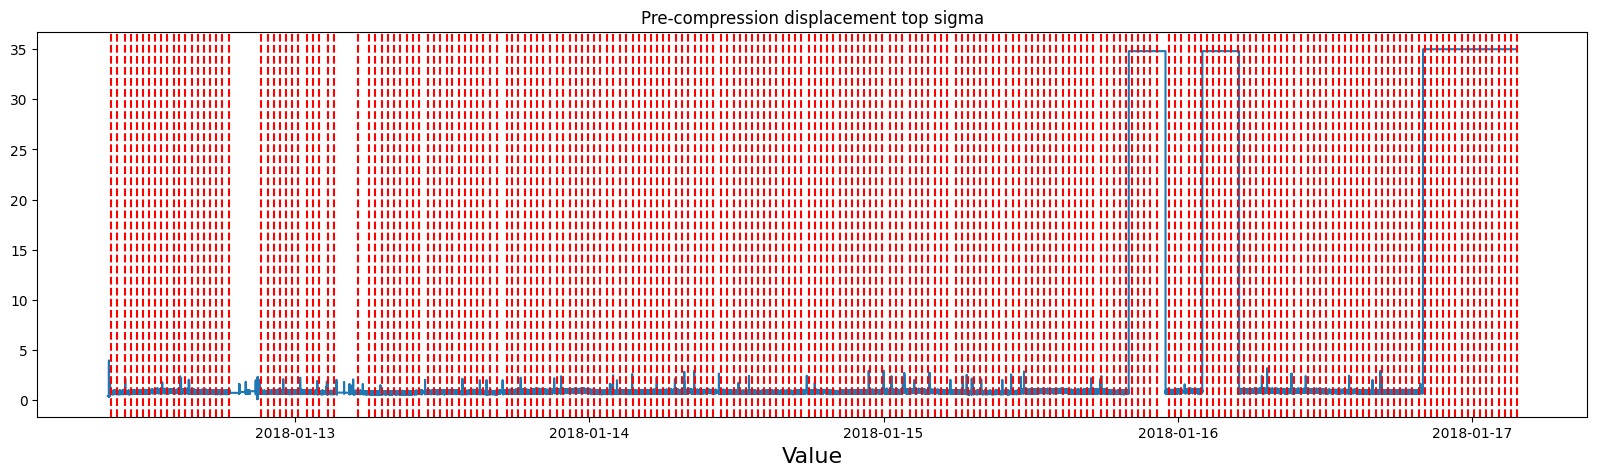

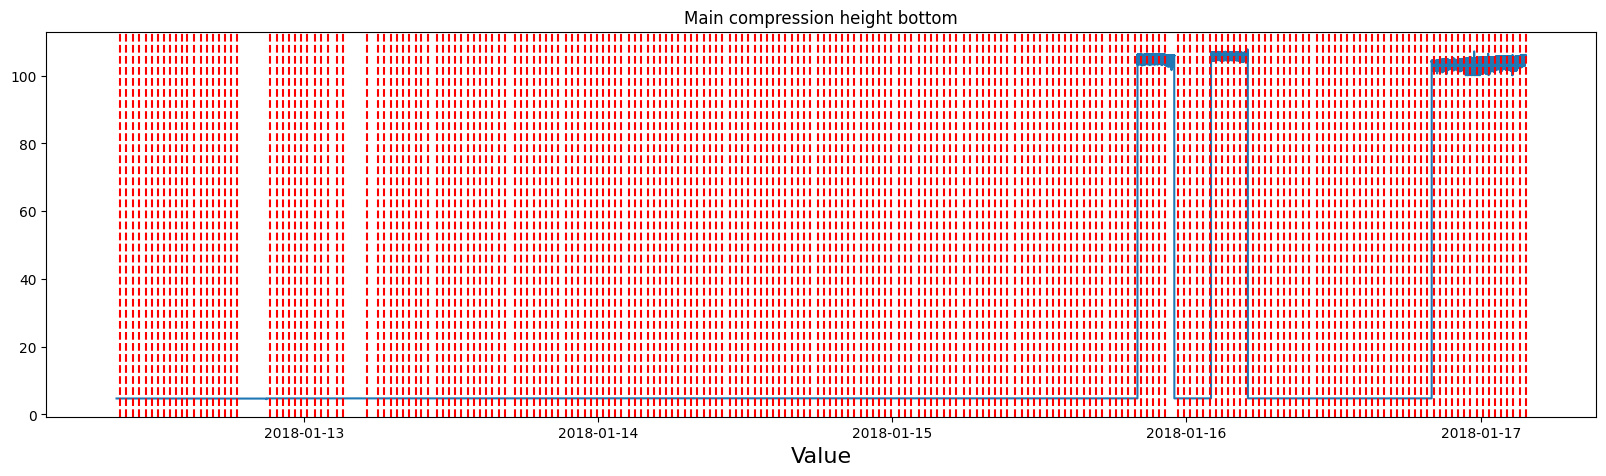

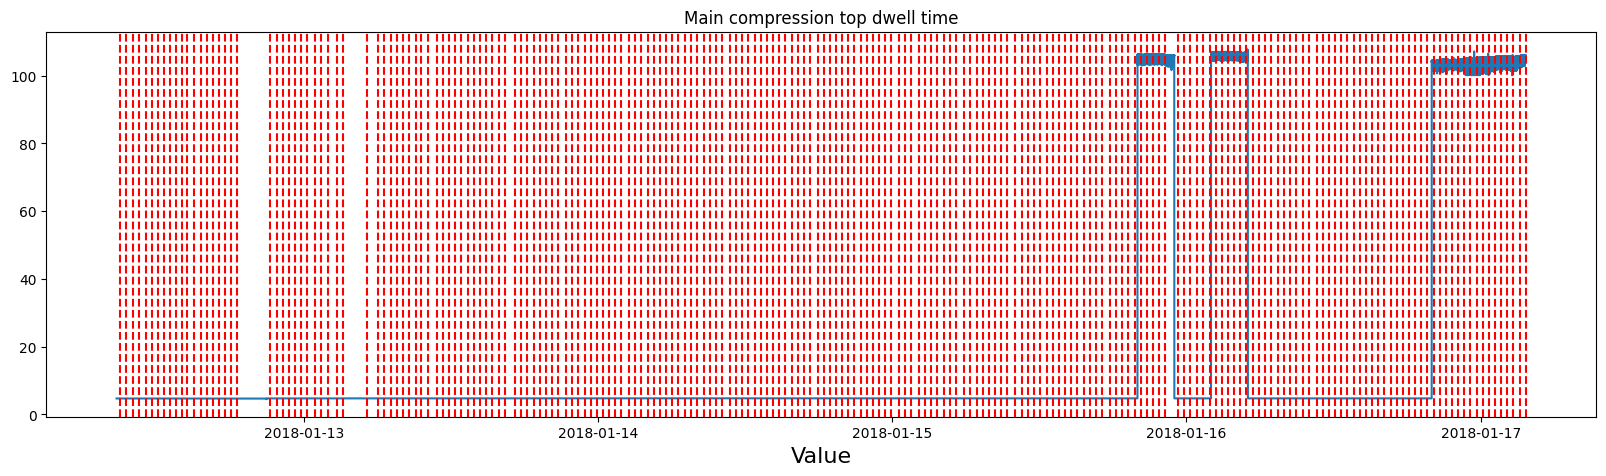

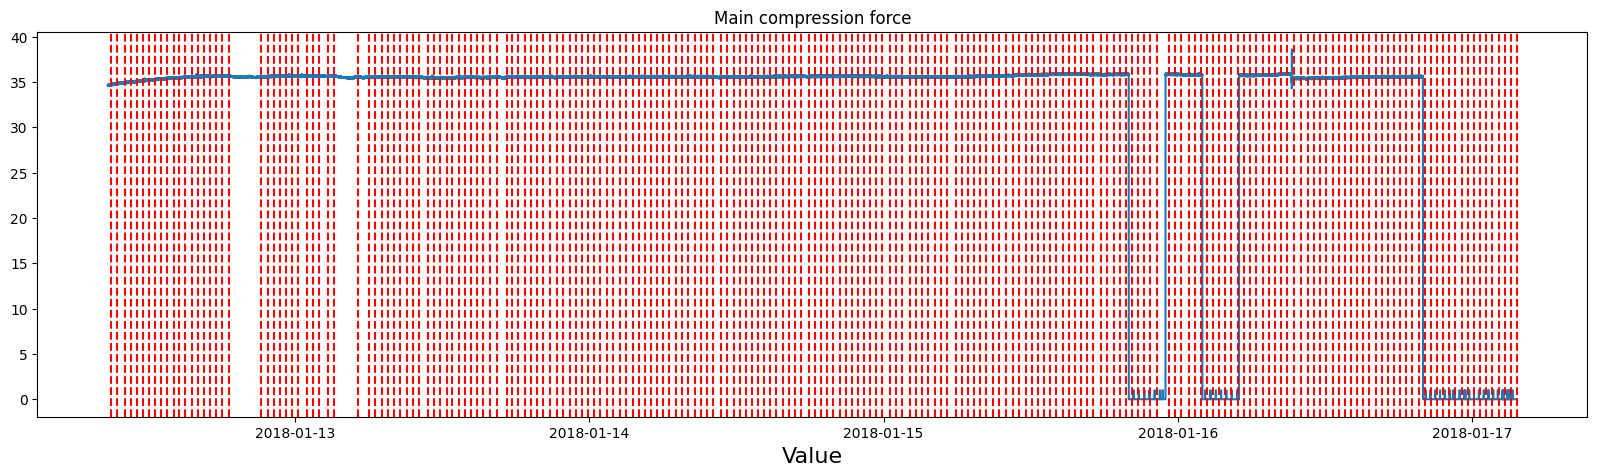

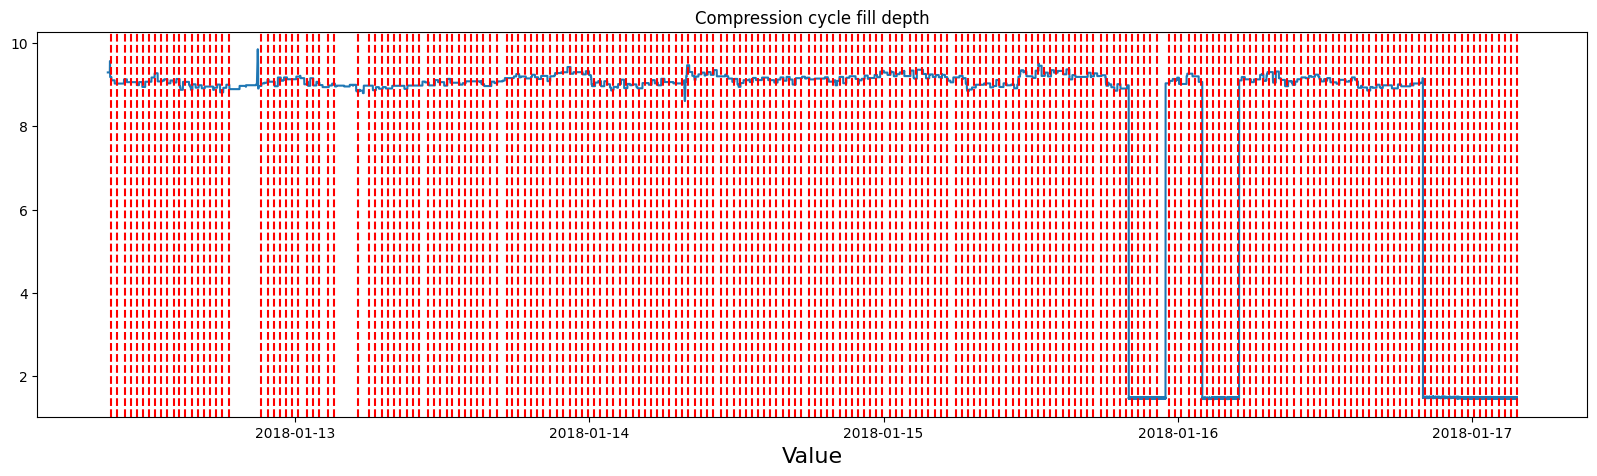

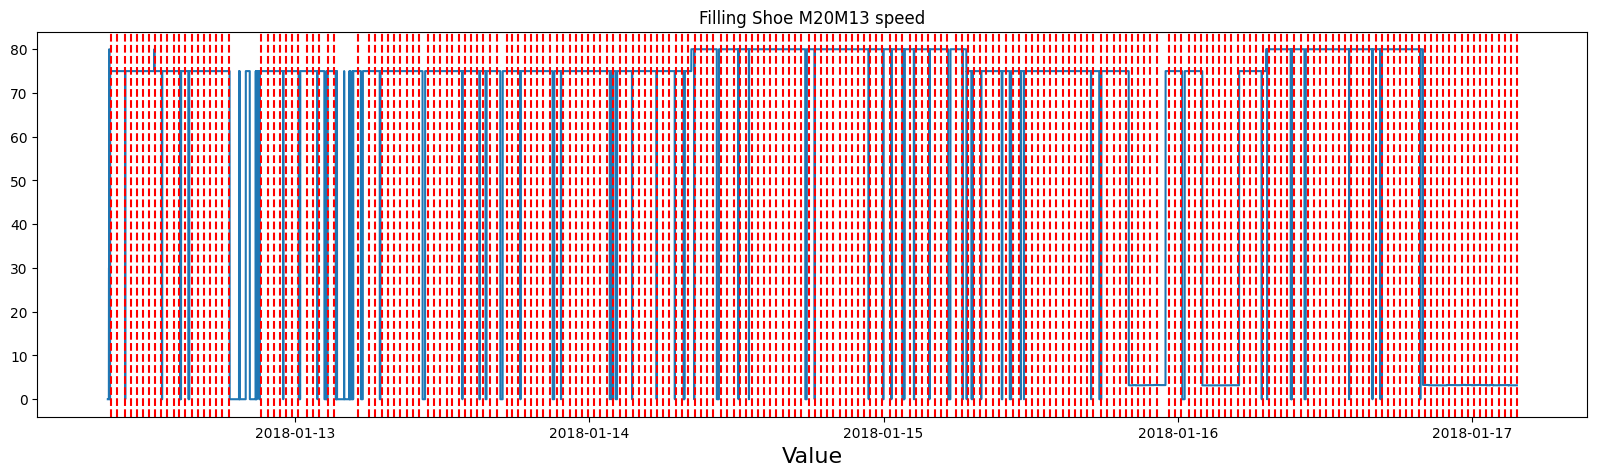

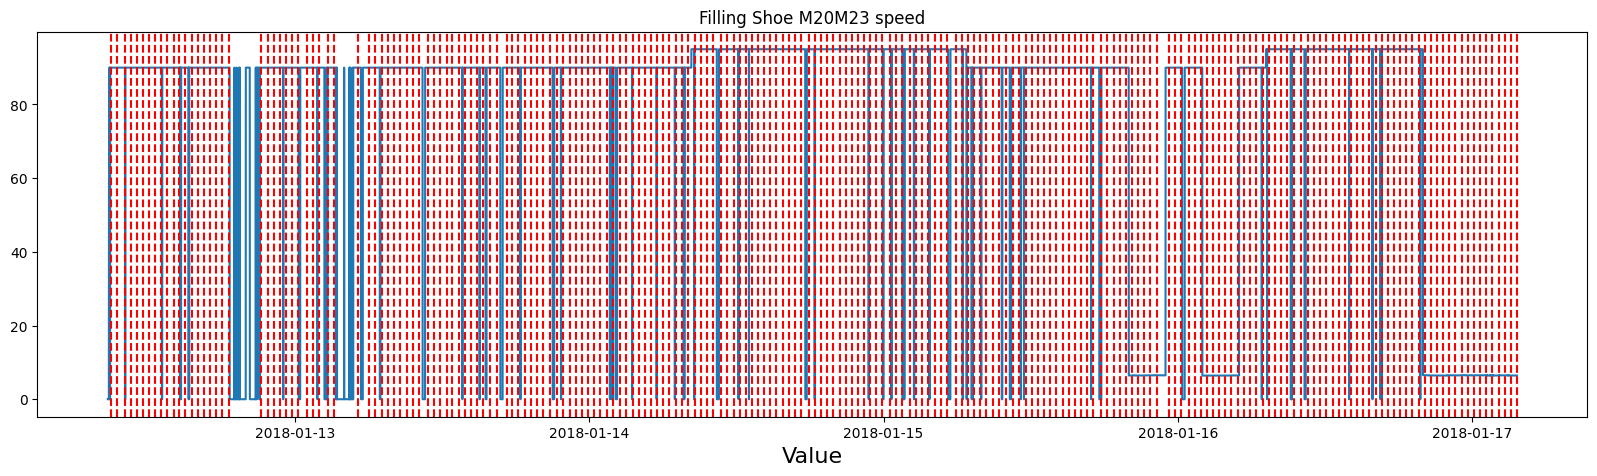

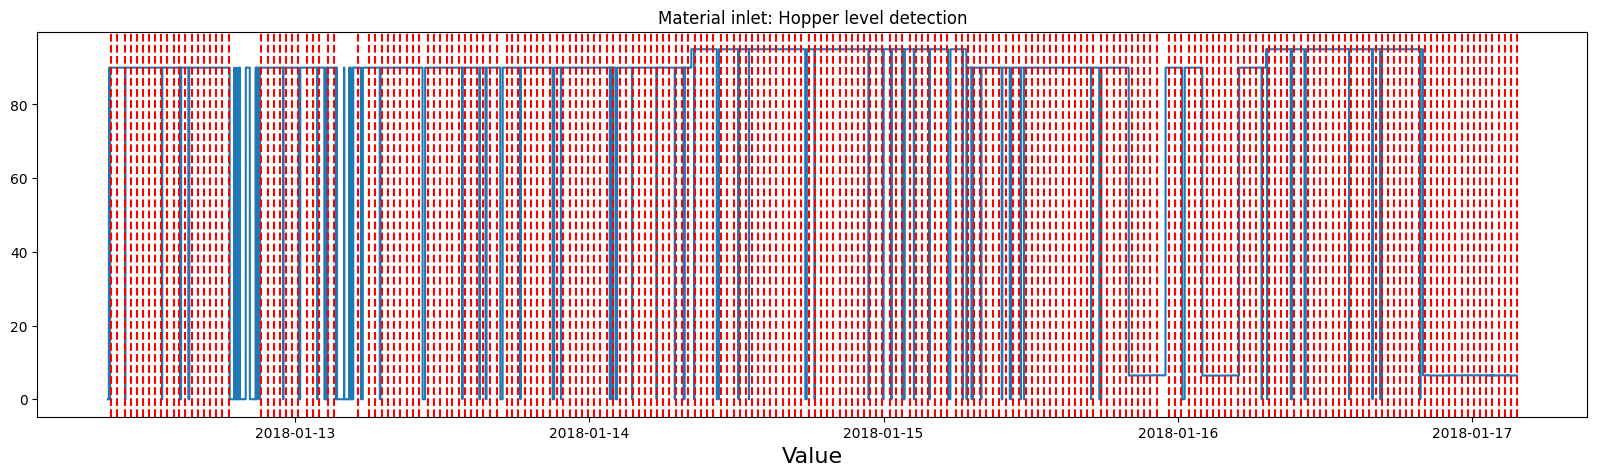

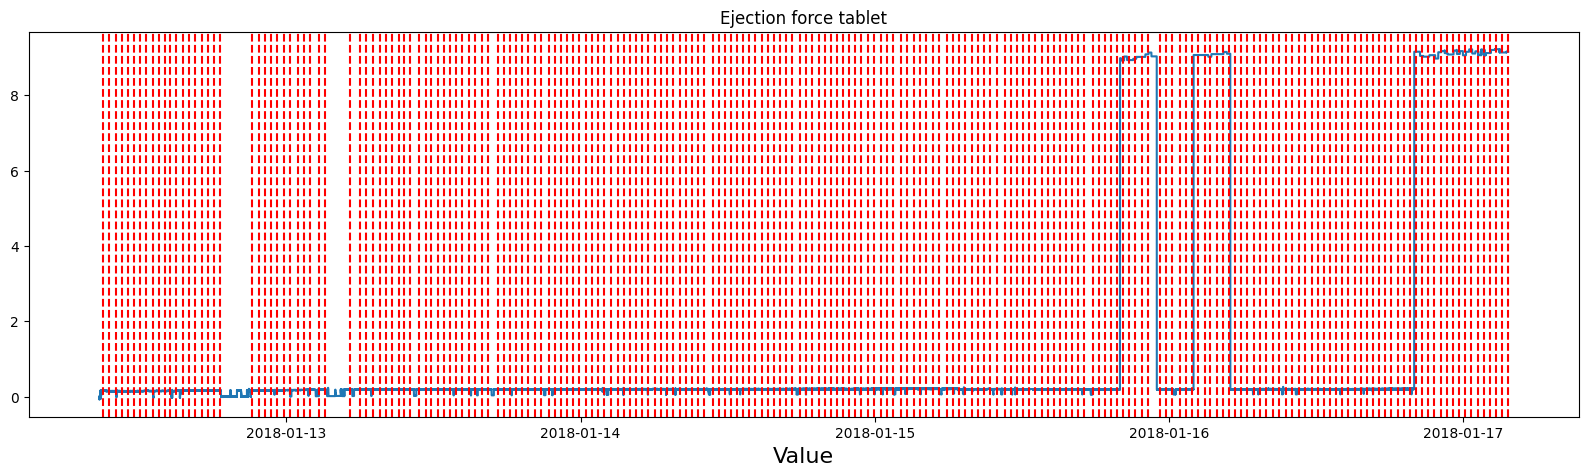

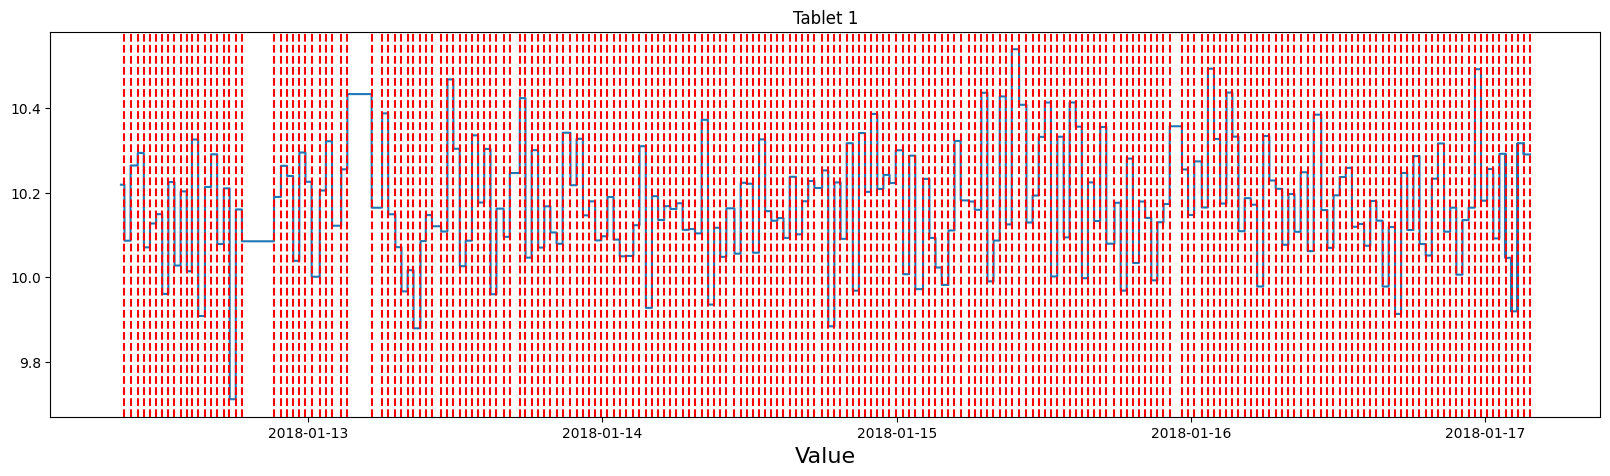

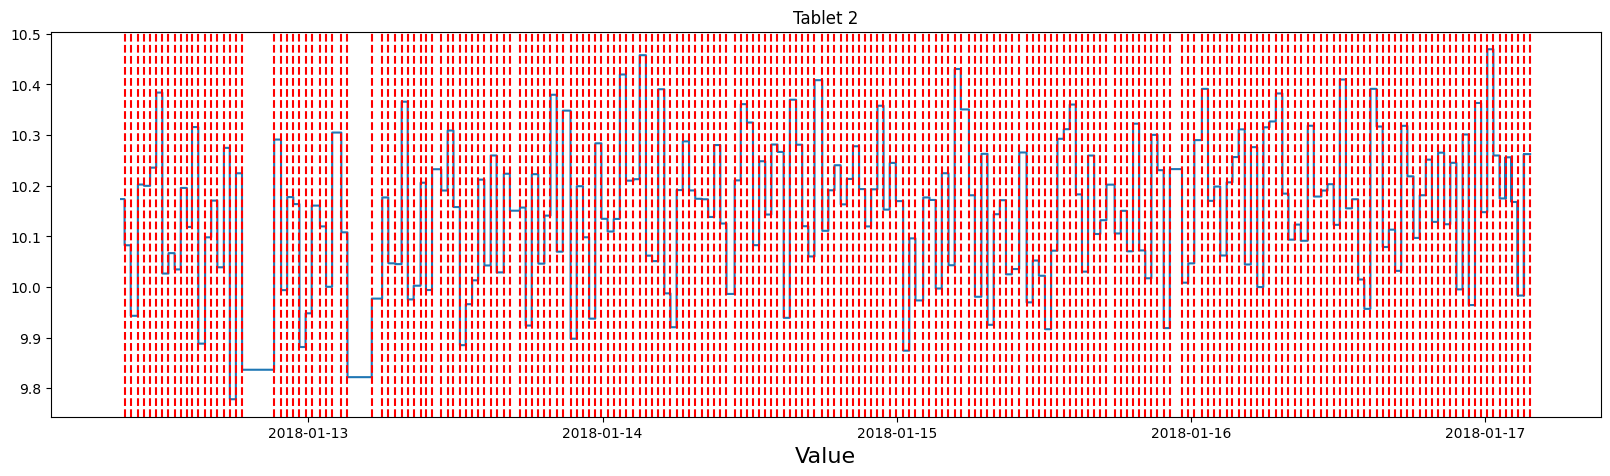

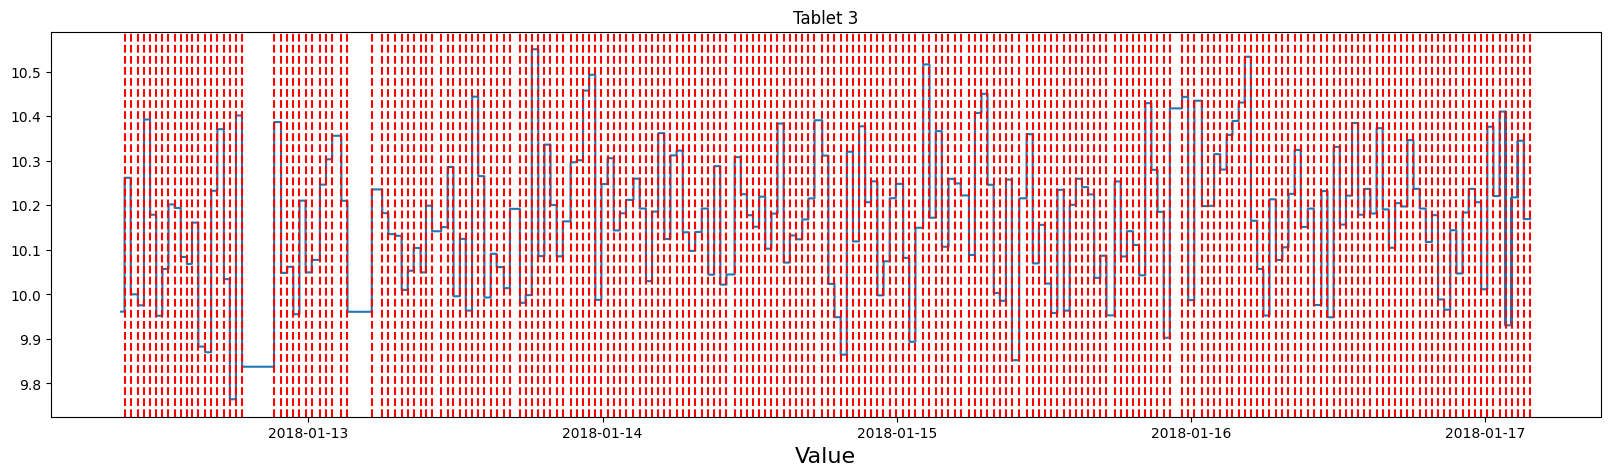

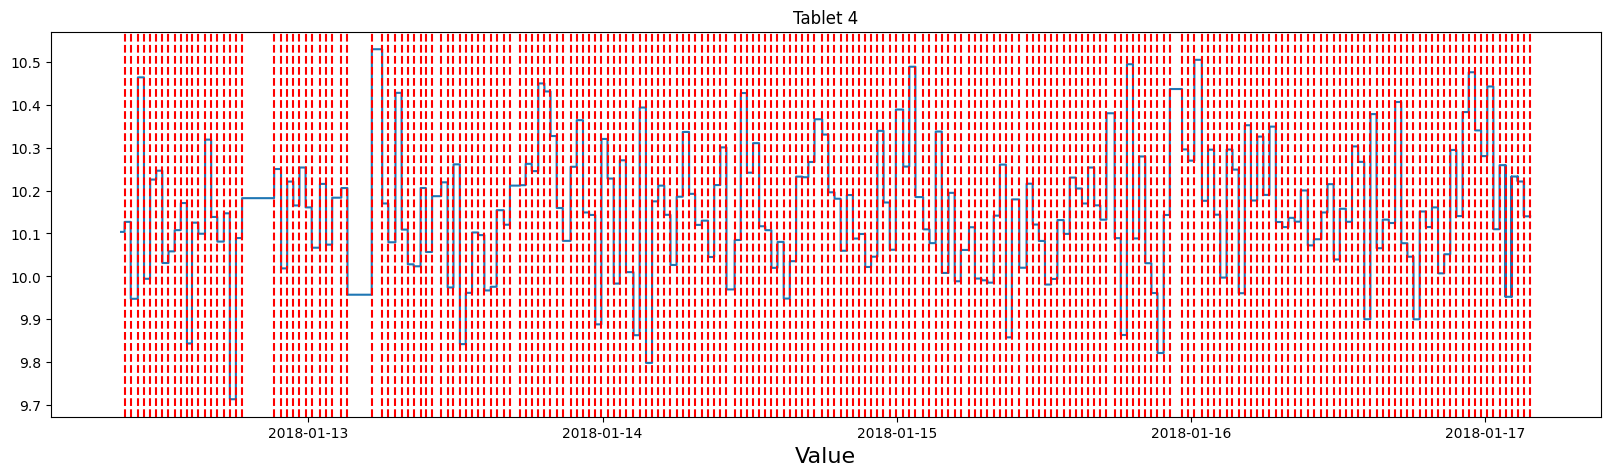

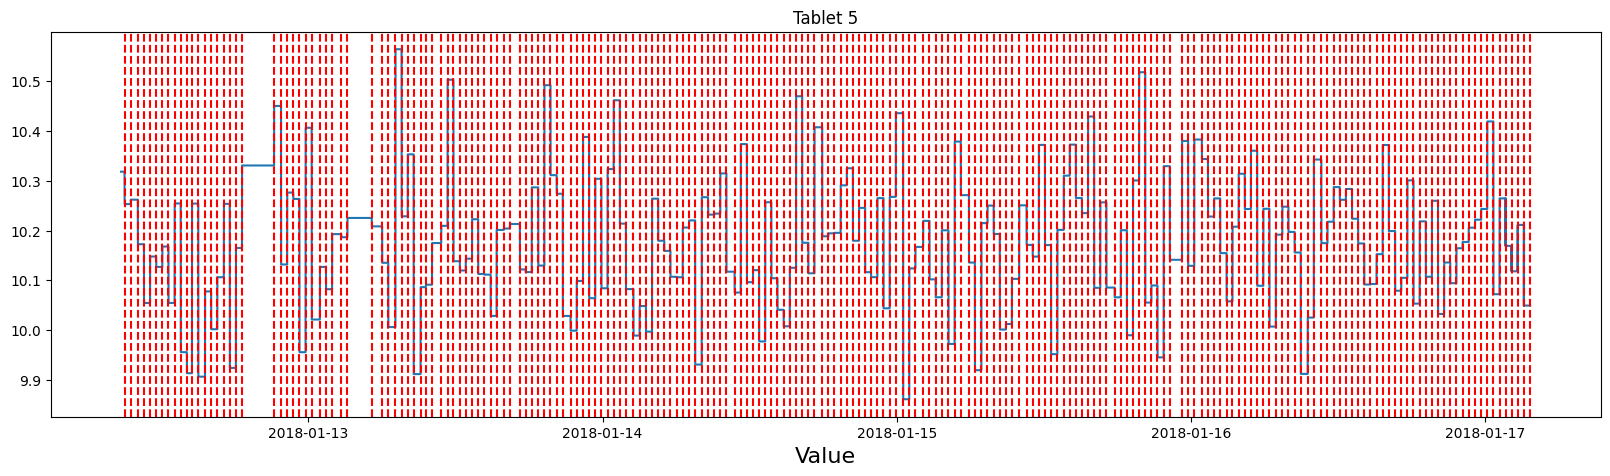

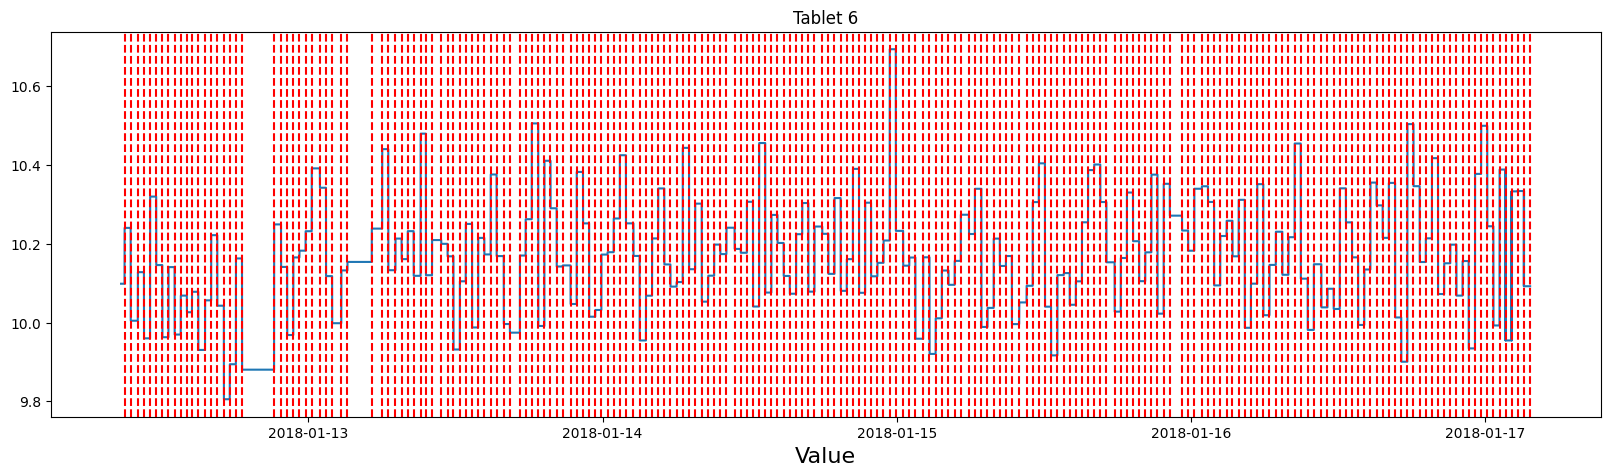

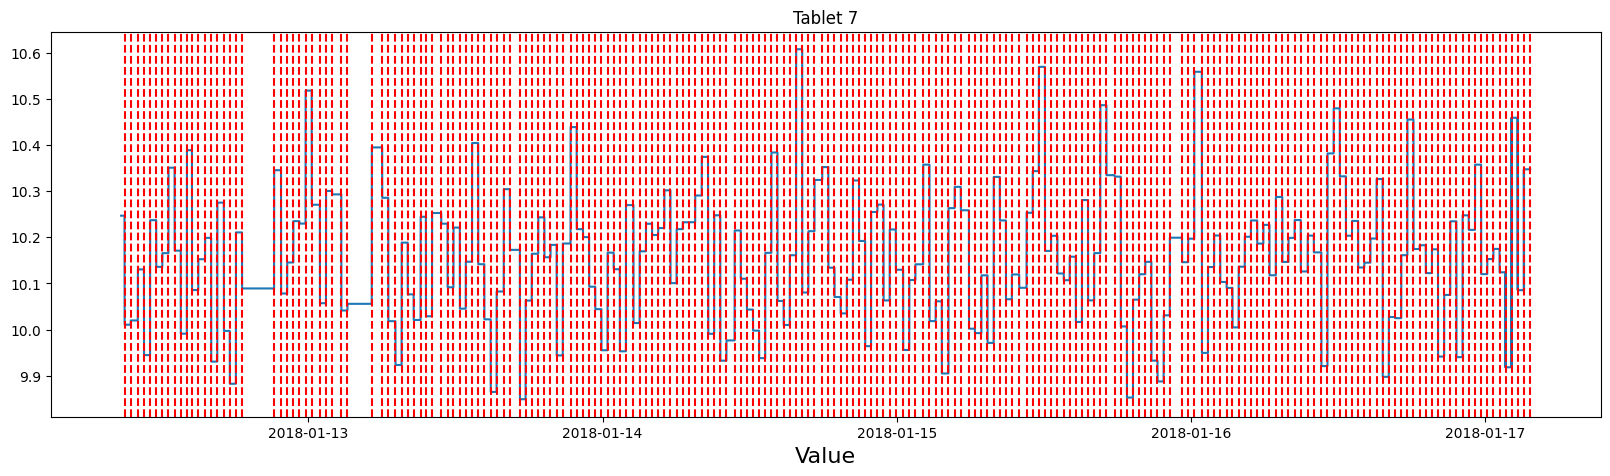

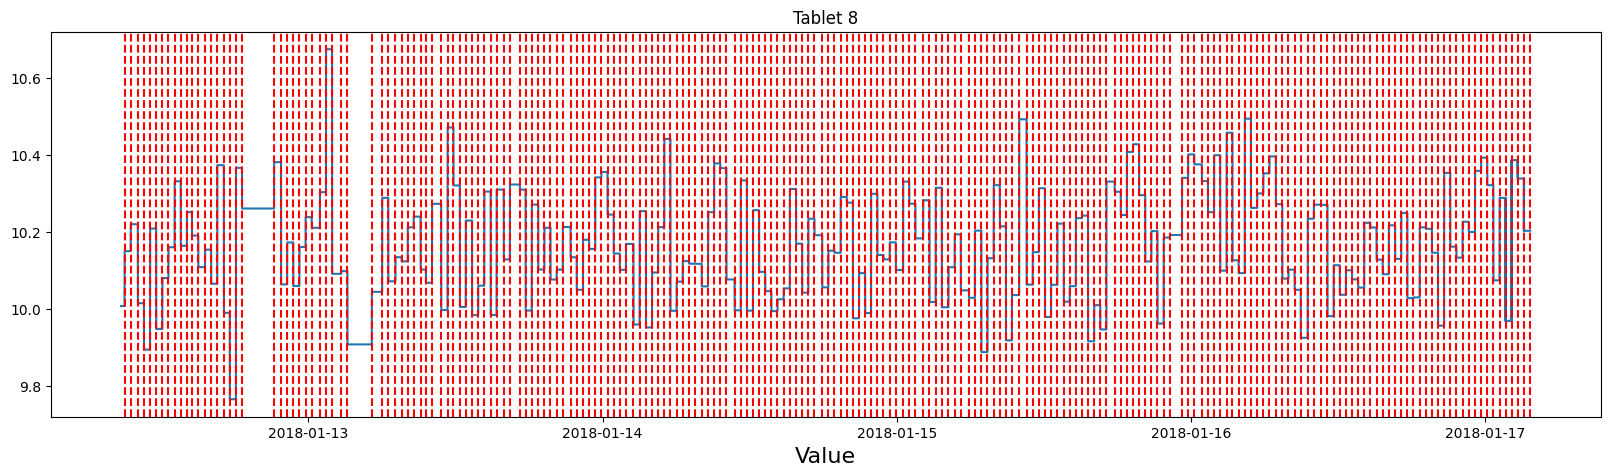

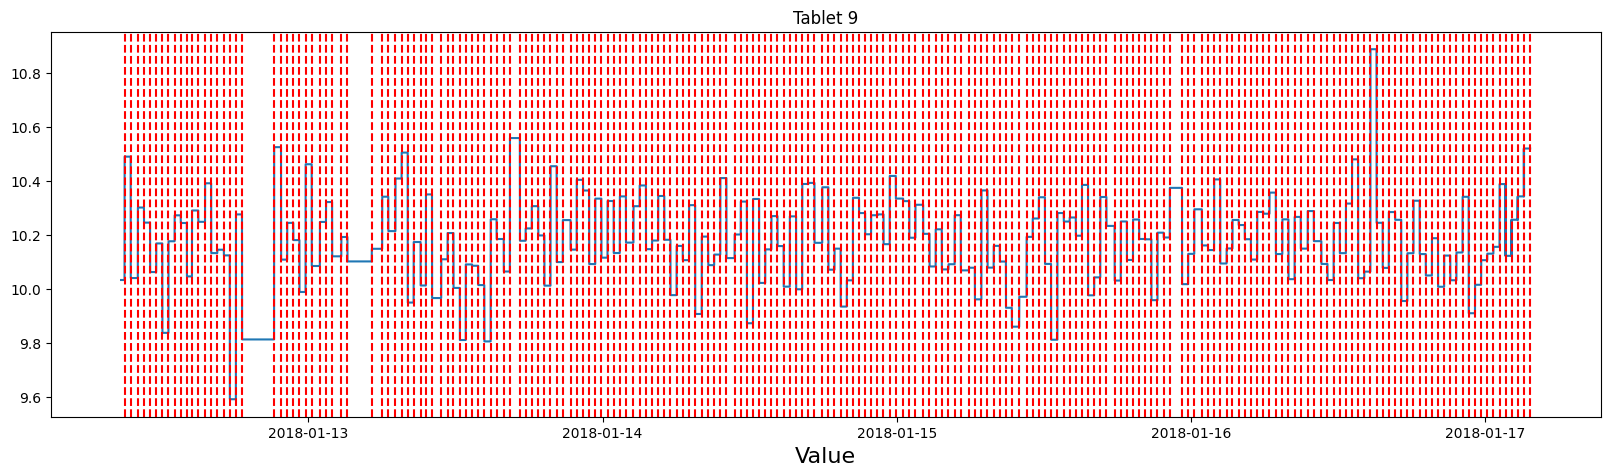

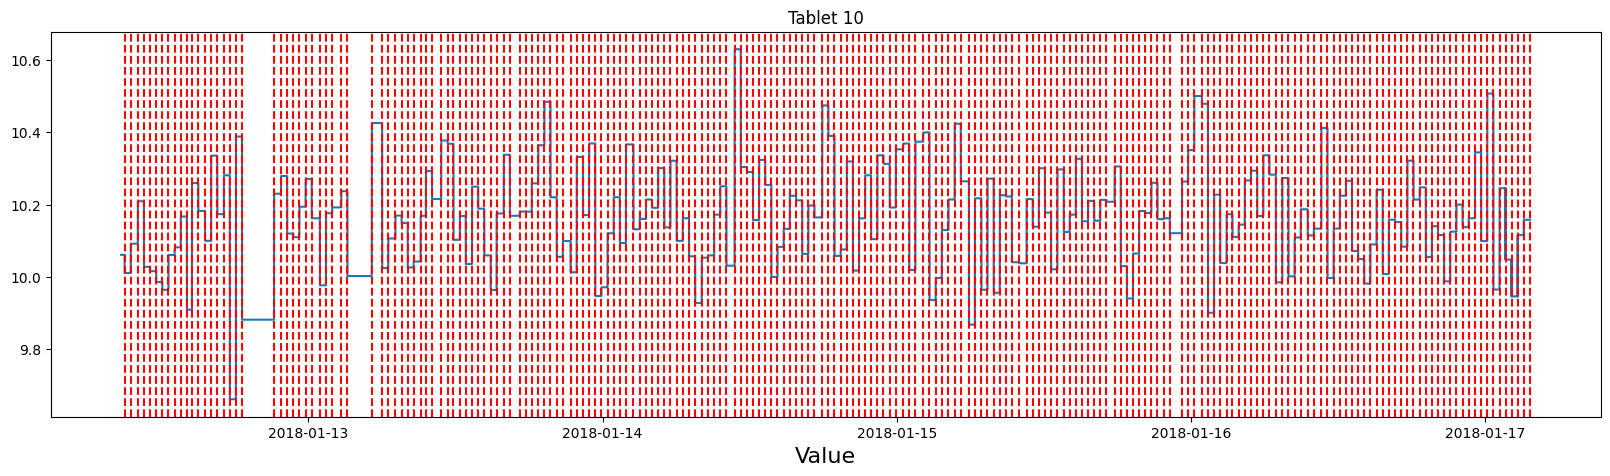

In [85]:
# KDA和時間序列圖
for col in result["API"].columns:
    if col not in ["TimeStamp", "Batch", "sample_time", "sample_id"]:
        plt.figure(figsize=(20, 5))
        
        # 如果是二元值
        if result['API'][col].unique().shape[0] == 2:
            plt.scatter(result['API']['TimeStamp'], result['API'][col], alpha=0.5)  # 繪製散點圖
            plt.yticks([0, 1])  # 限制 Y 軸為 0 和 1
        else:
            plt.plot(result['API']["TimeStamp"], result['API'][col])
        
        for sample_time in sample_times:
            plt.axvline(sample_time, color='r', linestyle='--')

        plt.title(col)
        plt.xlabel('Value', fontsize=16)
        plt.show()

# 數據分析

## 策略
1. 先將資料依照sample_time分組
2. 先用F檢定來找出顯著變數，再來使用機器學習方法來做預測
3. 使用PCA作為比較基礎

## 機器學習方法
1. 隨機森林回歸
2. XGboot

In [86]:
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

In [87]:
y.isna().sum()

sample_time    0
Tablet 1       1
Tablet 2       0
Tablet 3       1
Tablet 4       1
Tablet 5       1
Tablet 6       0
Tablet 7       0
Tablet 8       0
Tablet 9       0
Tablet 10      1
dtype: int64

In [88]:
target = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']
sample_time = sample_times[1]

# drop不會使用到的特徵
feature_df = result['API'].drop(columns=["TimeStamp", 'Batch', 'sample_id'] + target)

y = result['API'][['sample_time'] + target]

# 2. 將data依照sample time分組
X_group = feature_df.groupby('sample_time')
y = y.drop_duplicates()

lookback = min([len(X_group.get_group(_sample_time)) for _sample_time in sample_times])

group_X = X_group.get_group(sample_time).drop(columns=['sample_time']) # 取得該時間點的所有X
group_X = group_X.iloc[len(group_X) - lookback:,:] # 取得lookback筆數據
group_y = y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values # 取得該sample的目標陣列
group_y
# # 加入train_list中
# X_list.append(group_X.values.flatten()) # 展成一維數據
# y_list.append(group_y.flatten()) # 展成一維數據


array([[10.08629, 10.08254, 10.26188, 10.12708, 10.25302, 10.24025,
        10.01045, 10.14981, 10.49131, 10.01035]])

In [89]:
class TimeSeriesRandomForestRegressor:
    def __init__(self, model_name, df: pd.DataFrame, target: list[str], feature: list[str] = None, folds: int = 5, n_estimators=10, random_state=42):
        self.df = df.sort_values(by="TimeStamp")  # ✅ 確保數據按照時間排序
        self.target = target
        self.feature = feature
        self.model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
        self.model_name = model_name
        self.folds = folds

    def train(self) -> None:
        # 1. 選擇特徵
        feature_df = self.df

        # 轉換時間戳記為特徵
        feature_df['hour'] = feature_df["TimeStamp"].dt.hour
        feature_df['minute'] = feature_df["TimeStamp"].dt.minute
        feature_df['second'] = feature_df["TimeStamp"].dt.second
        feature_df['day_of_week'] = feature_df["TimeStamp"].dt.dayofweek
        feature_df['day_of_year'] = feature_df["TimeStamp"].dt.dayofyear

        # drop不會使用到的特徵
        feature_df = feature_df.drop(columns=["TimeStamp", 'Batch', 'sample_id'] + self.target)

        y = self.df[['sample_time'] + self.target]

        # 2. 將data依照sample time分組
        X_group = feature_df.groupby('sample_time')
        y = y.drop_duplicates()

        _sample_times = list(y['sample_time'])

        X_list = []
        y_list = []

        lookback = min([len(X_group.get_group(_sample_time)) for _sample_time in _sample_times])
        
        # 3. 使用lookback得分組資料分批訓練模型
        for sample_time in _sample_times:
            group_X = X_group.get_group(sample_time).drop(columns=['sample_time']) # 取得該時間點的所有X
            group_X = group_X.iloc[len(group_X) - lookback:,:] # 取得lookback筆數據
            group_y = y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values # 取得該sample的目標陣列

            # 加入train_list中
            X_list.append(group_X.values.flatten()) # 展成一維數據
            y_list.append(group_y.flatten()) # 展成一維數據

        # 4. 將feature和target轉換成np.array
        X = np.array(X_list)
        y = np.array(y_list)
        
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
        y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)

        # 設定時間序列交叉驗證
        tscv = TimeSeriesSplit(n_splits=self.folds)

        mse_scores = []
        r2_scores = []

        # 進行時間序列交叉驗證
        for fold, (train_index, test_index) in enumerate(tqdm(tscv.split(X_train), total=self.folds, desc="Time Series Cross Validation"), start=1):
            X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
            y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

            self.model.fit(X_train_fold, y_train_fold)
            y_pred_fold = self.model.predict(X_test_fold)
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            r2_fold = r2_score(y_test_fold, y_pred_fold)
            mse_scores.append(mse_fold)
            r2_scores.append(r2_fold)

        print(f"Time Series Cross Validation MSE Mean: {np.mean(mse_scores)}")
        print(f"Time Series Cross Validation R² Mean: {np.mean(r2_scores)}")

        # **4. 使用最終訓練集來訓練模型**
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Final Test MSE: {mse}")
        print(f"Final Test R²: {r2}")

        # **5. 將預測點與實際點視覺化**
        for i in range(len(self.target)):
            y_pred_temp = y_pred[:, i]
            y_test_temp = y_test[:, i]
            self.diagram(y_pred_temp, y_test_temp, i)

        # **6. 將model儲存
        joblib.dump(self.model, f"./model/{self.model_name}.pkl")
        print(f"Model saved to ./model/{self.model_name}.pkl") 

    # 丟進一些資料，透過這些資料預測結果
    def diagram(self, y_pred: np.ndarray, y_test: np.ndarray, index: int) -> None:        
        plt.figure(figsize=(20, 5))
        _sample_times = self.df["sample_time"].unique() # return date array

        _sample_times = _sample_times[-len(y_test):]

        # **確保 sample_times 為 X 軸**
        plt.plot(_sample_times, y_pred, label="Predicted Value", linestyle="--", marker="o")
        plt.plot(_sample_times, y_test, label="Actual Value", linestyle="-", marker="x")

        plt.xlabel("Sample Time")
        plt.ylabel("Value")
        plt.xticks(rotation=45)  # 旋轉 X 軸標籤，方便閱讀
        plt.title(f"Tablet {index+1}")
        plt.legend()
        plt.grid()
        plt.show()


In [90]:
targets = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']

Time Series Cross Validation: 100%|██████████| 5/5 [16:15<00:00, 195.14s/it]


Time Series Cross Validation MSE Mean: 0.021125681400758694
Time Series Cross Validation R² Mean: -0.09150610799318706
Final Test MSE: 0.0244672942770011
Final Test R²: -0.0516288780255992


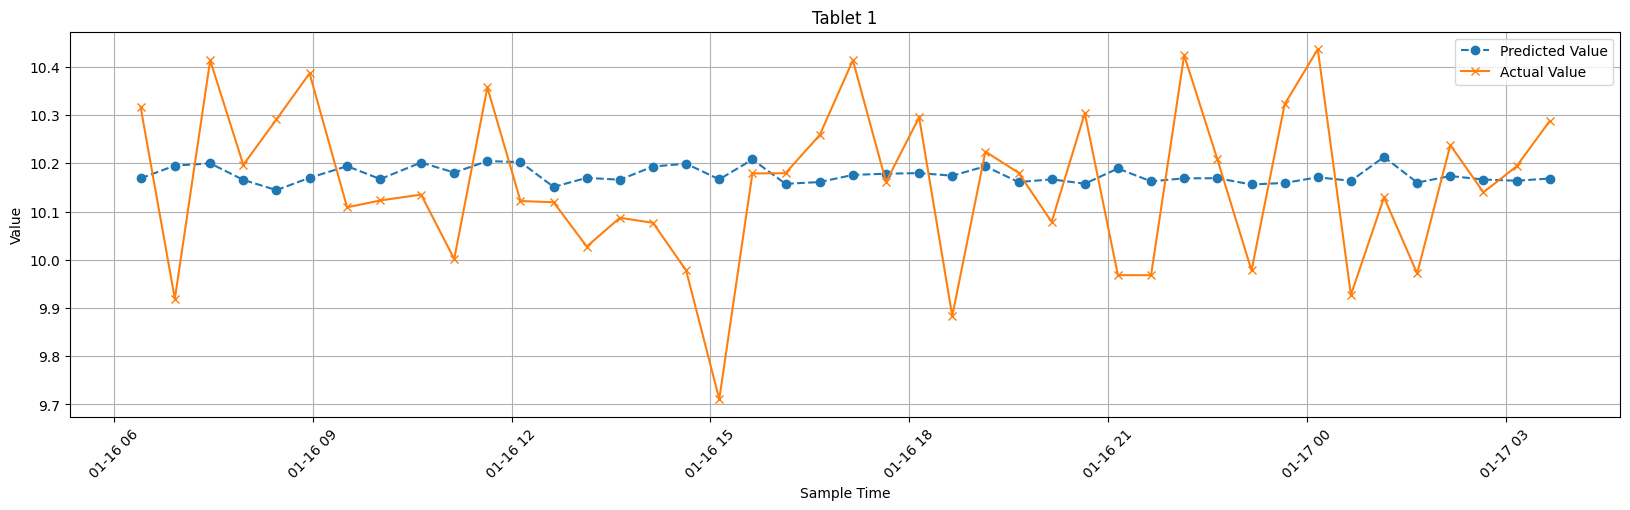

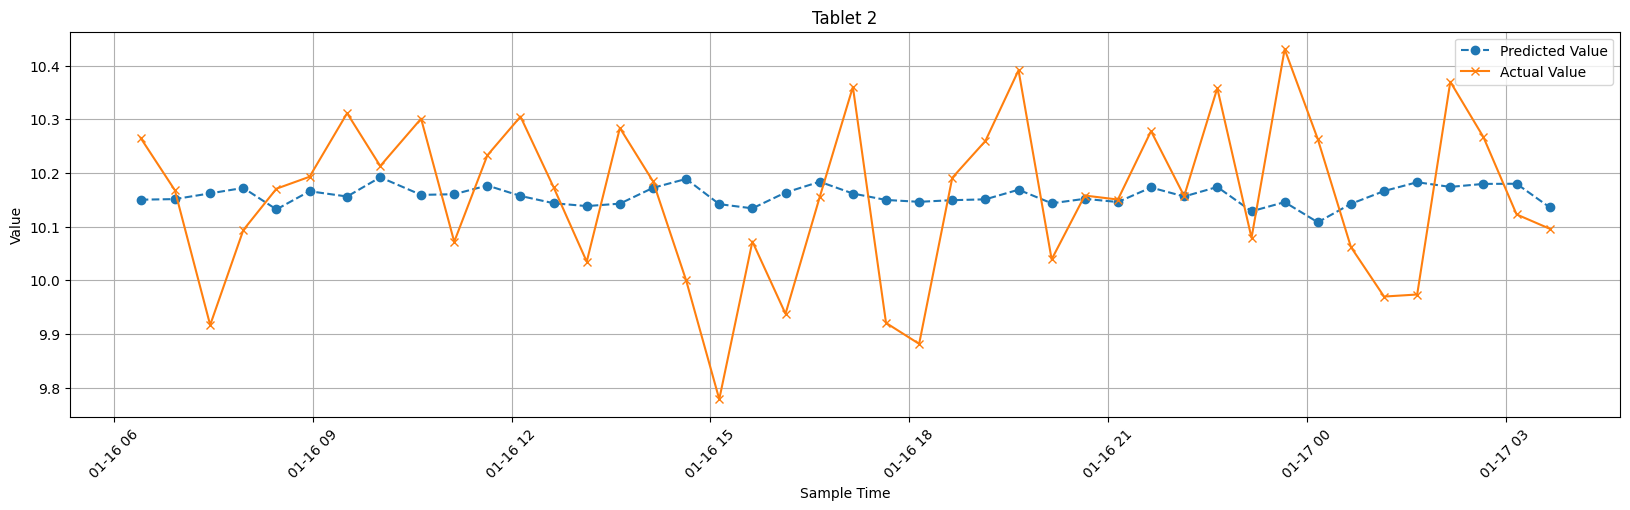

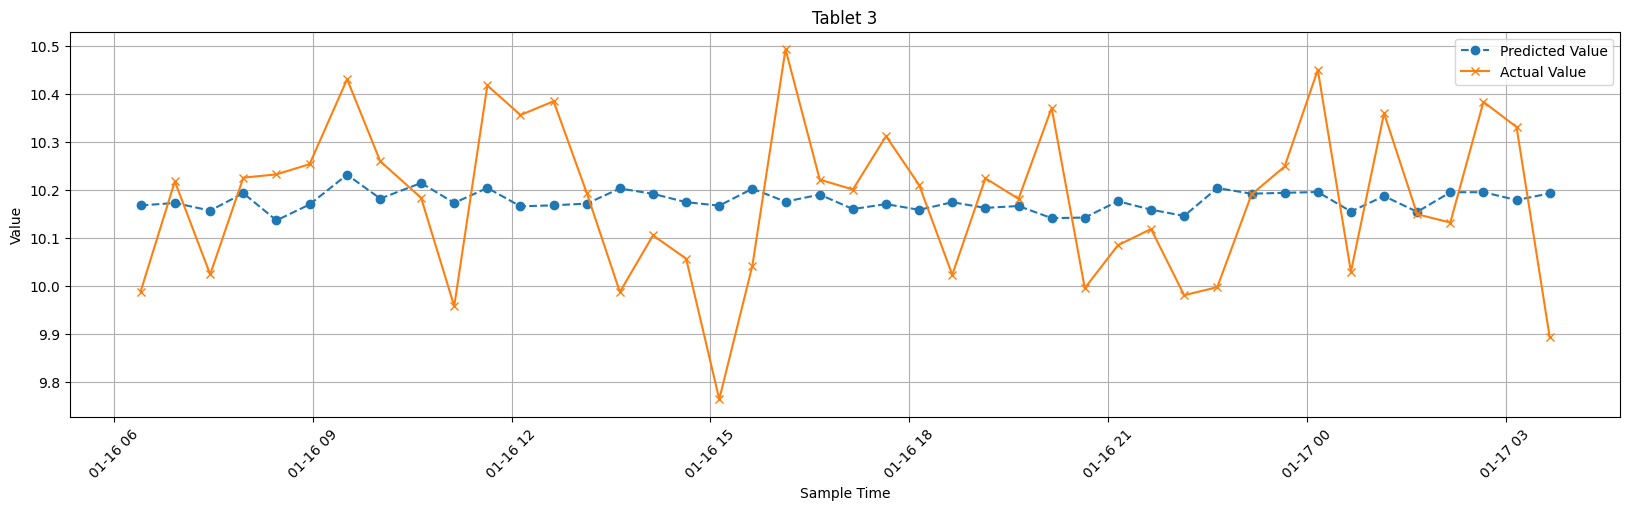

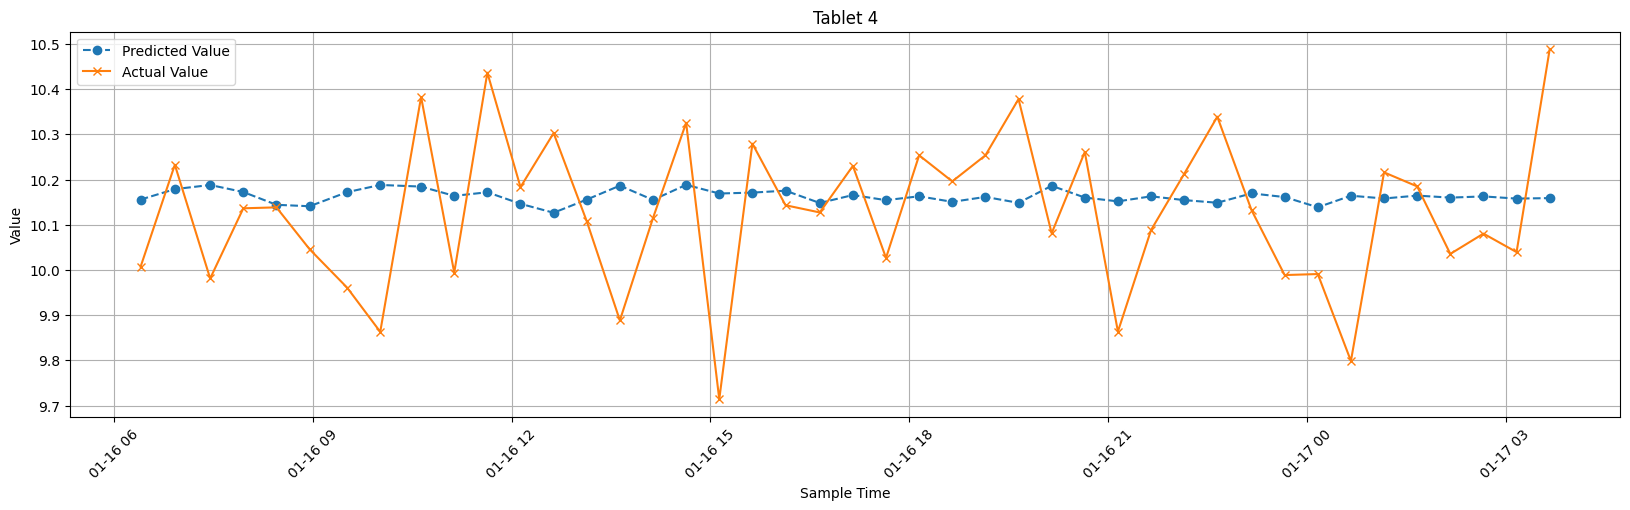

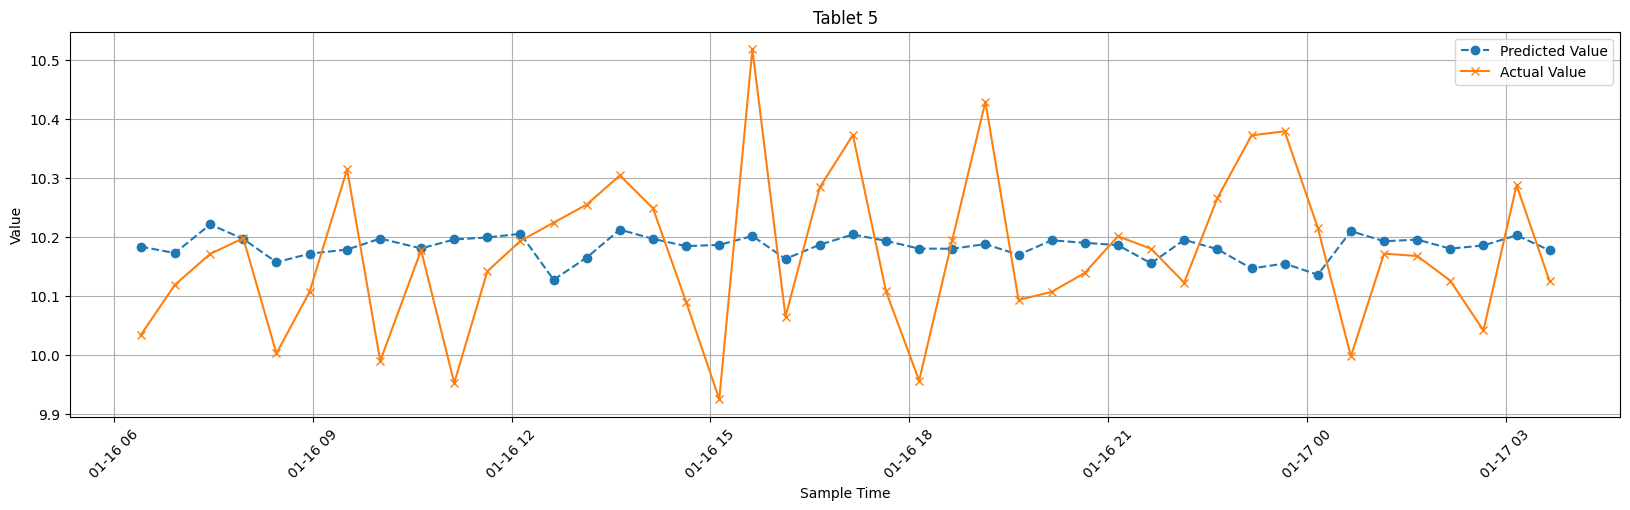

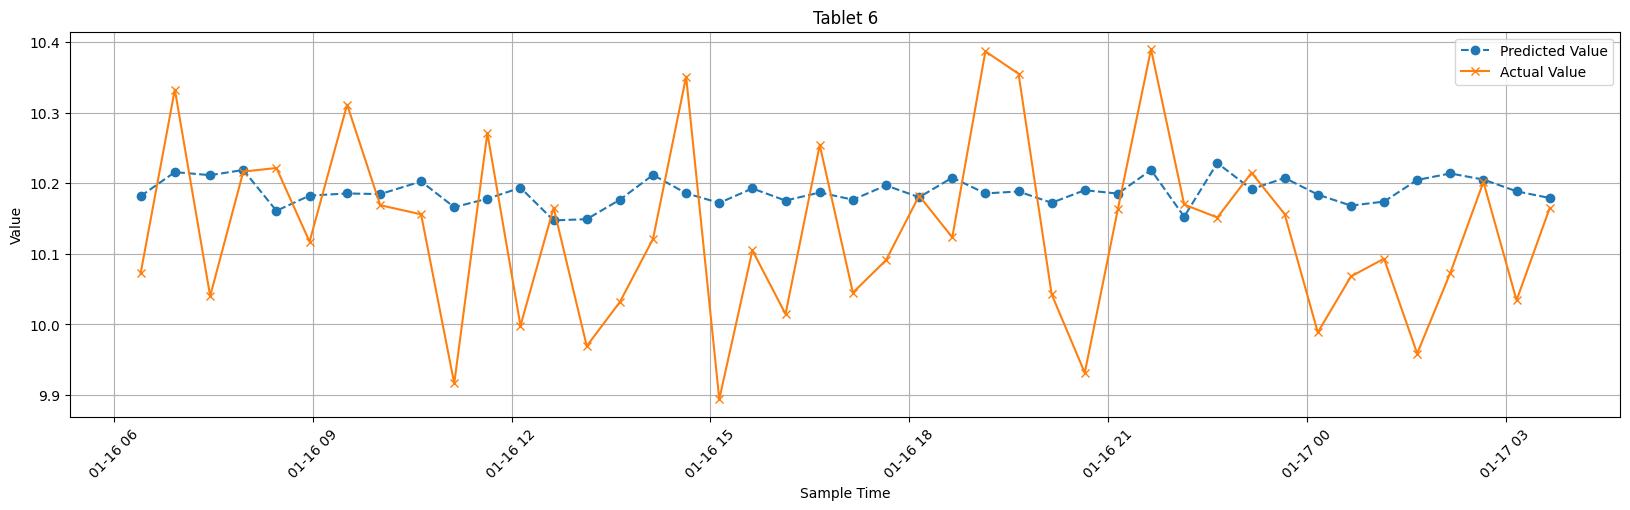

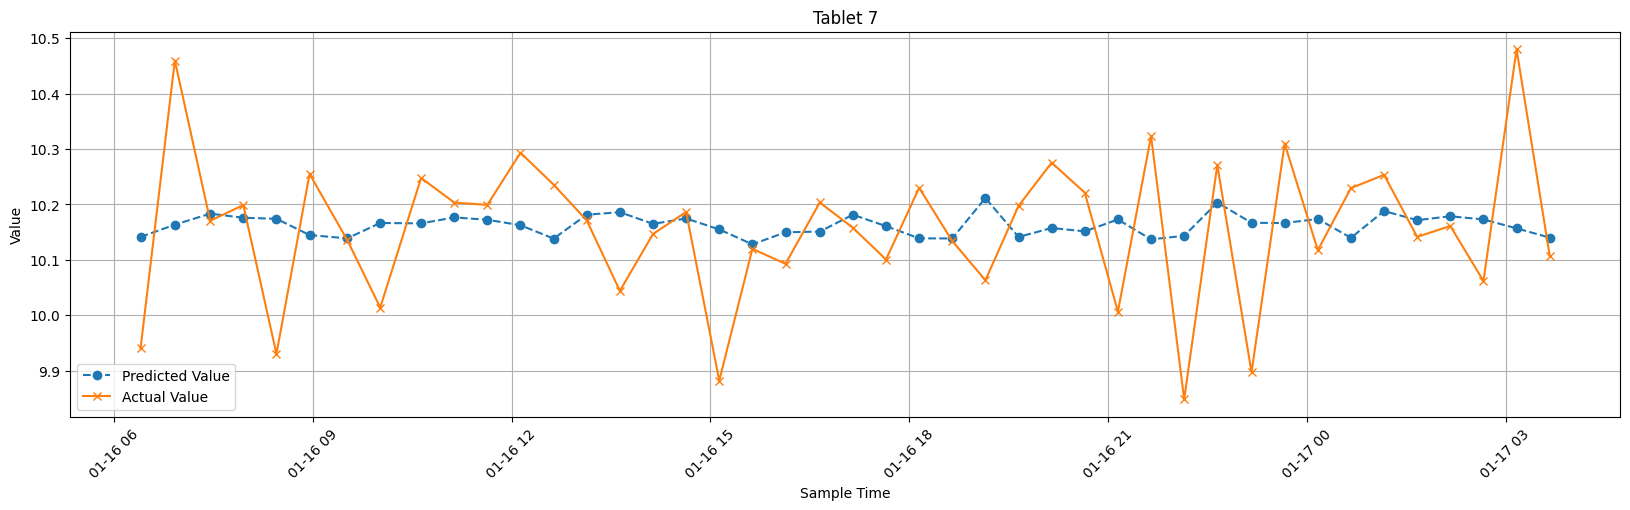

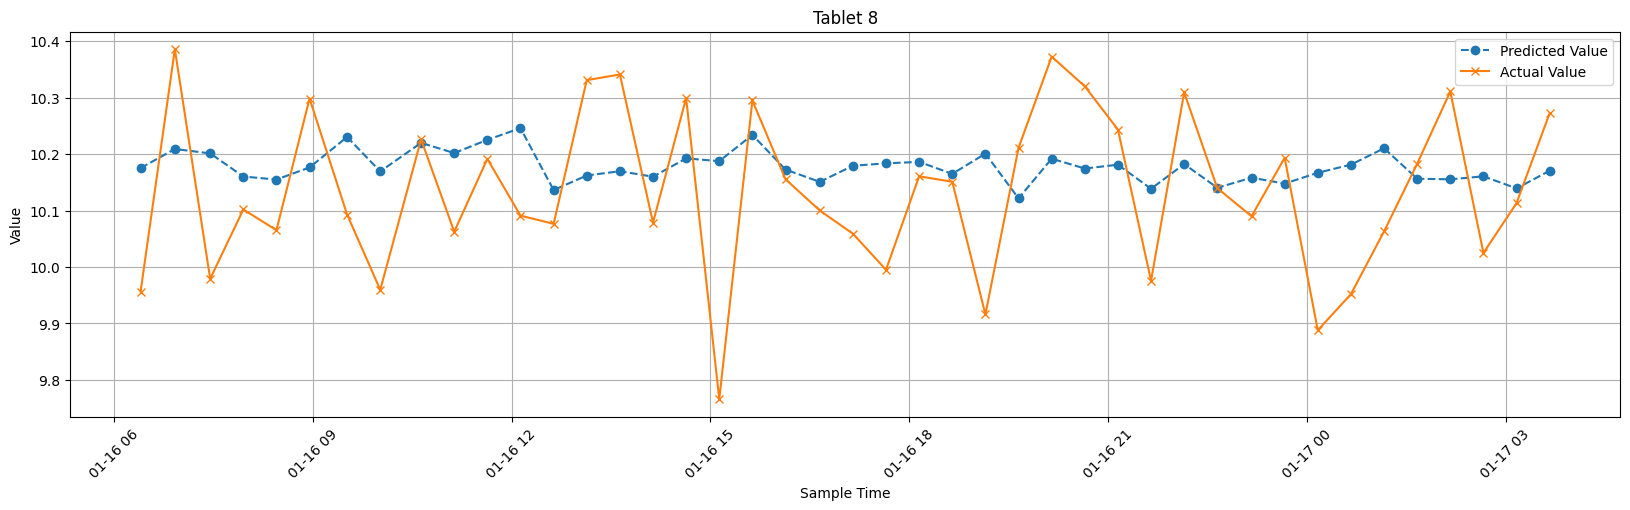

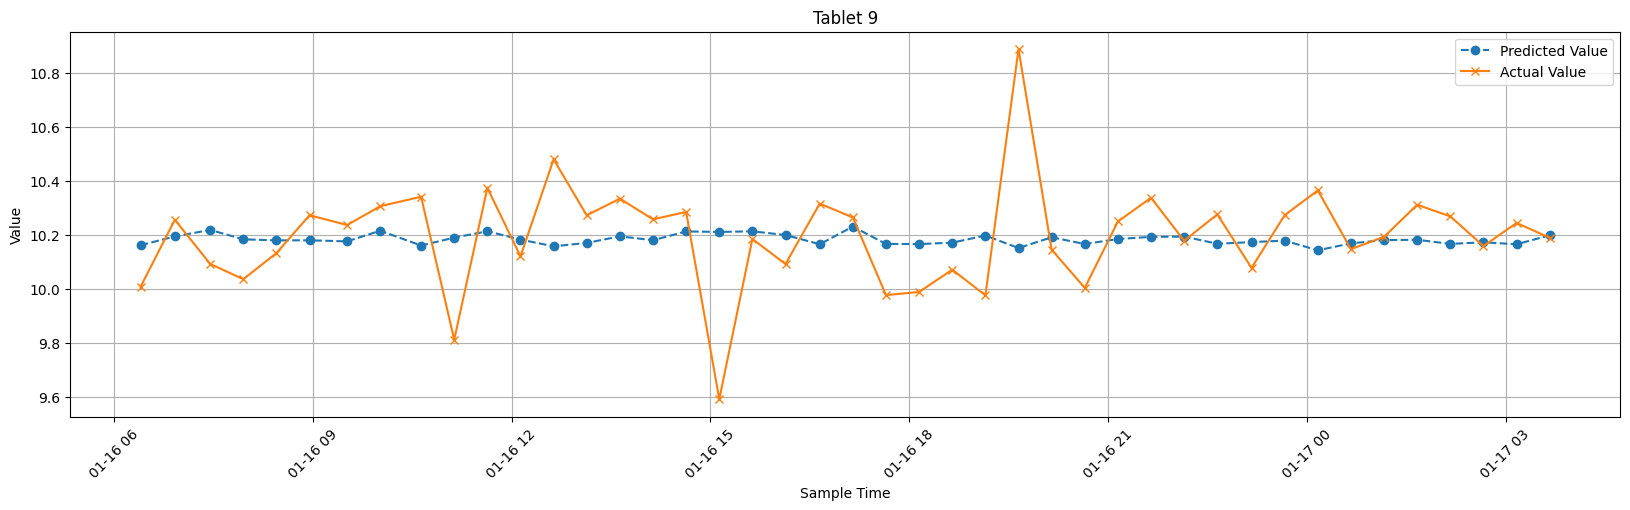

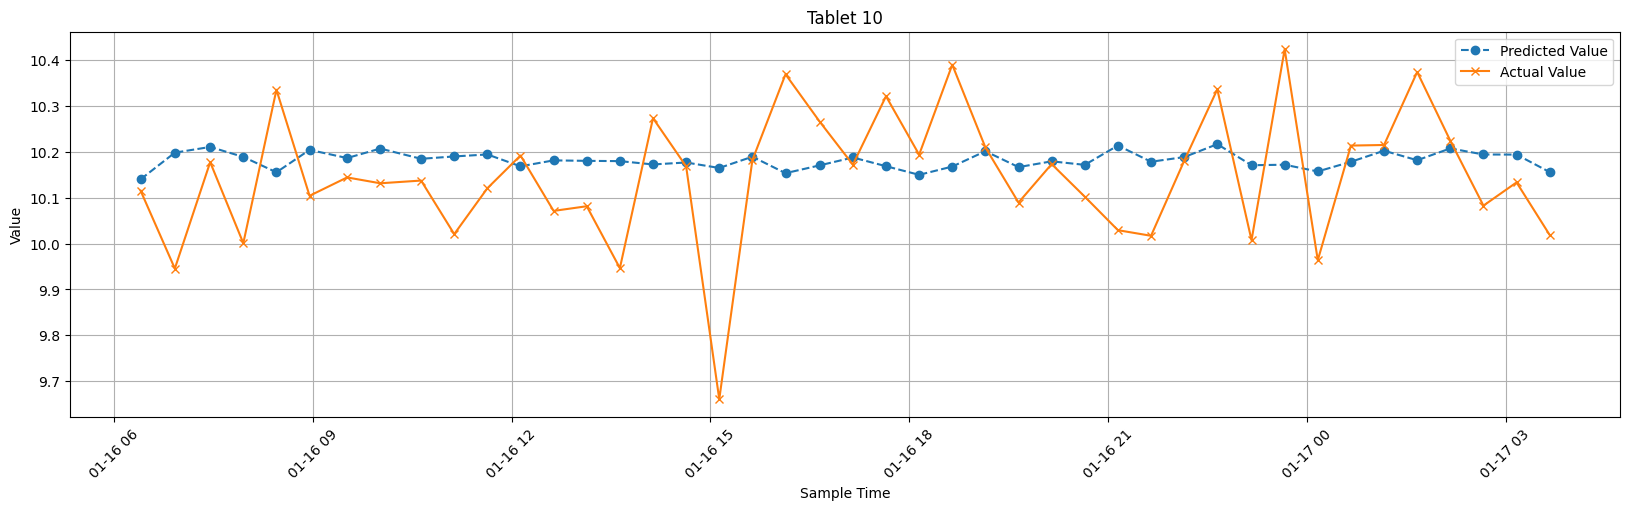

Model saved to ./model/API.pkl


In [91]:
model = TimeSeriesRandomForestRegressor(model_name=f"API", df=result['API'], target=targets, folds=5, n_estimators=100)
model.train()